

# Heart Disease Risk Prediction Using Tree-Based Machine Learning Models

## 1. Exploratory Data Analysis & Feature Engineering

### Project Overview

This project focuses on developing and evaluating tree-based machine learning models to predict whether a patient is at high risk of heart disease based on clinical and demographic characteristics.

The analysis uses the **UCI Heart Disease Dataset**, specifically the Cleveland dataset containing **303 patient records and 14 variables**, including clinical measurements, categorical risk factors, and a binary target indicating the presence or absence of heart disease.

The overall workflow will include:

* Exploratory Data Analysis (EDA)
* Feature Engineering
* Outlier Detection and Handling
* Baseline Model Development
* Stratified Cross-Validation
* Hyperparameter Tuning
* Model Comparison
* Feature Importance Analysis
* Model Behavior and Overfitting Analysis
* XGBoost Learning Curves
* Advanced Bonus Analysis

The primary objective is not only to achieve strong predictive performance, but also to understand **which clinical features contribute most to the predictions and how different tree-based models behave on this relatively small and imbalanced healthcare dataset**.

### Dataset

The dataset contains the following information:

* **303 patients**
* **13 predictive features**
* **1 binary target variable**
* No expected missing values in the original dataset
* Binary target representing the presence or absence of heart disease

The target variable is encoded as:

* `0` → No heart disease
* `1` → Heart disease

### Reproducibility

A fixed random seed will be used throughout the analysis wherever randomness is involved to ensure that the results are reproducible.

> **Important:** The test set will remain completely isolated from model training, hyperparameter tuning, and any data-driven preprocessing decisions to prevent data leakage.




In [1]:
# ============================================================
# 1. Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Visualization settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Loading

The dataset is loaded directly from a publicly available CSV representation of the UCI Heart Disease Cleveland dataset.

Using the direct CSV source allows the notebook to load the dataset reproducibly without requiring manual file uploads.

The dataset will first be inspected before performing any transformations or feature engineering. This initial inspection is important for verifying the dataset dimensions, column names, data types, and target representation.


In [2]:
# ============================================================
# 2. Load the Heart Disease Dataset
# ============================================================

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (303, 14)


## 3. Initial Dataset Inspection

Before conducting detailed exploratory analysis, we verify the structure of the loaded dataset.

The following checks will be performed:

1. Dataset dimensions
2. Column names
3. First observations
4. Data types
5. Basic descriptive statistics

These checks help confirm that the dataset matches the expected structure and that the variables are represented in an appropriate format for subsequent analysis.


In [3]:
# ============================================================
# 3. Initial Dataset Inspection
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst Five Rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes)

Dataset Shape:
(303, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First Five Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.300,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.500,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.400,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.800,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.600,2,0,2,1



Data Types:


,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


## 4. Descriptive Statistics

Descriptive statistics provide an initial understanding of the numerical variables in the dataset, including their central tendency, variability, and range.

This step can help identify unusual values, differences in feature scales, and potential variables that may require closer investigation during the EDA stage.


In [4]:
# ============================================================
# 4. Descriptive Statistics
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.000,54.366,9.082,29.000,47.500,55.000,61.000,77.000
sex,303.000,0.683,0.466,0.000,0.000,1.000,1.000,1.000
cp,303.000,0.967,1.032,0.000,0.000,1.000,2.000,3.000
trestbps,303.000,131.624,17.538,94.000,120.000,130.000,140.000,200.000
chol,303.000,246.264,51.831,126.000,211.000,240.000,274.500,564.000
fbs,303.000,0.149,0.356,0.000,0.000,0.000,0.000,1.000
restecg,303.000,0.528,0.526,0.000,0.000,1.000,1.000,2.000
thalach,303.000,149.647,22.905,71.000,133.500,153.000,166.000,202.000
exang,303.000,0.327,0.470,0.000,0.000,0.000,1.000,1.000
oldpeak,303.000,1.040,1.161,0.000,0.000,0.800,1.600,6.200


## 5. Data Quality Assessment

Before proceeding to visualization and statistical analysis, the dataset will be checked for potential data quality issues.

The following checks are performed:

* Missing values across all variables
* Duplicate observations
* Uniqueness of the target variable
* General consistency of the dataset structure

Although the original dataset is expected to contain no missing values, this assumption will be verified directly rather than taken for granted.

Checking duplicate records is also important because duplicated patient records could distort the observed class distribution and influence model evaluation.


In [5]:
# ============================================================
# 5. Data Quality Assessment
# ============================================================

# Missing values
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

print("Missing Values Summary:")
display(missing_summary)

# Duplicate records
duplicate_count = df.duplicated().sum()

print(f"\nNumber of duplicate rows: {duplicate_count}")

# Target values
print("\nUnique target values:")
print(sorted(df["target"].unique()))

Missing Values Summary:


,Missing Count,Missing Percentage
age,0,0.000
sex,0,0.000
cp,0,0.000
trestbps,0,0.000
chol,0,0.000
fbs,0,0.000
restecg,0,0.000
thalach,0,0.000
exang,0,0.000
oldpeak,0,0.000



Number of duplicate rows: 1

Unique target values:
[np.int64(0), np.int64(1)]


## 5.1 Duplicate Record Investigation

An exact duplicate record was identified during the data quality assessment. Before removing it, the duplicated observation is inspected to determine whether the duplication occurs across all available variables.

Because duplicate patient records can potentially bias descriptive statistics and model training, exact duplicate rows will be removed if confirmed. The removal will be documented explicitly to maintain transparency and reproducibility.

No observations will be removed based solely on being unusual or extreme at this stage. Outlier handling will be addressed separately using a statistically justified approach.


In [6]:
# ============================================================
# 5.1 Investigate Duplicate Records
# ============================================================

duplicate_rows = df[df.duplicated(keep=False)]

print(f"Number of duplicated rows: {len(duplicate_rows)}")
print("\nDuplicated observations:")
display(duplicate_rows)

Number of duplicated rows: 2

Duplicated observations:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.000,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.000,2,4,2,1


## 5.2 Duplicate Removal

The duplicate investigation confirmed the presence of one exact duplicated observation. Both rows have identical values across all 14 variables, including the target variable.

Keeping an exact duplicate would give the same observation additional influence during exploratory analysis and subsequent model training. Therefore, the duplicate record will be removed to ensure that each unique observation contributes only once to the analysis.

The original dataset is preserved in `df_raw` before cleaning so that the transformation from the raw dataset to the analysis dataset remains transparent and reproducible.


In [7]:
# ============================================================
# 5.2 Remove Exact Duplicate Records
# ============================================================

# Preserve the original raw dataset
df_raw = df.copy()

# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print(f"Original dataset shape: {df_raw.shape}")
print(f"Dataset shape after removing duplicates: {df.shape}")
print(f"Number of rows removed: {len(df_raw) - len(df)}")

Original dataset shape: (303, 14)
Dataset shape after removing duplicates: (302, 14)
Number of rows removed: 1


## 5.3 Post-Cleaning Validation

After removing the exact duplicate, the dataset is validated again to confirm that:

* No exact duplicate rows remain.
* No observations were unintentionally removed beyond the identified duplicate.
* The target variable still contains both classification classes.
* The dataset dimensions are consistent with the documented cleaning step.

This validation ensures that the cleaning operation did not introduce unintended changes to the dataset.


In [8]:
# ============================================================
# 5.3 Post-Cleaning Validation
# ============================================================

print("Remaining duplicate rows:", df.duplicated().sum())

print("\nFinal dataset shape after duplicate removal:")
print(df.shape)

print("\nTarget class distribution after duplicate removal:")
display(
    df["target"]
    .value_counts()
    .sort_index()
    .rename_axis("Target")
    .reset_index(name="Count")
)

Remaining duplicate rows: 0

Final dataset shape after duplicate removal:
(302, 14)

Target class distribution after duplicate removal:


,Target,Count
0,0,138
1,1,164


## 6. Target Class Distribution

The target variable represents whether heart disease is present:

* `0` — No heart disease
* `1` — Heart disease

After removing the exact duplicate, the dataset contains 302 unique observations. The target distribution is examined using both absolute counts and relative percentages to assess the degree of class imbalance.

Understanding the target distribution is important because class imbalance can affect the interpretation of classification metrics. In particular, healthcare applications should not rely on accuracy alone, as correctly identifying patients who have the disease is clinically important.

The class distribution will therefore be considered when evaluating model performance using precision, recall, F1-score, and ROC-AUC in addition to accuracy.


In [9]:
# ============================================================
# 6. Target Class Distribution
# ============================================================

target_counts = df["target"].value_counts().sort_index()
target_percentages = (
    df["target"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_distribution = pd.DataFrame({
    "Target": target_counts.index,
    "Class": ["No Disease", "Disease"],
    "Count": target_counts.values,
    "Percentage": target_percentages.values
})

display(target_distribution)

# Majority and minority classes
majority_count = target_counts.max()
minority_count = target_counts.min()

imbalance_ratio = majority_count / minority_count

print(f"Majority class count: {majority_count}")
print(f"Minority class count: {minority_count}")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}:1")

,Target,Class,Count,Percentage
0,0,No Disease,138,45.695
1,1,Disease,164,54.305


Majority class count: 164
Minority class count: 138
Imbalance ratio (majority/minority): 1.19:1


## 6.1 Target Distribution Visualization

The target distribution is visualized using a count plot to make the relative representation of the two classes immediately apparent.

The exact counts and percentages are displayed directly on the plot to improve readability and make the class distribution easier to interpret.

Given the relatively small difference between the two classes, the dataset is expected to exhibit **mild rather than severe class imbalance**. This distinction is important because the modeling strategy should account for the imbalance without unnecessarily assuming that the dataset is highly skewed.


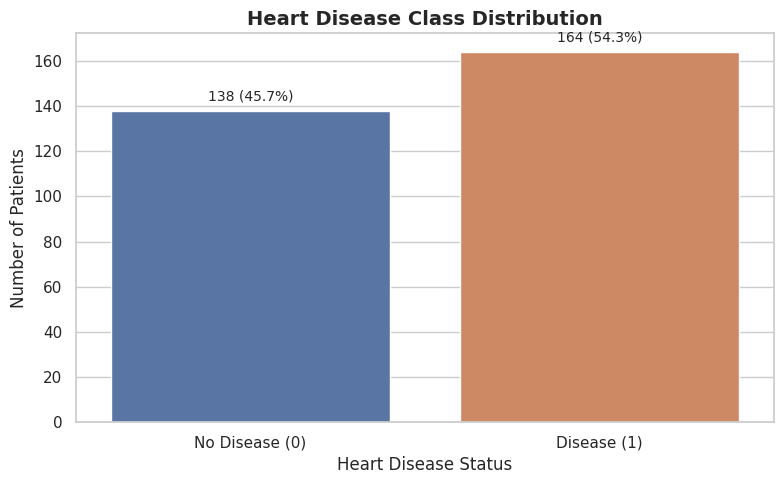

In [10]:
# ============================================================
# 6.1 Visualize Target Distribution
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="target",
    hue="target",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

plt.title(
    "Heart Disease Class Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Disease (0)", "Disease (1)"]
)

# Add count and percentage labels
for i, container in enumerate(ax.containers):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            percentage = target_percentages.iloc[i]
            ax.annotate(
                f"{int(height)} ({percentage:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10
            )

plt.tight_layout()
plt.show()

### Observation

The target variable shows a relatively balanced distribution between the two classes. Among the 302 unique observations, **164 patients (54.3%)** are classified as having heart disease, while **138 patients (45.7%)** are classified as having no heart disease. This corresponds to an approximate majority-to-minority ratio of **1.19:1**, indicating only mild class imbalance.

Therefore, the dataset does not exhibit severe class imbalance. However, because this is a healthcare classification problem, model evaluation should still consider recall, precision, F1-score, and ROC-AUC rather than relying on accuracy alone. This becomes particularly important when evaluating the cost-sensitive learning approach in the bonus analysis, where reducing false negatives will be given additional consideration.


## 7. Univariate Analysis

Univariate analysis is used to examine the distribution and variability of individual features before investigating relationships between variables.

For this dataset, the variables are divided into two broad groups:

* **Continuous numerical features:** `age`, `trestbps`, `chol`, `thalach`, and `oldpeak`
* **Categorical or ordinal features:** `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, and `thal`

The continuous variables will first be visualized using histograms. To make the analysis more informative for the classification task, the distributions will be separated by the target class.

This allows us to assess not only the overall distribution of each feature, but also whether the feature appears to provide visual separation between patients with and without heart disease.


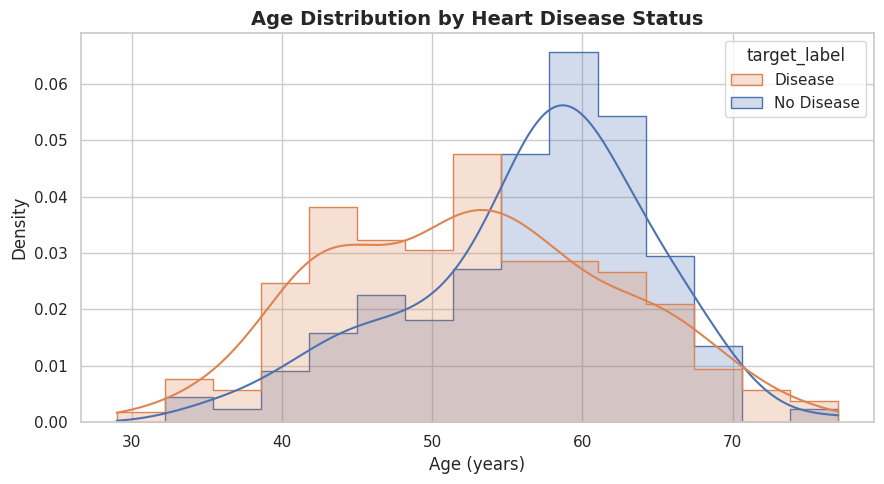

In [11]:
# ============================================================
# 7.1 Age Distribution by Target Class
# ============================================================

target_labels = {
    0: "No Disease",
    1: "Disease"
}

plot_df = df.copy()
plot_df["target_label"] = plot_df["target"].map(target_labels)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=plot_df,
    x="age",
    hue="target_label",
    bins=15,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "No Disease": "#4C72B0",
        "Disease": "#DD8452"
    }
)

plt.title(
    "Age Distribution by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age (years)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

### Observation

The age distributions differ between the two target classes. Patients without heart disease have a higher mean age (56.6 years) and median age (58 years), compared with a mean age of 52.6 years and median age of 52 years among patients with heart disease.

Although the two distributions overlap substantially, the difference in their central tendency suggests that age contains useful information for distinguishing the two classes. However, the overlap indicates that age alone is unlikely to provide sufficient separation, and its predictive value should be considered together with other clinical features.

In [12]:
# ============================================================
# Supporting Statistics for Age Distribution
# ============================================================

age_summary = (
    df.groupby("target")["age"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .rename(index={0: "No Disease", 1: "Disease"})
)

display(age_summary)

,count,mean,median,std,min,max
target,,,,,,
No Disease,138,56.601,58.000,7.962,35,77
Disease,164,52.585,52.000,9.512,29,76


## 7.2 Resting Blood Pressure Distribution

Resting blood pressure (`trestbps`) represents the patient's resting systolic blood pressure and is an important clinical measurement that may provide information about cardiovascular risk.

Its distribution will be examined across the two target classes to determine whether patients with and without heart disease show noticeably different blood pressure patterns and whether extreme observations are present.


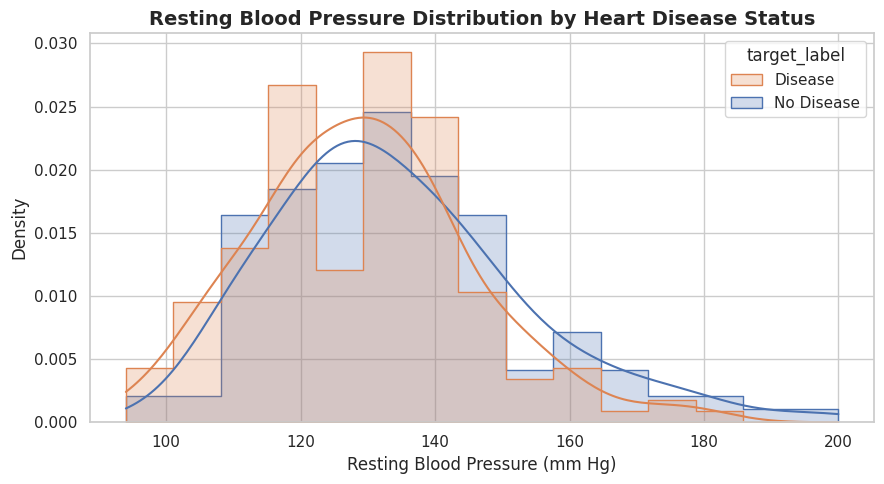

In [13]:
# ============================================================
# 7.2 Resting Blood Pressure Distribution by Target Class
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=plot_df,
    x="trestbps",
    hue="target_label",
    bins=15,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "No Disease": "#4C72B0",
        "Disease": "#DD8452"
    }
)

plt.title(
    "Resting Blood Pressure Distribution by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Resting Blood Pressure (mm Hg)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

### Observation

Resting blood pressure shows substantial overlap between the two target classes. The mean resting blood pressure is 134.4 mm Hg for patients without heart disease and 129.3 mm Hg for patients with heart disease, while the median is 130 mm Hg for both groups.

The identical median values and considerable overlap indicate that resting blood pressure provides relatively limited standalone separation between the two classes in this dataset. Nevertheless, the feature may still contribute useful information when combined with other clinical variables.

In [14]:
# Supporting statistics for resting blood pressure

trestbps_summary = (
    df.groupby("target")["trestbps"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .rename(index={0: "No Disease", 1: "Disease"})
)

display(trestbps_summary)

,count,mean,median,std,min,max
target,,,,,,
No Disease,138,134.399,130.000,18.730,100,200
Disease,164,129.250,130.000,16.205,94,180


## 7.3 Cholesterol Distribution

Serum cholesterol (`chol`) is an important cardiovascular risk-related measurement. Its distribution is examined across the two target classes to identify differences in central tendency, spread, and potential extreme observations.

A histogram with kernel density estimates is used to visualize the shape of the distributions while maintaining a direct comparison between patients with and without heart disease.

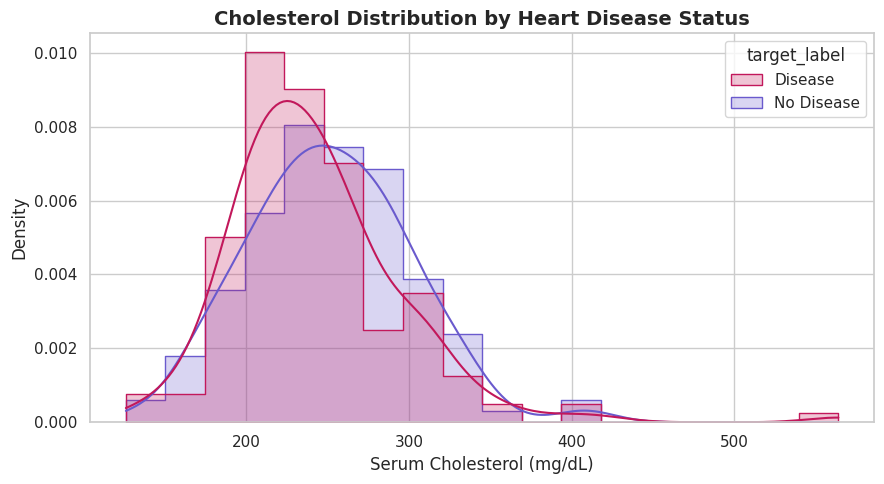

In [15]:
# ============================================================
# 7.3 Cholesterol Distribution by Target Class
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=plot_df,
    x="chol",
    hue="target_label",
    bins=18,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette={
        "No Disease": "#6A5ACD",   # Purple
        "Disease": "#C2185B"       # Pink/Burgundy
    }
)

plt.title(
    "Cholesterol Distribution by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Serum Cholesterol (mg/dL)")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

### Observation

Cholesterol levels show substantial overlap between patients with and without heart disease. The mean cholesterol level is 251.1 mg/dL for the no-disease group and 242.6 mg/dL for the disease group. The corresponding medians are 249.0 mg/dL and 234.5 mg/dL, respectively.

The disease group also shows slightly greater variability, with a standard deviation of approximately 53.5 mg/dL compared with 49.5 mg/dL in the no-disease group. Overall, cholesterol does not provide strong visual separation between the two classes on its own, although it may still contribute predictive information through interactions with other clinical features.

In [16]:
# Supporting statistics for cholesterol

chol_summary = (
    df.groupby("target")["chol"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .rename(index={0: "No Disease", 1: "Disease"})
)

display(chol_summary)

,count,mean,median,std,min,max
target,,,,,,
No Disease,138,251.087,249.000,49.455,131,409
Disease,164,242.640,234.500,53.457,126,564


## 7.4 Maximum Heart Rate Distribution

Maximum heart rate achieved during exercise (`thalach`) is examined as a potential discriminator between the two target classes.

A violin plot is used to visualize the distribution, density, median, and overall spread of maximum heart rate for each class. This representation provides a complementary perspective to the histogram-based analysis used for the continuous variables above.

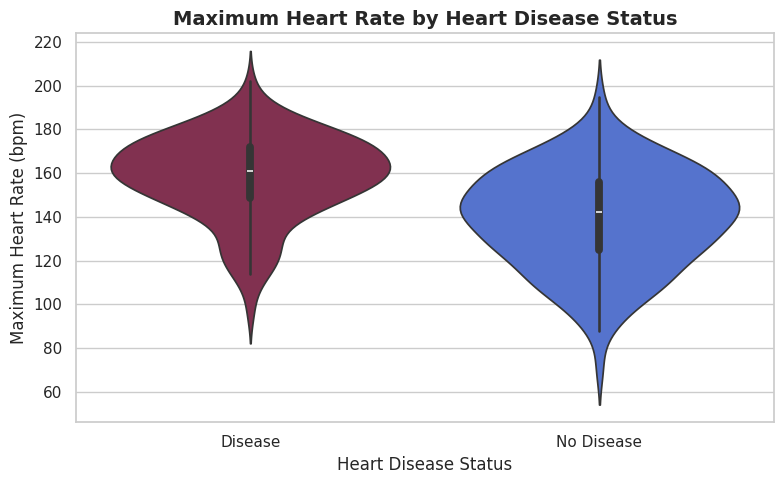

In [17]:
# ============================================================
# 7.4 Maximum Heart Rate — Violin Plot
# ============================================================

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=plot_df,
    x="target_label",
    y="thalach",
    hue="target_label",
    palette={
        "No Disease": "#4169E1",   # Blue
        "Disease": "#8E244D"       # Burgundy
    },
    inner="box",
    legend=False
)

plt.title(
    "Maximum Heart Rate by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Heart Disease Status")
plt.ylabel("Maximum Heart Rate (bpm)")

plt.tight_layout()
plt.show()

### Observation

Maximum heart rate shows a clearer difference between the two target classes than several of the previously examined continuous features. Patients with heart disease have a higher mean maximum heart rate of approximately 158.4 bpm and a median of 161 bpm, compared with 139.1 bpm and 142 bpm, respectively, for patients without heart disease.

Although some overlap remains between the distributions, the difference in central tendency suggests that maximum heart rate may provide meaningful discriminatory information. This feature should therefore be examined further in the bivariate and multivariate analyses.

In [18]:
# Supporting statistics for maximum heart rate

thalach_summary = (
    df.groupby("target")["thalach"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .rename(index={0: "No Disease", 1: "Disease"})
)

display(thalach_summary)

,count,mean,median,std,min,max
target,,,,,,
No Disease,138,139.101,142.000,22.599,71,195
Disease,164,158.378,161.000,19.199,96,202


## 7.5 ST Depression Distribution

ST depression induced by exercise relative to rest (`oldpeak`) is examined across the two target classes.

A box plot is used to compare the median, interquartile range, overall spread, and potential extreme observations. This visualization is particularly useful because `oldpeak` may contain clinically relevant high values that should be investigated further during the dedicated outlier analysis.

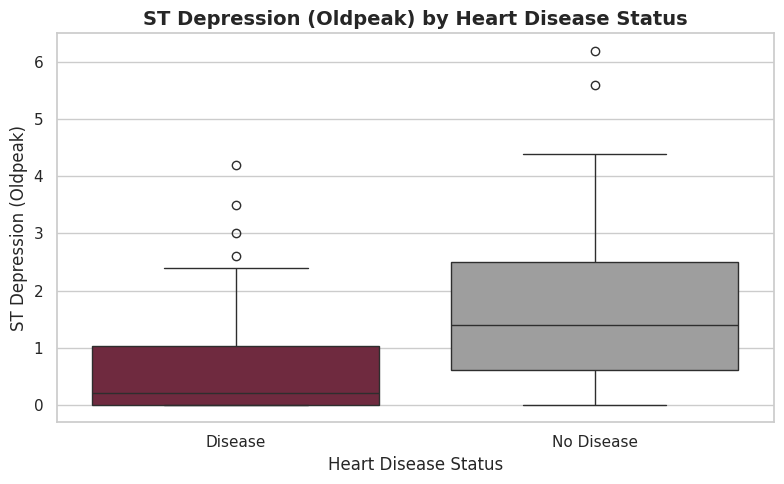

In [19]:
# ============================================================
# 7.5 ST Depression — Box Plot
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x="target_label",
    y="oldpeak",
    hue="target_label",
    palette={
        "No Disease": "#9E9E9E",   # Grey
        "Disease": "#7B1E3A"       # Burgundy
    },
    legend=False
)

plt.title(
    "ST Depression (Oldpeak) by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Heart Disease Status")
plt.ylabel("ST Depression (Oldpeak)")

plt.tight_layout()
plt.show()

### Observation

ST depression induced by exercise (`oldpeak`) shows a noticeable difference between the two target classes. The no-disease group has a mean oldpeak of approximately 1.59 and a median of 1.40, whereas the disease group has a substantially lower mean of approximately 0.59 and a median of 0.20.

The distributions also show different concentrations across the range of values. This suggests that oldpeak may provide useful information for distinguishing the two classes and warrants further investigation during the bivariate analysis and subsequent model development.

In [20]:
# Supporting statistics for oldpeak

oldpeak_summary = (
    df.groupby("target")["oldpeak"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .rename(index={0: "No Disease", 1: "Disease"})
)

display(oldpeak_summary)

,count,mean,median,std,min,max
target,,,,,,
No Disease,138,1.586,1.400,1.300,0.000,6.200
Disease,164,0.587,0.200,0.782,0.000,4.200


## 7.6 Sex Distribution by Heart Disease Status

Sex is a binary categorical feature encoded as:

- `0` → Female
- `1` → Male

The distribution is visualized by target class to examine whether the proportion of heart disease cases differs between males and females.

Rather than examining the overall frequency of each sex, the target-aware visualization allows us to assess whether sex provides evidence of class separation within the dataset.

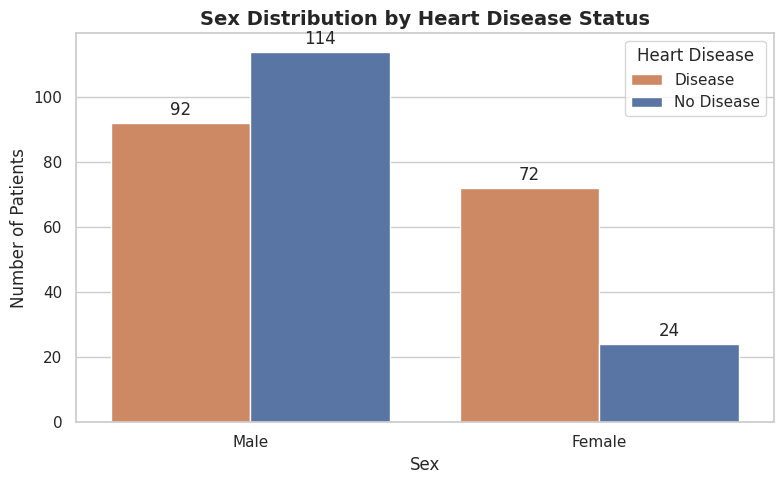

In [21]:
# ============================================================
# 7.6 Sex Distribution by Heart Disease Status
# ============================================================

sex_plot = df.copy()

sex_plot["Sex"] = sex_plot["sex"].map({
    0: "Female",
    1: "Male"
})

sex_plot["Heart Disease"] = sex_plot["target"].map({
    0: "No Disease",
    1: "Disease"
})

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=sex_plot,
    x="Sex",
    hue="Heart Disease",
    palette={
        "No Disease": "#4C72B0",
        "Disease": "#DD8452"
    }
)

plt.title(
    "Sex Distribution by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sex")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Observation:**

The sex distribution grouped by heart disease status reveals distinct patterns in disease prevalence between males and females in the dataset. Among male patients, the distribution is relatively balanced, with 114 individuals classified as having no disease compared to 92 individuals presenting with heart disease. In contrast, the female cohort shows a highly skewed distribution towards positive cases; a significant majority of female patients (72 individuals) are diagnosed with heart disease, while only a small minority (24 individuals) fall into the no-disease category. This substantial difference in the relative proportions indicates that sex is a differentiating feature that will likely contribute highly valuable predictive information to the model.

## 7.7 Chest Pain Type Distribution by Heart Disease Status

Chest pain type (`cp`) is a categorical clinical feature with four encoded categories:

- `0` → Typical angina
- `1` → Atypical angina
- `2` → Non-anginal pain
- `3` → Asymptomatic

Because chest pain type is clinically related to cardiovascular presentation, its distribution is examined separately for patients with and without heart disease.

A target-aware count plot is used to determine whether specific chest pain categories are associated with a higher concentration of heart disease cases.

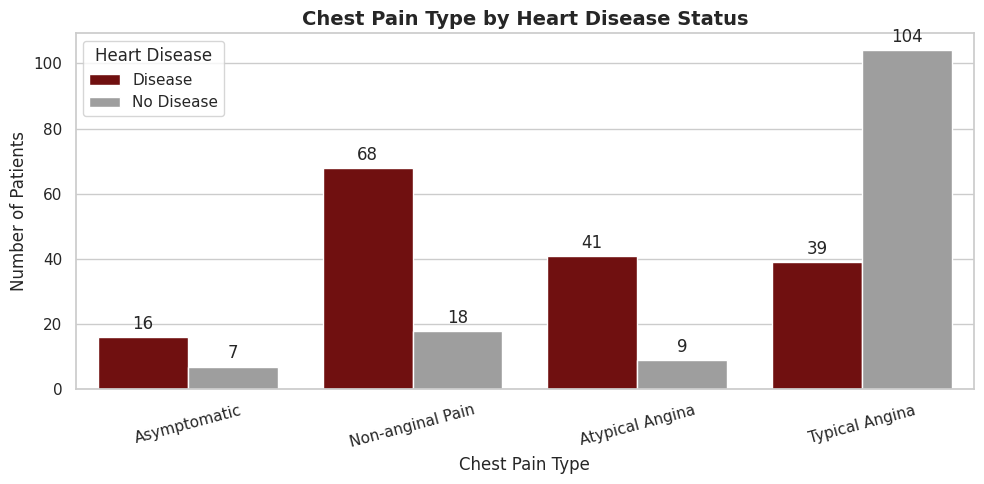

In [22]:
# ============================================================
# 7.7 Chest Pain Type by Heart Disease Status
# ============================================================

cp_plot = df.copy()

cp_plot["Chest Pain Type"] = cp_plot["cp"].map({
    0: "Typical Angina",
    1: "Atypical Angina",
    2: "Non-anginal Pain",
    3: "Asymptomatic"
})

cp_plot["Heart Disease"] = cp_plot["target"].map({
    0: "No Disease",
    1: "Disease"
})

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=cp_plot,
    x="Chest Pain Type",
    hue="Heart Disease",
    palette={
        "No Disease": "#9E9E9E",
        "Disease": "#800000"
    }
)

plt.title(
    "Chest Pain Type by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Observation:**

The distribution of chest pain types categorized by heart disease status reveals highly contrasting patterns between the different symptom groups. Patients presenting with "Typical Angina" overwhelmingly fall into the no-disease category, with 104 individuals compared to only 39 diagnosed with heart disease. Conversely, the other three chest pain categories show a strong skew towards positive heart disease diagnoses. Specifically, among patients with "Non-anginal Pain," a significant majority (68 individuals) have heart disease compared to just 18 without. Similarly, "Atypical Angina" shows a heavy concentration of disease cases (41 versus 9), as does the "Asymptomatic" category (16 versus 7). This stark reversal in class prevalence across the different pain types indicates that the chest pain classification is a highly discriminative feature that will likely contribute strong predictive power to the model.

In [23]:
cp_labels = {
    0: "Typical Angina",
    1: "Atypical Angina",
    2: "Non-anginal Pain",
    3: "Asymptomatic"
}

cp_summary = pd.DataFrame({
    "Count": df["cp"].value_counts().sort_index(),
    "Percentage": df["cp"].value_counts(normalize=True).sort_index() * 100
})

cp_summary.index = cp_summary.index.map(cp_labels)

display(cp_summary)

,Count,Percentage
cp,,
Typical Angina,143,47.351
Atypical Angina,50,16.556
Non-anginal Pain,86,28.477
Asymptomatic,23,7.616


## 7.8 Fasting Blood Sugar Distribution by Heart Disease Status

Fasting blood sugar (`fbs`) is a binary categorical feature:

- `0` → Fasting blood sugar ≤ 120 mg/dL
- `1` → Fasting blood sugar > 120 mg/dL

The feature is visualized by target class to determine whether elevated fasting blood sugar shows a noticeable association with heart disease in this dataset.

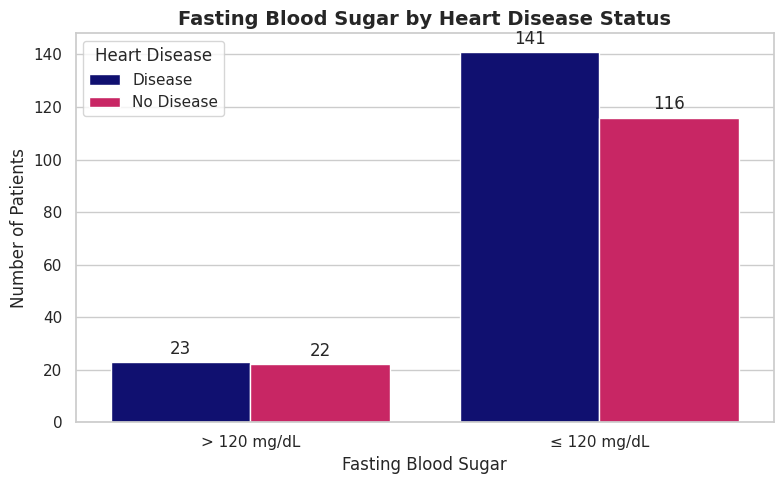

In [24]:
# ============================================================
# 7.8 Fasting Blood Sugar by Heart Disease Status
# ============================================================

fbs_plot = df.copy()

fbs_plot["Fasting Blood Sugar"] = fbs_plot["fbs"].map({
    0: "≤ 120 mg/dL",
    1: "> 120 mg/dL"
})

fbs_plot["Heart Disease"] = fbs_plot["target"].map({
    0: "No Disease",
    1: "Disease"
})

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=fbs_plot,
    x="Fasting Blood Sugar",
    hue="Heart Disease",
    palette={
        "No Disease": "#E30B5D",
        "Disease": "#000080"
    }
)

plt.title(
    "Fasting Blood Sugar by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Observation:**

The distribution of fasting blood sugar categorized by heart disease status reveals that this feature may have limited independent discriminative power. Within the vast majority of the population whose fasting blood sugar is at or below 120 mg/dL, there is a higher prevalence of heart disease, with 141 diagnosed individuals compared to 116 without the disease. Interestingly, within the much smaller cohort of patients with elevated fasting blood sugar (> 120 mg/dL), the distribution is almost perfectly balanced, with 23 patients presenting with heart disease and 22 without. This relatively even split across the elevated blood sugar category suggests that a fasting blood sugar level greater than 120 mg/dL alone does not strongly differentiate between the presence or absence of heart disease in this specific dataset.

## 7.9 Resting Electrocardiographic Results by Heart Disease Status

Resting ECG results (`restecg`) are represented using three categories:

- `0` → Normal
- `1` → ST-T wave abnormality
- `2` → Left ventricular hypertrophy

The distribution is examined by target class to determine whether specific resting ECG categories are more frequently associated with heart disease.

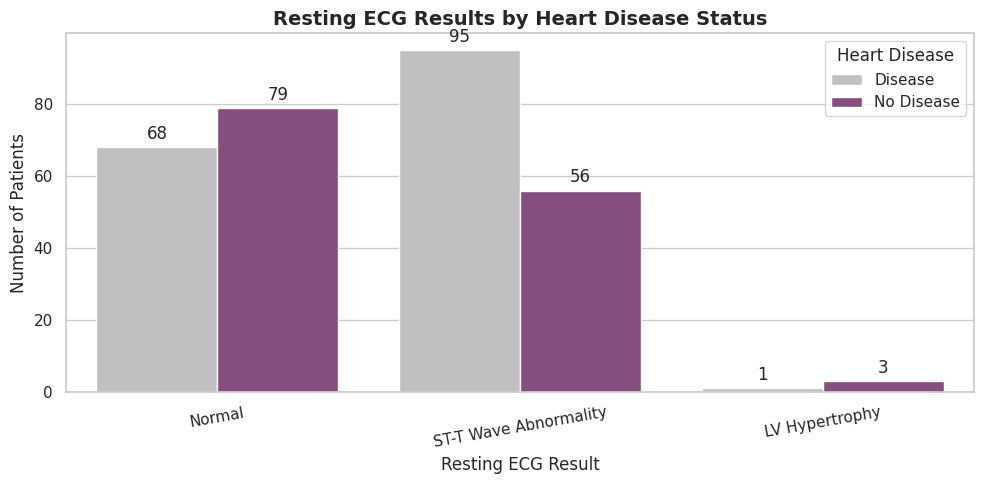

In [25]:
# ============================================================
# 7.9 Resting ECG Results by Heart Disease Status
# ============================================================

ecg_plot = df.copy()

ecg_plot["Resting ECG"] = ecg_plot["restecg"].map({
    0: "Normal",
    1: "ST-T Wave Abnormality",
    2: "LV Hypertrophy"
})

ecg_plot["Heart Disease"] = ecg_plot["target"].map({
    0: "No Disease",
    1: "Disease"
})

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=ecg_plot,
    x="Resting ECG",
    hue="Heart Disease",
    palette={
        "No Disease": "#8E4585",
        "Disease": "#C0C0C0"
    }
)

plt.title(
    "Resting ECG Results by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Resting ECG Result")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Observation:**

The distribution of resting electrocardiogram (ECG) results categorized by heart disease status reveals a notable shift in disease prevalence between the two primary categories. Among patients with a "Normal" resting ECG, the distribution leans slightly toward the absence of heart disease, with 79 individuals categorized as having no disease compared to 68 diagnosed with the condition. Conversely, patients presenting with an "ST-T Wave Abnormality" exhibit a strong skew toward positive heart disease diagnoses; within this group, a significant majority of 95 individuals have heart disease, compared to only 56 without. The third category, "LV Hypertrophy," contains a very small sample size—just 1 patient with disease and 3 without—limiting the ability to draw strong conclusions for this specific subset. The contrasting patterns between the normal and ST-T wave abnormality groups indicate that the resting ECG result is a discriminative clinical feature that will likely provide valuable predictive information to the model.

## 7.10 ST Segment Slope Distribution by Heart Disease Status

The slope of the peak exercise ST segment (`slope`) is an ordinal categorical feature with three categories:

- `0` → Upsloping
- `1` → Flat
- `2` → Downsloping

The feature is visualized by heart disease status to investigate whether different ST-segment slope patterns are associated with different target distributions.

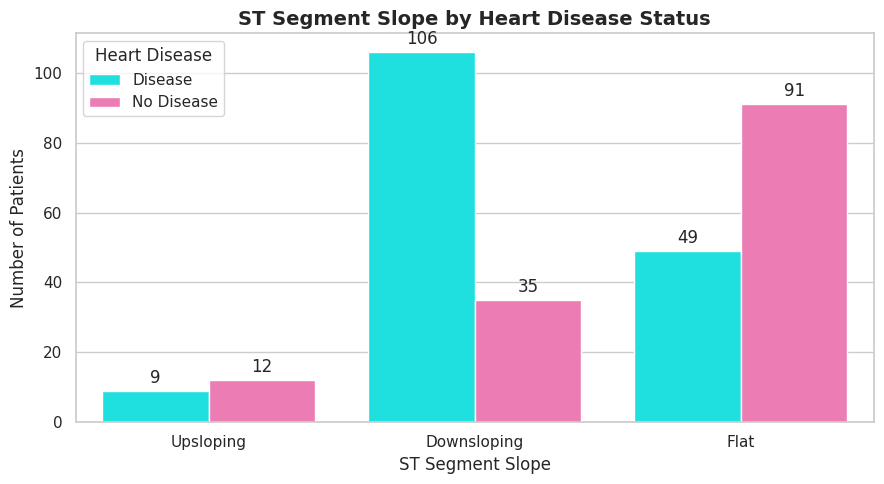

In [26]:
# ============================================================
# 7.10 ST Segment Slope by Heart Disease Status
# ============================================================

slope_plot = df.copy()

slope_plot["ST Slope"] = slope_plot["slope"].map({
    0: "Upsloping",
    1: "Flat",
    2: "Downsloping"
})

slope_plot["Heart Disease"] = slope_plot["target"].map({
    0: "No Disease",
    1: "Disease"
})

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=slope_plot,
    x="ST Slope",
    hue="Heart Disease",
    palette={
        "No Disease": "#FF69B4",
        "Disease": "#00FFFF"
    }
)

plt.title(
    "ST Segment Slope by Heart Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("ST Segment Slope")
plt.ylabel("Number of Patients")
plt.legend(title="Heart Disease")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

**Observation:**

The distribution of ST segment slope categories by heart disease status reveals a stark contrasting pattern between the two majority groups. Patients exhibiting a "Downsloping" ST segment are predominantly diagnosed with heart disease, with a significant majority of 106 individuals falling into the disease category compared to only 35 without. Conversely, the "Flat" ST segment category shows an inverse relationship, skewing heavily toward the absence of heart disease, with 91 individuals in the no-disease group compared to 49 with the disease. The third category, "Upsloping," represents a much smaller portion of the dataset and shows a relatively balanced distribution, with 9 patients presenting with heart disease and 12 without. This dramatic reversal in class prevalence between the "Downsloping" and "Flat" categories indicates that the ST segment slope is a highly discriminative clinical feature that will likely contribute strong predictive power to the model.

# 8. Bivariate & Multivariate Analysis

Following the univariate analysis, this section investigates relationships between individual clinical features and the heart disease target, as well as interactions among multiple predictors.

The analysis is designed to answer three main questions:

1. Which features are most strongly associated with the target?
2. Do combinations of the strongest features provide visible separation between patients with and without heart disease?
3. Which categorical clinical features show the clearest differences in target distribution across their categories?

To address these questions, the section includes an annotated correlation heatmap, a pairplot of the four features with the strongest absolute target correlations, and target-based cross-tabulations for the major categorical variables.

The categorical analysis uses row-wise percentages rather than raw frequencies. This is important because the categories do not contain equal numbers of observations. The percentage-based comparison therefore provides a more meaningful assessment of class separation.

All conclusions in this section are exploratory. Association does not imply causation, and the final predictive importance of the variables will be assessed later using cross-validated tree-based models.

In [27]:
# ============================================================
# SECTION 8 — BIVARIATE & MULTIVARIATE ANALYSIS
# ============================================================


import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

# Consistent Plotly rendering in Google Colab
import plotly.io as pio
pio.renderers.default = "colab"


## 8.1 Correlation Analysis

A correlation heatmap is used to examine the pairwise linear relationships among the numerical features and the heart disease target.

An interactive Plotly heatmap is used so that exact correlation coefficients can be inspected through hover information. The target column is included to identify which variables have the strongest linear associations with heart disease.

Because correlation measures linear association only, relatively weak correlations do not necessarily imply that a feature is unimportant for a tree-based model. Tree-based methods can capture nonlinear relationships and interactions that are not reflected by Pearson correlation alone.

In [28]:
# ============================================================
# 8.1 Interactive Correlation Heatmap
# ============================================================

corr_matrix = df.corr(numeric_only=True)

fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.columns,
        colorscale="RdBu_r",
        zmin=-1,
        zmax=1,
        text=np.round(corr_matrix.values, 2),
        texttemplate="%{text}",
        textfont={"size": 9},
        hovertemplate=(
            "<b>%{y}</b> × <b>%{x}</b>"
            "<br>Correlation: %{z:.3f}"
            "<extra></extra>"
        ),
        colorbar=dict(
            title="Correlation"
        )
    )
)

fig.update_layout(
    title={
        "text": "Interactive Correlation Heatmap",
        "x": 0.5
    },
    width=950,
    height=800,
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()

**Observation:**

The interactive correlation heatmap visualizes the linear relationships between all clinical features and the target variable across the dataset.

When examining how the predictors relate to the target, exercise-induced angina (`exang`) demonstrates the strongest inverse relationship with a correlation coefficient of -0.44. This is closely followed by ST depression (`oldpeak`) at -0.43, the number of major vessels (`ca`) at -0.41, and thalassemia (`thal`) at -0.34. Conversely, chest pain type (`cp`) and maximum heart rate achieved (`thalach`) serve as the strongest positive indicators for heart disease, showing correlation coefficients of 0.43 and 0.42, respectively, with ST segment slope (`slope`) also showing a notable positive correlation of 0.34.

Evaluating the inter-feature correlations to check for multicollinearity reveals that the strongest relationship between any two independent variables is a negative correlation of -0.58 between `slope` and `oldpeak`. A few other moderate associations are present, such as `age` and `thalach` (-0.40), as well as `cp` and `exang` (-0.39). Because none of the predictor variables exhibit extreme correlations with one another (e.g., above 0.80 or below -0.80), the dataset does not suffer from severe multicollinearity, suggesting that linear predictive models can be applied stably without the immediate need for aggressive feature reduction.

In [29]:
# ============================================================
# 8.1.2 Rank Features by Absolute Correlation with Target
# ============================================================

target_correlations = (
    corr_matrix["target"]
    .drop("target")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

target_correlation_table = pd.DataFrame({
    "Feature": target_correlations.index,
    "Correlation with Target": target_correlations.values,
    "Absolute Correlation": target_correlations.abs().values
})

display(
    target_correlation_table
    .style
    .format({
        "Correlation with Target": "{:.3f}",
        "Absolute Correlation": "{:.3f}"
    })
)

,Feature,Correlation with Target,Absolute Correlation
0,exang,-0.436,0.436
1,cp,0.432,0.432
2,oldpeak,-0.429,0.429
3,thalach,0.420,0.420
4,ca,-0.409,0.409
5,slope,0.344,0.344
6,thal,-0.343,0.343
7,sex,-0.284,0.284
8,age,-0.221,0.221
9,trestbps,-0.146,0.146


## Observation

The correlation analysis provides an initial overview of the relationships between the clinical features and the heart disease target. Features with larger absolute correlation values may indicate stronger linear or monotonic associations with disease status.

The results show that **exang, cp, oldpeak, thalach, and ca** have the strongest absolute correlations with the target, making them useful candidates for further exploratory analysis. In contrast, **chol** and **fbs** show relatively weak correlations with the target.

However, correlation should be interpreted carefully. Variables such as **cp, slope, and thal** are categorical or ordinal features encoded numerically, so their correlation values should not be interpreted as continuous relationships. Moreover, correlation may fail to capture nonlinear relationships and interactions between features.

Therefore, the correlation ranking will be used **only as an exploratory feature-selection criterion** to identify candidate variables for the pairplot. Final feature importance will be assessed later using the **trained tree-based models**, which can capture nonlinear patterns and feature interactions.


### Top Features Selected for Visualization

The four features with the highest **absolute correlation with the target** were selected automatically from the observed data:

1. **exang** — −0.436
2. **cp** — 0.432
3. **oldpeak** — −0.429
4. **thalach** — 0.420

### Interpretation

These features exhibit the strongest observed associations with the heart disease target and were therefore selected as **candidate variables for multivariate visualization**.

The selection is **data-driven and reproducible**, as the top four features are identified directly from the calculated absolute correlation values rather than being predetermined.

However, correlation should be interpreted as an **exploratory measure rather than definitive evidence of predictive or clinical importance**. Some variables, such as **cp**, are categorical or ordinal features represented using numerical encoding, meaning their correlation values should not be interpreted as continuous relationships.

Final feature importance will be evaluated later using the **trained machine learning models**, which can capture nonlinear relationships and interactions that correlation analysis may not detect.


## 8.2 Multivariate Analysis of the Top Four Target-Associated Features

To examine multivariate structure, the four features with the strongest absolute Pearson correlation with the target are selected.

An interactive scatter matrix is used to visualize pairwise relationships among these features while simultaneously displaying the target classes. This allows potential class separation, overlap, clustering, and nonlinear patterns to be inspected across multiple feature combinations.

The target itself is excluded from the four selected predictors so that the visualization focuses on the relationships among the clinical features.

In [30]:
# ============================================================
# 8.2 Interactive Scatter Matrix — Top 4 Features
# ============================================================

target_correlations = (
    df.corr(numeric_only=True)["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
)

top_4_features = target_correlations.head(4).index.tolist()

print("Top 4 features by absolute correlation with target:")
print(top_4_features)

pairplot_df = df[top_4_features + ["target"]].copy()

pairplot_df["Target"] = pairplot_df["target"].map(target_labels)

fig = px.scatter_matrix(
    pairplot_df,
    dimensions=top_4_features,
    color="Target",
    color_discrete_sequence=[
        "#8E7DBE",
        "#963E4B"
    ],
    title="Interactive Scatter Matrix — Top Four Target-Associated Features",
    opacity=0.65
)

fig.update_traces(
    diagonal_visible=True,
    showupperhalf=True
)

fig.update_layout(
    width=1100,
    height=900
)

fig.show()

Top 4 features by absolute correlation with target:
['exang', 'cp', 'oldpeak', 'thalach']


**Observation:**

The interactive scatter matrix visualizes the pairwise relationships among the four features most strongly associated with heart disease: `exang`, `cp`, `oldpeak`, and `thalach`.

The continuous feature interaction between `thalach` (maximum heart rate) and `oldpeak` (ST depression) provides the clearest visual boundary between the two target classes. The disease class (indicated by the light purple dots) is predominantly clustered in the region where `thalach` is elevated—most frequently ranging between **140 and 200**—while `oldpeak` remains critically low, heavily concentrated between **0 and 2**. In contrast, the no-disease cases (red/brown dots) exhibit a much broader dispersion, with `thalach` values dropping as low as approximately **70** and `oldpeak` extending well beyond the disease cluster to reach maximum values above **6.0**.

Furthermore, interactions involving the categorical variables reveal robust predictive sub-groupings. For instance, disease cases are densely packed at an `exang` (exercise-induced angina) value of **0**, whereas a highly concentrated pillar of no-disease cases appears at an `exang` value of **1**. Similarly, across the chest pain (`cp`) feature, the disease class is visibly prevalent at values of **1, 2, and 3**, while the no-disease class heavily dominates the baseline `cp` value of **0**. Overall, this multi-dimensional view confirms that the intersection of these specific numerical thresholds establishes a strong foundation for separating the two classes.

## 8.3 Sex and Heart Disease

Sex is examined against the target using a grouped bar chart.

The chart compares the number of patients with and without heart disease within each sex category. A grouped representation is appropriate here because the objective is to compare the absolute composition of the two small binary categories while keeping both target classes visible simultaneously.

Hovering over each bar provides the exact observation count.

In [31]:
# ============================================================
# 8.3 Sex × Target — Interactive Grouped Bar
# ============================================================

sex_labels = {
    0: "Female",
    1: "Male"
}

sex_counts = pd.crosstab(
    df["sex"].map(sex_labels),
    df["target"].map(target_labels)
).reset_index()

fig = px.bar(
    sex_counts,
    x="sex",
    y=["No Disease", "Disease"],
    barmode="group",
    title="Heart Disease Distribution by Sex",
    labels={
        "sex": "Sex",
        "value": "Number of Patients",
        "variable": "Target"
    },
    color_discrete_sequence=[
        "#D8C7E8",
        "#963E4B"
    ]
)

fig.update_layout(
    width=850,
    height=550,
    legend_title="Target"
)

fig.show()

**Observation:**

The interactive bar chart illustrates the distribution of heart disease grouped by sex, highlighting a significant difference in disease prevalence between the two cohorts in absolute terms.

Among male patients, the distribution is relatively balanced but leans slightly towards the absence of the condition, with **114** individuals classified as having no disease compared to **92** diagnosed with heart disease. Conversely, the female cohort displays a highly skewed distribution towards positive diagnoses. Within this group, a substantial majority of **72** individuals present with heart disease, while only **24** fall into the no-disease category. This stark contrast in the relative proportions between the two groups confirms that sex serves as a highly discriminative feature for predicting the presence of heart disease within this dataset.

## 8.4 Chest Pain Type and Heart Disease

Chest pain type (`cp`) is evaluated using row-wise percentages.

A 100% stacked bar chart is particularly appropriate because the categories contain different numbers of observations. Normalizing each category to 100% allows the proportion of patients with and without heart disease to be compared directly across chest pain categories.

This visualization focuses on target composition rather than sample size.

In [32]:
# ============================================================
# 8.4 Chest Pain Type × Target — 100% Stacked Bar
# ============================================================

cp_percent = pd.crosstab(
    df["cp"],
    df["target"].map(target_labels),
    normalize="index"
) * 100

cp_percent = cp_percent[
    ["No Disease", "Disease"]
].reset_index()

cp_percent["cp"] = cp_percent["cp"].astype(str)

fig = px.bar(
    cp_percent,
    x="cp",
    y=["No Disease", "Disease"],
    barmode="stack",
    title="Target Composition by Chest Pain Type",
    labels={
        "cp": "Chest Pain Type",
        "value": "Percentage Within Category (%)",
        "variable": "Target"
    },
    color_discrete_sequence=[
        "#E6D5F0",
        "#7A3E65"
    ]
)

fig.update_yaxes(range=[0, 100])

fig.update_layout(
    width=900,
    height=550,
    legend_title="Target"
)

fig.show()

**Observation:**

The interactive stacked bar chart llustrates the relative target composition across the four numerical chest pain types, revealing a stark contrast in disease prevalence between category 0 and the rest of the groups.

When examining the normalized proportions, patients presenting with chest pain type **0** are predominantly free of the condition, with approximately **72.7%** categorized as having no disease compared to only **27.3%** diagnosed with heart disease.

Conversely, the other three categories exhibit a dramatic reversal, skewing heavily towards positive diagnoses:

* **Chest Pain Type 1:** Shows the highest relative prevalence, with **82.0%** of patients having heart disease compared to just **18.0%** without.
* **Chest Pain Type 2:** Closely follows, with a disease prevalence of **79.1%** overshadowing the **20.9%** no-disease share.
* **Chest Pain Type 3:** Maintains this trend, with **69.6%** presenting with heart disease versus **30.4%** without.

This sharp proportional shift between category 0 and categories 1 through 3 confirms that the specific nature of a patient's chest pain serves as a highly discriminative categorical feature for predicting the presence of heart disease in this dataset.

## 8.5 Fasting Blood Sugar and Heart Disease

Fasting blood sugar (`fbs`) is compared with heart disease prevalence using an interactive dot plot.

Because this feature contains only two categories and the main analytical question is the difference in disease prevalence, a point-based visualization is more concise than another bar chart.

The exact disease percentage is displayed through both the point position and hover information.

In [33]:
# ============================================================
# 8.5 FBS × Target — Interactive Dot Plot
# ============================================================

fbs_labels = {
    0: "Normal",
    1: "Elevated"
}

fbs_rate = (
    df.groupby("fbs")["target"]
    .mean()
    .mul(100)
    .reset_index()
)

fbs_rate["Fasting Blood Sugar"] = (
    fbs_rate["fbs"].map(fbs_labels)
)

fbs_rate["Disease Prevalence"] = fbs_rate["target"]

fig = px.scatter(
    fbs_rate,
    x="Fasting Blood Sugar",
    y="Disease Prevalence",
    size="Disease Prevalence",
    color="Fasting Blood Sugar",
    color_discrete_sequence=[
        "#B9A6D3",
        "#6F4B8B"
    ],
    title="Heart Disease Prevalence by Fasting Blood Sugar Category",
    labels={
        "Disease Prevalence": "Heart Disease Prevalence (%)"
    },
    hover_data={
        "Fasting Blood Sugar": True,
        "Disease Prevalence": ":.1f"
    }
)

fig.update_yaxes(range=[0, 100])

fig.update_layout(
    width=850,
    height=550,
    showlegend=False
)

fig.show()

**Observation:**

The interactive dot plot  visualizes the prevalence of heart disease across the two fasting blood sugar categories, illustrating a distinct lack of contrast between the groups.

When examining the y-axis values, patients classified with a "Normal" fasting blood sugar level exhibit a disease prevalence of approximately **54.9%**. The cohort with an "Elevated" fasting blood sugar level shows a remarkably similar distribution, with disease prevalence hovering right around **51.1%**.

Because both categories reflect a nearly even split—clustering closely around the 50% mark—this visualization clearly indicates that fasting blood sugar, when evaluated in isolation, offers very limited discriminative power for predicting a positive or negative heart disease diagnosis in this dataset.

## 8.6 Resting ECG and Heart Disease

Resting electrocardiographic results (`restecg`) are examined against the target using an interactive distribution plot.

A box-and-jitter representation is used to show both the distribution of the encoded categories and the individual observations. The individual points are important because `restecg` is a discrete categorical variable with relatively few possible values.

This visualization avoids another conventional frequency bar chart while preserving information about the observations within each target group.

In [34]:
# ============================================================
# 8.6 Resting ECG × Target — Interactive Distribution
# ============================================================

restecg_plot = df.copy()

restecg_plot["Target"] = (
    restecg_plot["target"]
    .map(target_labels)
)

restecg_plot["Resting ECG"] = (
    restecg_plot["restecg"]
    .astype(str)
)

fig = px.box(
    restecg_plot,
    x="Target",
    y="restecg",
    color="Target",
    points="all",
    title="Resting ECG Distribution by Heart Disease Status",
    labels={
        "restecg": "Resting ECG Category"
    },
    color_discrete_sequence=[
        "#C9D6E8",
        "#7A4968"
    ]
)

fig.update_layout(
    width=850,
    height=550,
    showlegend=False
)

fig.show()

**Observation:**

The interactive box and strip plot visualizes the distribution of resting ECG categories grouped by heart disease status. By representing the categorical ECG results as numeric values on the y-axis (0, 1, and 2), a noticeable shift in central tendency and point density becomes apparent between the two groups.

For patients diagnosed with the **Disease** (light blue), the median resting ECG category is elevated at **1**, with the box (interquartile range) spanning from **0 to 1**. The underlying strip plot confirms this shift, showing a highly dense concentration of observations clustered at category **1**.

Conversely, the **No Disease** cohort (dark red) exhibits a lower median resting ECG category of **0**. While its interquartile range also spans from **0 to 1**, the strip plot reveals that the vast majority of observations in this group are densely concentrated at the baseline category **0**.

Both groups display a maximum value extending to **2**, though the individual points show this category represents a very small minority of the overall patient population. The upward shift in the median from 0 in healthy patients to 1 in diseased patients further supports the conclusion that a higher resting ECG categorization is positively associated with the presence of heart disease.

## 8.7 Exercise-Induced Angina and Heart Disease

Exercise-induced angina (`exang`) is compared with heart disease prevalence using an interactive dumbbell-style visualization.

The two endpoints represent the percentage of patients without and with heart disease within each exercise-induced angina category. The connecting line emphasizes the difference between the two target proportions.

This representation directly highlights target separation without repeating the bar-chart format used for other categorical comparisons.

In [35]:
# ============================================================
# 8.7 Exercise-Induced Angina × Target — Dumbbell
# ============================================================

exang_labels = {
    0: "No",
    1: "Yes"
}

exang_percent = pd.crosstab(
    df["exang"].map(exang_labels),
    df["target"].map(target_labels),
    normalize="index"
) * 100

categories = exang_percent.index.tolist()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=exang_percent["No Disease"],
        y=categories,
        mode="markers",
        name="No Disease",
        marker=dict(size=13),
        hovertemplate=(
            "<b>%{y}</b>"
            "<br>No Disease: %{x:.1f}%"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=exang_percent["Disease"],
        y=categories,
        mode="markers",
        name="Disease",
        marker=dict(size=13),
        hovertemplate=(
            "<b>%{y}</b>"
            "<br>Disease: %{x:.1f}%"
            "<extra></extra>"
        )
    )
)

for category in categories:
    fig.add_trace(
        go.Scatter(
            x=[
                exang_percent.loc[category, "No Disease"],
                exang_percent.loc[category, "Disease"]
            ],
            y=[category, category],
            mode="lines",
            line=dict(width=4),
            showlegend=False,
            hoverinfo="skip"
        )
    )

fig.update_layout(
    title="No Disease vs Disease Prevalence by Exercise-Induced Angina",
    xaxis_title="Percentage Within Category (%)",
    yaxis_title="Exercise-Induced Angina",
    xaxis=dict(range=[0, 100]),
    width=900,
    height=550
)

fig.show()

**Observation:**

The interactive dumbbell plot visualizes the relative prevalence of heart disease based on the presence or absence of exercise-induced angina, revealing a strong inverse relationship between this symptom and a positive diagnosis.

When examining the percentages within each category, a dramatic reversal in class dominance is clearly visible:

* **Patients without Exercise-Induced Angina ("No"):** This group skews heavily toward positive diagnoses. Approximately **69%** (the orange dot) of these individuals are diagnosed with heart disease, compared to roughly **31%** (the blue dot) who are not.
* **Patients with Exercise-Induced Angina ("Yes"):** The trend sharply inverses for this cohort. A significant majority are free of the condition, with approximately **77%** categorized as having no disease, while only about **23%** actually present with heart disease.

This stark, crossing pattern demonstrates that the *absence* of exercise-induced angina is a strong positive indicator of heart disease in this dataset. The wide percentage gaps within both categories confirm that this feature provides highly discriminative, valuable predictive power for classification models.

## 8.8 ST Segment Slope and Heart Disease

The ST-segment slope (`slope`) is examined using an interactive point-and-line visualization.

The categories are displayed along the x-axis and the corresponding heart disease prevalence is plotted on the y-axis. Markers show the exact prevalence for each category, while the connecting line makes the progression across the coded slope categories easier to inspect.

The line is used as a visual guide rather than as evidence that the categories form a continuous numerical scale.

In [36]:
# ============================================================
# 8.8 ST Segment Slope × Target — Line + Markers
# ============================================================

slope_labels = {
    0: "Upsloping",
    1: "Flat",
    2: "Downsloping"
}

slope_rate = (
    df.groupby("slope")["target"]
    .mean()
    .mul(100)
    .reset_index()
)

slope_rate["Slope"] = (
    slope_rate["slope"]
    .map(slope_labels)
)

fig = px.line(
    slope_rate,
    x="Slope",
    y="target",
    markers=True,
    title="Heart Disease Prevalence by ST Segment Slope",
    labels={
        "target": "Heart Disease Prevalence (%)",
        "Slope": "ST Segment Slope"
    }
)

fig.update_traces(
    marker=dict(size=11),
    line=dict(width=3),
    hovertemplate=(
        "<b>%{x}</b>"
        "<br>Disease prevalence: %{y:.1f}%"
        "<extra></extra>"
    )
)

fig.update_yaxes(range=[0, 100])

fig.update_layout(
    width=900,
    height=550
)

fig.show()

**Observation:**

The line plot illustrates the prevalence of heart disease across the three ST segment slope categories, revealing a significant spike in disease likelihood associated specifically with the "Downsloping" classification.

When examining the plotted percentages, patients presenting with a "Flat" ST segment slope exhibit the lowest overall likelihood of a positive diagnosis, with prevalence sitting at **35%**. The prevalence rises slightly for the "Upsloping" category to approximately **43%**. However, a dramatic surge is observed in the "Downsloping" category, where the prevalence of heart disease peaks sharply at roughly **75%**.

This distinct trend—characterized by a relatively moderate disease probability for flat and upsloping segments followed by a massive increase for downsloping segments—confirms that the ST segment slope is a highly indicative and discriminative clinical feature for predicting heart disease within this dataset.

## 8.9 Number of Major Vessels and Heart Disease

The number of major vessels (`ca`) is examined using an interactive percentage heatmap.

Each cell represents the percentage of patients within a vessel-count category belonging to either target class. The color intensity provides an immediate visual representation of target composition, while hover information provides the exact percentage.

A heatmap is particularly suitable here because it compactly represents the relationship between two categorical dimensions.

In [37]:
# ============================================================
# 8.9 Number of Major Vessels × Target — Heatmap
# ============================================================

ca_percent = pd.crosstab(
    df["ca"],
    df["target"].map(target_labels),
    normalize="index"
) * 100

ca_percent = ca_percent[
    ["No Disease", "Disease"]
]

fig = px.imshow(
    ca_percent,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Teal",
    title="Target Composition by Number of Major Vessels",
    labels={
        "x": "Target",
        "y": "Number of Major Vessels",
        "color": "Percentage (%)"
    }
)

fig.update_layout(
    width=850,
    height=550
)

fig.show()

**Observation:**

The target composition heatmap in  reveals a strong, predominantly inverse relationship between the number of major vessels and the likelihood of a positive heart disease diagnosis, alongside a notable anomaly at the upper extreme.

For patients with **0** major vessels, the distribution is heavily skewed toward the disease category, which accounts for **74.3%** of that group compared to just **25.7%** without the disease. However, as the number of recorded vessels increases from 1 to 3, the probability of heart disease drops significantly and progressively. The disease prevalence falls to **32.3%** for 1 vessel, **18.4%** for 2 vessels, and reaches a low of **15.0%** for 3 vessels, where the vast majority of patients (**85.0%**) fall into the no-disease category.

Interestingly, this clear downward trend sharply reverses for the small subset of patients categorized with **4** major vessels, where the disease prevalence unexpectedly spikes back up to **75.0%**. Despite this specific anomaly, the pronounced shifting proportions across the 0 to 3 vessel categories indicate that the number of major vessels serves as a highly discriminative feature that will provide strong predictive value to the classification model.

## 8.10 Thalassemia and Heart Disease

The `thal` feature is examined using an interactive lollipop-style visualization of disease prevalence across its observed categories.

Each category is represented by a marker positioned according to its heart disease prevalence. A vertical reference line from zero to the marker emphasizes the magnitude of the prevalence without relying on a conventional bar chart.

This visualization provides a compact comparison while maintaining the exact category-level percentages through interactive hover information.

In [38]:
# ============================================================
# 8.10 Thalassemia × Target — Lollipop-Style Plot
# ============================================================

thal_labels = {
    0: "Unknown / Other",
    1: "Normal",
    2: "Fixed Defect",
    3: "Reversible Defect"
}

thal_rate = (
    df.groupby("thal")["target"]
    .mean()
    .mul(100)
    .reset_index()
)

thal_rate["Thalassemia"] = (
    thal_rate["thal"]
    .map(thal_labels)
)

fig = go.Figure()

for _, row in thal_rate.iterrows():

    fig.add_trace(
        go.Scatter(
            x=[row["Thalassemia"], row["Thalassemia"]],
            y=[0, row["target"]],
            mode="lines",
            line=dict(width=3),
            showlegend=False,
            hoverinfo="skip"
        )
    )

fig.add_trace(
    go.Scatter(
        x=thal_rate["Thalassemia"],
        y=thal_rate["target"],
        mode="markers",
        marker=dict(size=14),
        name="Disease prevalence",
        hovertemplate=(
            "<b>%{x}</b>"
            "<br>Disease prevalence: %{y:.1f}%"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Heart Disease Prevalence by Thalassemia Category",
    xaxis_title="Thalassemia Category",
    yaxis_title="Heart Disease Prevalence (%)",
    width=950,
    height=600
)

fig.update_yaxes(range=[0, 100])

fig.show()

**Observation:**

The lollipop plot illustrates the prevalence of heart disease across the four thalassemia categories, showcasing significant variance that highlights the feature's strong predictive utility.

When examining the specific prevalence levels, patients presenting with a "Fixed Defect" exhibit the highest likelihood of a positive diagnosis by a wide margin, with disease prevalence peaking dramatically at approximately **78%**. In sharp contrast, the prevalence drops significantly for the other identified groups; the "Normal" category shows a disease prevalence of roughly **33%**, while the "Reversible Defect" category demonstrates the lowest likelihood at approximately **24%**. The "Unknown / Other" category sits exactly at the **50%** baseline, offering no directional skew.

This stark disparity—particularly the high concentration of disease cases within the fixed defect group compared to the much lower probabilities in the normal and reversible defect groups—reaffirms that a patient's thalassemia classification is a highly discriminative feature for modeling heart disease presence.

## 8.11 Identifying the Strongest Categorical Separation

To summarize the categorical analysis objectively, a separation score is calculated for each categorical feature.

The score is defined as the difference between the highest and lowest observed heart disease prevalence across the categories of the feature:

**Separation Score = Maximum Disease Rate − Minimum Disease Rate**

A larger score indicates that the observed prevalence of heart disease changes more substantially between categories.

This is an exploratory measure of class separation rather than a model-based importance measure. The final importance of each feature will be assessed later using the trained tree-based models.

In [39]:
# ============================================================
# 8.11 Quantify Categorical Feature Separation
# ============================================================

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

separation_results = []

for feature in categorical_features:

    disease_rate_by_category = (
        df.groupby(feature)["target"]
        .mean()
        .mul(100)
    )

    separation_results.append({
        "Feature": feature,
        "Minimum Disease Rate (%)":
            disease_rate_by_category.min(),
        "Maximum Disease Rate (%)":
            disease_rate_by_category.max(),
        "Separation Score (pp)":
            (
                disease_rate_by_category.max()
                -
                disease_rate_by_category.min()
            )
    })

separation_df = (
    pd.DataFrame(separation_results)
    .sort_values(
        "Separation Score (pp)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    separation_df.style.format({
        "Minimum Disease Rate (%)": "{:.1f}",
        "Maximum Disease Rate (%)": "{:.1f}",
        "Separation Score (pp)": "{:.1f}"
    })
)

,Feature,Minimum Disease Rate (%),Maximum Disease Rate (%),Separation Score (pp)
0,ca,15.0,75.0,60.0
1,cp,27.3,82.0,54.7
2,thal,23.9,78.2,54.3
3,exang,23.2,69.5,46.2
4,slope,35.0,75.2,40.2
5,restecg,25.0,62.9,37.9
6,sex,44.7,75.0,30.3
7,fbs,51.1,54.9,3.8


## 8.12 Key Findings from Bivariate & Multivariate Analysis

The bivariate and multivariate analysis provides complementary evidence about how the clinical variables are associated with heart disease status.

The annotated correlation heatmap provides an overall view of the strength and direction of pairwise relationships, while the pairplot of the four features with the strongest absolute target correlations allows the degree of class overlap and potential multivariate separation to be assessed visually.

For the categorical variables, row-wise percentages were used rather than raw frequencies. This is an important distinction from the univariate analysis: the univariate analysis described the distribution of observations within each feature, whereas this section evaluates how the prevalence of heart disease changes across the categories of each feature.

The categorical separation analysis shows clear differences in the strength of observed target separation across features. Based on the separation score, **`ca` (number of major vessels)** shows the strongest observed categorical separation, with disease prevalence ranging from **15.0% to 75.0%**, corresponding to a separation of **60.0 percentage points**. It is followed by **`cp` (chest pain type)** with a separation of **54.7 percentage points**, and **`thal`** with **54.3 percentage points**. **`exang`** and **`slope`** also show substantial differences, with separation scores of **46.2** and **40.2 percentage points**, respectively.

The remaining categorical variables show comparatively smaller differences. `restecg` has a separation of **37.9 percentage points**, while `sex` shows a separation of **30.3 percentage points**. In contrast, `fbs` has the smallest observed separation, with disease prevalence ranging from **51.1% to 54.9%**, giving a separation score of only **3.8 percentage points**. This indicates that, within this dataset, fasting blood sugar categories provide relatively little standalone separation between the two target classes.

Overall, the strongest exploratory separation is observed for **`ca`, `cp`, and `thal`**, followed by **`exang` and `slope`**. These findings suggest that these variables may contain particularly useful information for distinguishing patients with and without heart disease. However, this ranking should be interpreted as an exploratory EDA result rather than definitive predictive feature importance.

A feature with strong categorical separation may still provide redundant information when combined with other predictors, while a feature with weak standalone separation may contribute useful information through interactions or nonlinear relationships. In addition, categories with relatively few observations should be interpreted cautiously because their estimated percentages may be more sensitive to individual observations.

Therefore, the final assessment of feature usefulness will be based on the subsequent tree-based modeling stage, where nonlinear relationships and feature interactions can be captured and evaluated using cross-validation, Accuracy, Precision, Recall, F1-score, and ROC-AUC, together with model-based feature importance.

# 9. Feature Engineering

Feature engineering is performed to create additional representations of the existing clinical predictors that may help the tree-based models capture meaningful relationships, interactions, and combined cardiovascular patterns.

The engineered features are created using predictor variables only. The `target` variable is deliberately excluded from all feature-engineering calculations to prevent target leakage.

Eight clinically interpretable features are introduced, including ratios, interaction terms, an age-adjusted heart-rate representation, an exercise-stress feature, and a composite exploratory risk score.

Each engineered feature is supported by a specific analytical rationale. However, feature engineering does not guarantee improved predictive performance. The contribution of these variables will therefore be evaluated empirically during the subsequent model-building and cross-validation stages.

All engineered features are added directly to the cleaned master DataFrame, `df`, so that the final dataset used for modeling contains both the original clinical predictors and the newly derived features.

In [40]:
# ============================================================
# 9.1 Create Engineered Features
# ============================================================

# ------------------------------------------------------------
# 1. Blood Pressure-to-Cholesterol Ratio
# ------------------------------------------------------------
df["bp_chol_ratio"] = (
    df["trestbps"] / df["chol"]
)


# ------------------------------------------------------------
# 2. Age × Maximum Heart Rate Interaction
# ------------------------------------------------------------
df["age_hr_interaction"] = (
    df["age"] * df["thalach"]
)


# ------------------------------------------------------------
# 3. Chest Pain × Resting ECG Interaction
# ------------------------------------------------------------
df["chest_pain_ecg"] = (
    df["cp"] * df["restecg"]
)


# ------------------------------------------------------------
# 4. Age × Exercise-Induced Angina Interaction
# ------------------------------------------------------------
df["age_exang_interaction"] = (
    df["age"] * df["exang"]
)


# ------------------------------------------------------------
# 5. Age-Adjusted Maximum Heart Rate Proxy
# ------------------------------------------------------------
df["heart_rate_reserve"] = (
    df["thalach"] - df["age"]
)


# ------------------------------------------------------------
# 6. Age × Resting Blood Pressure Interaction
# ------------------------------------------------------------
df["age_bp_interaction"] = (
    df["age"] * df["trestbps"]
)


# ------------------------------------------------------------
# 7. Exercise Stress–Angina Burden
# ------------------------------------------------------------
df["stress_angina_burden"] = (
    df["oldpeak"] * (1 + df["exang"])
)


# ------------------------------------------------------------
# 8. Composite Cardiovascular Risk Score
# ------------------------------------------------------------
df["risk_score"] = (
    (df["age"] >= 55).astype(int)
    + (df["trestbps"] >= 140).astype(int)
    + (df["chol"] >= 240).astype(int)
    + (df["oldpeak"] > 1.0).astype(int)
    + (df["exang"] == 1).astype(int)
    + (df["ca"] >= 1).astype(int)
    + (df["thal"] == 3).astype(int)
)


# List of engineered features
engineered_features = [
    "bp_chol_ratio",
    "age_hr_interaction",
    "chest_pain_ecg",
    "age_exang_interaction",
    "heart_rate_reserve",
    "age_bp_interaction",
    "stress_angina_burden",
    "risk_score"
]


print("Feature engineering completed successfully.")
print(f"Original features: 14")
print(f"Engineered features: {len(engineered_features)}")
print(f"Total features in df: {df.shape[1]}")

Feature engineering completed successfully.
Original features: 14
Engineered features: 8
Total features in df: 22


## 9.2 Engineered Feature Rationale

The eight engineered features were selected to represent clinically meaningful relationships rather than simply increasing the dimensionality of the dataset.

### 1. `bp_chol_ratio` — Blood Pressure-to-Cholesterol Ratio

**Formula:** `trestbps / chol`

This ratio combines resting blood pressure and cholesterol into a relative cardiovascular profile. Both variables represent different aspects of cardiovascular health, and their ratio provides an additional representation of their relative magnitude.

The feature may help identify patients whose resting blood pressure is relatively high compared with their cholesterol level.

This is an exploratory engineered feature and should not be interpreted as a clinically validated risk ratio.

---

### 2. `age_hr_interaction` — Age × Maximum Heart Rate

**Formula:** `age × thalach`

Age and maximum achieved heart rate provide complementary information about cardiovascular response to exercise.

The same maximum heart rate may have different implications depending on the patient's age. Their interaction therefore allows the model to represent combined age and exercise-response patterns that may not be captured by either variable independently.

---

### 3. `chest_pain_ecg` — Chest Pain × Resting ECG

**Formula:** `cp × restecg`

Chest pain type and resting ECG findings describe different aspects of a patient's cardiovascular presentation.

Their interaction allows the model to represent combinations of symptom presentation and ECG findings rather than treating the two predictors as completely independent.

Because both variables are encoded categorical variables, this feature is treated as an exploratory interaction term rather than assuming that the numerical category codes represent continuous clinical measurements.

---

### 4. `age_exang_interaction` — Age × Exercise-Induced Angina

**Formula:** `age × exang`

Exercise-induced angina may provide different information across different age groups.

This interaction explicitly represents the combination of age and exercise-induced angina. Patients without exercise-induced angina receive a value of zero, while the value increases with age among patients who experience exercise-induced angina.

This allows the models to test whether the joint presence of these characteristics provides additional predictive information.

---

### 5. `heart_rate_reserve` — Age-Adjusted Maximum Heart Rate Proxy

**Formula:** `thalach − age`

This feature provides a simple age-adjusted representation of maximum achieved heart rate.

Maximum heart rate is naturally related to age, so subtracting age creates an additional representation of the patient's observed exercise heart-rate response relative to age.

This should be interpreted as an **age-adjusted heart-rate proxy**, not as a formal physiological heart-rate reserve measure, because the dataset does not contain all measurements required to calculate clinical heart-rate reserve.

---

### 6. `age_bp_interaction` — Age × Resting Blood Pressure

**Formula:** `age × trestbps`

Age and resting blood pressure may provide complementary information about cardiovascular burden.

The interaction represents the joint magnitude of these two characteristics and allows the models to investigate whether their combination contributes information beyond the individual variables.

This is particularly suitable for tree-based modeling because tree methods can capture nonlinear relationships and interactions between predictors.

---

### 7. `stress_angina_burden` — Exercise Stress–Angina Burden

**Formula:** `oldpeak × (1 + exang)`

`oldpeak` represents exercise-induced ST-segment depression, while `exang` indicates the presence of exercise-induced angina.

Combining these variables creates a representation of exercise-related cardiovascular stress. When exercise-induced angina is absent, the feature retains the observed ST-depression magnitude. When angina is present, the combined value increases.

This feature therefore emphasizes the joint occurrence of exercise-induced angina and ST-segment depression.

---

### 8. `risk_score` — Composite Cardiovascular Risk Score

The score is constructed by assigning one point for each of the following observed characteristics:

- Age ≥ 55
- Resting blood pressure ≥ 140
- Cholesterol ≥ 240
- `oldpeak` > 1.0
- Exercise-induced angina present
- At least one major vessel recorded (`ca` ≥ 1)
- `thal` = 3

The resulting score ranges from **0 to 7**.

The purpose of this feature is to create a simple, interpretable summary of multiple cardiovascular characteristics. Instead of evaluating each characteristic independently, the score represents the accumulation of several potentially relevant risk-related observations.

Importantly, this is a **dataset-specific exploratory feature**, not a clinically validated cardiovascular risk calculator. Its thresholds should therefore not be interpreted as medical diagnostic cutoffs.

In [41]:
# ============================================================
# 9.3 Verify Engineered Dataset
# ============================================================

print("Final dataset shape after feature engineering:")
print(df.shape)

print("\nEngineered features:")
display(
    df[engineered_features].head()
)

print("\nData types of engineered features:")
display(
    df[engineered_features].dtypes.to_frame("Data Type")
)

Final dataset shape after feature engineering:
(302, 22)

Engineered features:


,bp_chol_ratio,age_hr_interaction,chest_pain_ecg,age_exang_interaction,heart_rate_reserve,age_bp_interaction,stress_angina_burden,risk_score
0,0.622,9450,0,0,87,9135,2.300,3
1,0.520,6919,2,0,150,4810,3.500,2
2,0.637,7052,0,0,131,5330,1.400,1
3,0.508,9968,1,0,122,6720,0.800,1
4,0.339,9291,0,57,106,6840,1.200,3



Data types of engineered features:


,Data Type
bp_chol_ratio,float64
age_hr_interaction,int64
chest_pain_ecg,int64
age_exang_interaction,int64
heart_rate_reserve,int64
age_bp_interaction,int64
stress_angina_burden,float64
risk_score,int64


## 9.4 Descriptive Statistics of Engineered Features

Descriptive statistics are reviewed to verify the scale and distribution of the newly created variables.

This step also provides an initial quality check before the dataset is passed to the modeling stage.

In [42]:
# ============================================================
# 9.4 Descriptive Statistics
# ============================================================

engineered_summary = (
    df[engineered_features]
    .describe()
    .T
)

display(
    engineered_summary.round(3)
)

,count,mean,std,min,25%,50%,75%,max
bp_chol_ratio,302.000,0.554,0.127,0.204,0.462,0.538,0.634,1.190
age_hr_interaction,302.000,8058.020,1471.724,4550.000,6969.750,8134.000,9106.000,12474.000
chest_pain_ecg,302.000,0.530,0.892,0.000,0.000,0.000,1.000,4.000
age_exang_interaction,302.000,18.235,26.587,0.000,0.000,0.000,51.000,77.000
heart_rate_reserve,302.000,95.149,27.753,4.000,77.000,98.000,113.000,173.000
age_bp_interaction,302.000,7206.728,1740.047,3666.000,5880.000,7140.000,8361.250,12240.000
stress_angina_burden,302.000,1.541,1.962,0.000,0.000,0.800,2.400,11.200
risk_score,302.000,2.904,1.786,0.000,1.000,3.000,4.000,7.000


## 9.5 Data Quality Check After Feature Engineering

The engineered variables are checked for missing and infinite values before proceeding to model development.

This check is particularly important for ratio-based features because division operations can potentially introduce invalid or infinite values.

In [43]:
# ============================================================
# 9.5 Missing and Infinite Value Check
# ============================================================

missing_check = (
    df[engineered_features]
    .isna()
    .sum()
)

infinite_check = (
    np.isinf(df[engineered_features])
    .sum()
)

feature_quality_check = pd.DataFrame({
    "Missing Values": missing_check,
    "Infinite Values": infinite_check
})

display(feature_quality_check)

print(
    f"Total missing values: {missing_check.sum()}"
)

print(
    f"Total infinite values: {infinite_check.sum()}"
)

,Missing Values,Infinite Values
bp_chol_ratio,0,0
age_hr_interaction,0,0
chest_pain_ecg,0,0
age_exang_interaction,0,0
heart_rate_reserve,0,0
age_bp_interaction,0,0
stress_angina_burden,0,0
risk_score,0,0


Total missing values: 0
Total infinite values: 0


## 9.6 Exploratory Assessment of Engineered Features

The relationship between the engineered features and the target is examined as an initial exploratory diagnostic.

Correlation is not used as the sole criterion for feature selection because the models in this project are tree-based and can capture nonlinear relationships and feature interactions that may not produce strong linear correlations.

The engineered features will therefore be evaluated more rigorously during model training and cross-validation.

In [44]:
# ============================================================
# 9.6 Engineered Feature Correlation with Target
# ============================================================

engineered_target_corr = (
    df[engineered_features + ["target"]]
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

correlation_table = (
    engineered_target_corr
    .to_frame("Correlation with Target")
)

display(
    correlation_table.round(3)
)

,Correlation with Target
risk_score,-0.616
stress_angina_burden,-0.481
age_exang_interaction,-0.440
heart_rate_reserve,0.419
chest_pain_ecg,0.300
age_bp_interaction,-0.230
age_hr_interaction,0.130
bp_chol_ratio,-0.005


## 9.7 Final Feature Set for Modeling

After feature engineering, the dataset contains the original clinical predictors together with eight additional engineered features.

The target variable remains unchanged and is not used in any feature-engineering calculation.

The resulting dataset will serve as the basis for the train-test split and subsequent tree-based model development.

### Dataset Summary

- **Original features:** 13 predictors
- **Engineered features:** 8
- **Total predictors:** 21
- **Target:** `target`
- **Target encoding:** 0 = No Disease, 1 = Disease
- **Number of observations:** 302

The train-test split will be performed in the next stage using `stratify=y` and `random_state=42` as specified in the project requirements.

In [45]:
# ============================================================
# 9.7 Final Dataset Check
# ============================================================

X = df.drop(columns="target")
y = df["target"]

print("Final modeling dataset:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
display(
    y.value_counts()
    .sort_index()
    .rename(index=target_labels)
    .to_frame("Count")
)

Final modeling dataset:
X shape: (302, 21)
y shape: (302,)

Predictor columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'bp_chol_ratio', 'age_hr_interaction', 'chest_pain_ecg', 'age_exang_interaction', 'heart_rate_reserve', 'age_bp_interaction', 'stress_angina_burden', 'risk_score']

Target distribution:


,Count
target,
No Disease,138
Disease,164


# 10. Outlier Detection & Handling

Outlier analysis is performed to identify observations that fall unusually far from the central distribution of continuous clinical variables.

The presence of an IQR-defined outlier does not automatically indicate an erroneous observation. In a healthcare dataset, extreme measurements may represent genuine patient characteristics or clinically important cases. Therefore, observations are not removed solely because they fall outside the statistical IQR boundaries.

The analysis follows four steps:

1. Visualize the distributions of continuous variables using box plots.
2. Identify potential outliers using the Interquartile Range (IQR) method.
3. Quantify the number and percentage of observations flagged for each feature.
4. Determine an appropriate handling strategy based on the clinical meaning of the variable and the plausibility of the observed values.

The primary strategy for this dataset is to **retain clinically plausible observations** rather than automatically deleting or capping them. This minimizes unnecessary information loss, which is particularly important given the relatively small sample size.

Importantly, the target variable is not used in outlier detection or handling.

In [46]:
# ============================================================
# 10.1 Define Continuous Features for Outlier Analysis
# ============================================================

continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "bp_chol_ratio",
    "age_hr_interaction",
    "age_exang_interaction",
    "heart_rate_reserve",
    "age_bp_interaction",
    "stress_angina_burden"
]

print("Continuous features selected for IQR-based analysis:")
print(continuous_features)

print(f"\nNumber of continuous features: {len(continuous_features)}")


Continuous features selected for IQR-based analysis:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'bp_chol_ratio', 'age_hr_interaction', 'age_exang_interaction', 'heart_rate_reserve', 'age_bp_interaction', 'stress_angina_burden']

Number of continuous features: 11


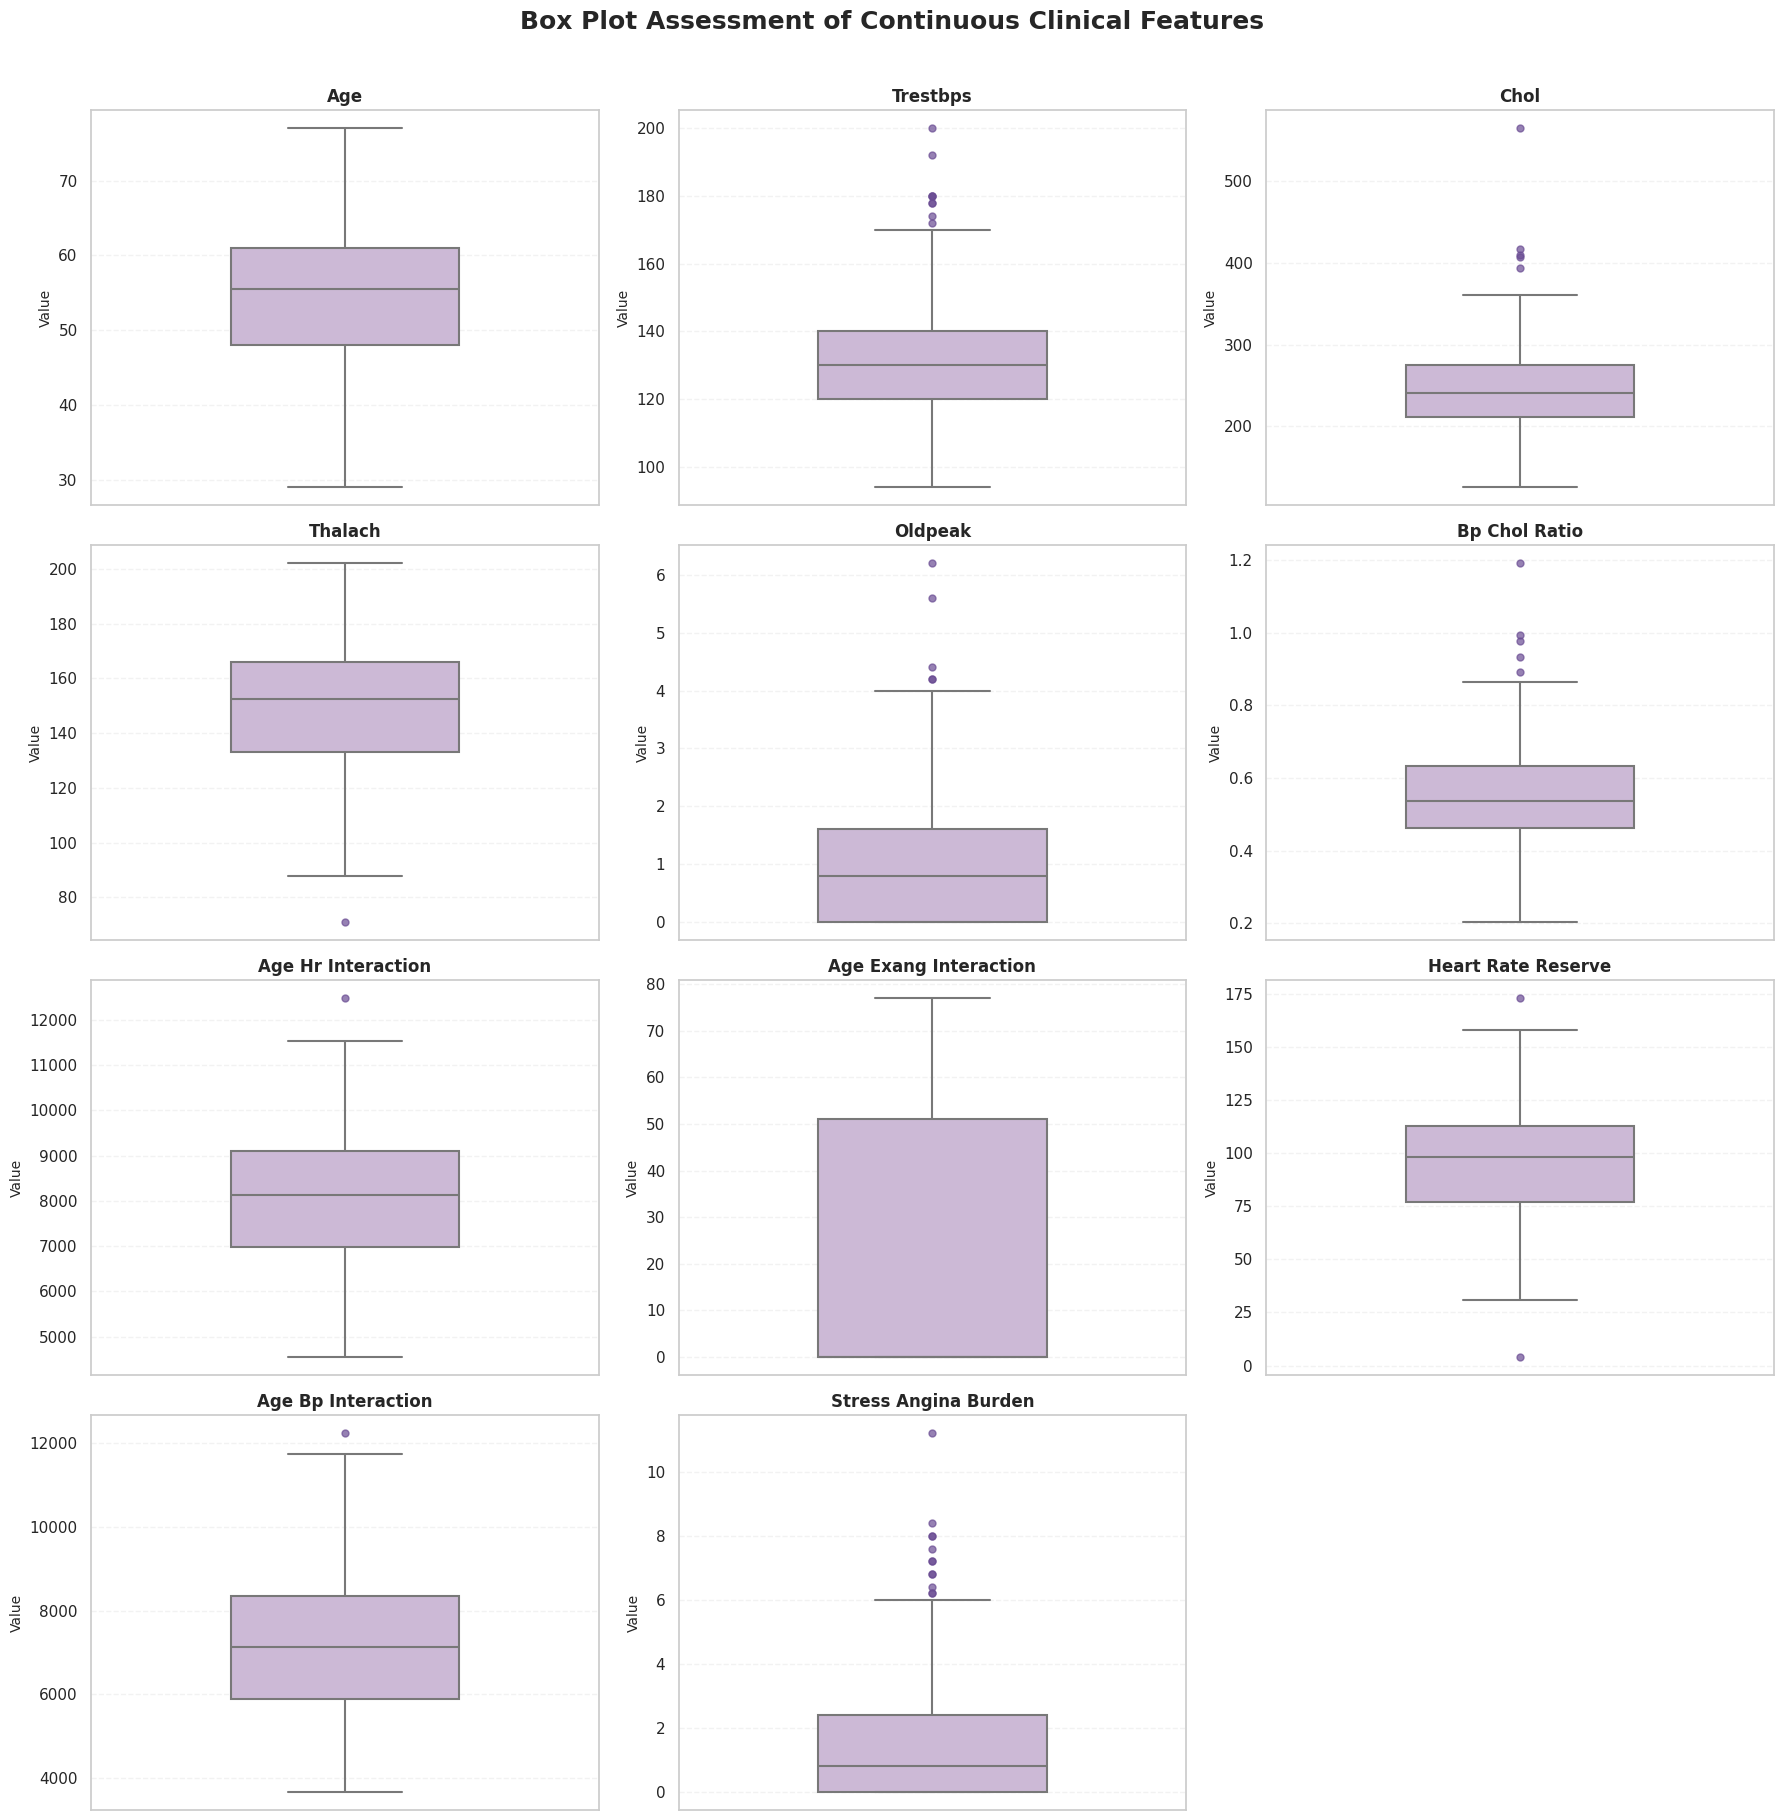

In [47]:
# ============================================================
# 10.2 Box Plots for Continuous Clinical Features
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

n_features = len(continuous_features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4.5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(continuous_features):

    sns.boxplot(
        y=df[feature],
        ax=axes[i],
        color="#CDB4DB",
        width=0.45,
        linewidth=1.5,
        flierprops={
            "marker": "o",
            "markerfacecolor": "#6A4C93",
            "markeredgecolor": "#6A4C93",
            "markersize": 5,
            "alpha": 0.7
        }
    )

    axes[i].set_title(
        feature.replace("_", " ").title(),
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_ylabel(
        "Value",
        fontsize=10
    )

    axes[i].grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Box Plot Assessment of Continuous Clinical Features",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

**Observation:**

The multi-panel box plot  evaluates the distributions and outlier structures of the continuous clinical features and engineered interaction variables within the dataset.

* **Core Clinical Features:**
* **Age:** Displays a symmetric distribution centered around a median of approximately 55, with an interquartile range spanning from roughly 48 to 61 and no extreme outliers.
* **Trestbps (Resting Blood Pressure):** Shows a moderate right-skew with a median around 130 and several notable upper-bound outliers extending up to 200.
* **Chol (Cholesterol):** Exhibits a pronounced right-skew, centered near a median of 240, with isolated upper outliers reaching past 500.
* **Thalach (Maximum Heart Rate Achieved):** Spans a wide range from roughly 70 to over 200, featuring a single lower outlier near 70 and a median close to 150.
* **Oldpeak (ST Depression):** Demonstrates a strong zero-inflation/right-skew, with the median resting at 0 and several upper-bound outliers extending past 6.


* **Engineered Interaction & Ratio Features:**
* **Bp Chol Ratio:** Maintains a compact distribution centered near 0.54 with a few upper outliers approaching 1.2.
* **Age Hr Interaction & Age Bp Interaction:** Both display similar symmetric spreads with medians around 8,000 and single upper outliers extending past 12,000.
* **Age Exang Interaction:** Features a compressed lower quartile starting at 0, reflecting categorical interaction dynamics.
* **Heart Rate Reserve & Stress Angina Burden:** Provide additional multi-variable spreads, with Heart Rate Reserve centered near a median of 100 and Stress Angina Burden showing an upper-skewed distribution with multiple outliers extending above 6 and reaching past 11.

In [48]:
# ============================================================
# 10.3 IQR-Based Outlier Detection
# ============================================================

outlier_results = []

for feature in continuous_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_results)

display(
    outlier_summary.round(3)
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age,48.000,61.000,13.000,28.500,80.500,0,0.000
1,trestbps,120.000,140.000,20.000,90.000,170.000,9,2.980
2,chol,211.000,274.750,63.750,115.375,370.375,5,1.656
3,thalach,133.250,166.000,32.750,84.125,215.125,1,0.331
4,oldpeak,0.000,1.600,1.600,-2.400,4.000,5,1.656
5,bp_chol_ratio,0.462,0.634,0.172,0.204,0.892,5,1.656
6,age_hr_interaction,6969.750,9106.000,2136.250,3765.375,12310.375,1,0.331
7,age_exang_interaction,0.000,51.000,51.000,-76.500,127.500,0,0.000
8,heart_rate_reserve,77.000,113.000,36.000,23.000,167.000,2,0.662
9,age_bp_interaction,5880.000,8361.250,2481.250,2158.125,12083.125,1,0.331


In [49]:
# ============================================================
# 10.4 Outlier Frequency Ranking
# ============================================================

outlier_ranking = (
    outlier_summary
    .sort_values(
        by="Outlier Count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    outlier_ranking.round(3)
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,stress_angina_burden,0.000,2.400,2.400,-3.600,6.000,12,3.974
1,trestbps,120.000,140.000,20.000,90.000,170.000,9,2.980
2,chol,211.000,274.750,63.750,115.375,370.375,5,1.656
3,bp_chol_ratio,0.462,0.634,0.172,0.204,0.892,5,1.656
4,oldpeak,0.000,1.600,1.600,-2.400,4.000,5,1.656
5,heart_rate_reserve,77.000,113.000,36.000,23.000,167.000,2,0.662
6,age_hr_interaction,6969.750,9106.000,2136.250,3765.375,12310.375,1,0.331
7,age_bp_interaction,5880.000,8361.250,2481.250,2158.125,12083.125,1,0.331
8,thalach,133.250,166.000,32.750,84.125,215.125,1,0.331
9,age,48.000,61.000,13.000,28.500,80.500,0,0.000


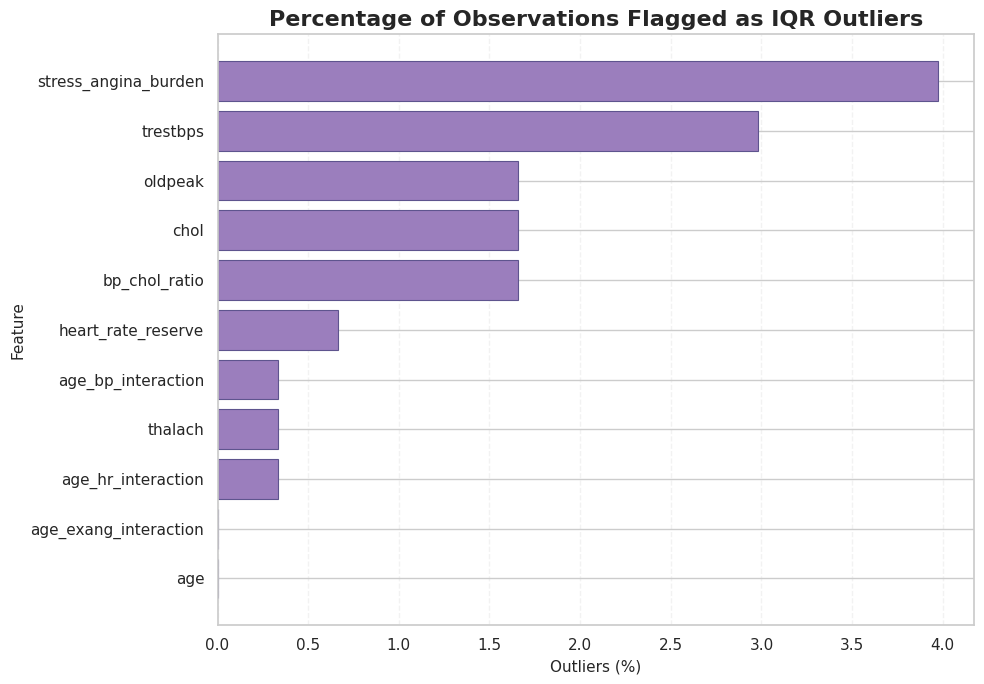

In [50]:
# ============================================================
# 10.5 Outlier Percentage by Feature
# ============================================================

plot_data = (
    outlier_summary
    .sort_values(
        "Outlier Percentage",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Feature"],
    plot_data["Outlier Percentage"],
    color="#9B7EBD",
    edgecolor="#5E548E",
    linewidth=0.8
)

plt.xlabel(
    "Outliers (%)",
    fontsize=11
)

plt.ylabel(
    "Feature",
    fontsize=11
)

plt.title(
    "Percentage of Observations Flagged as IQR Outliers",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

**Observation:**

The horizontal bar chart  quantifies the percentage of observations flagged as outliers using the Interquartile Range (IQR) method across the continuous clinical and engineered features.

The analysis indicates that outlier frequency is generally low across the dataset, with every feature exhibiting less than **4.0%** flagged points:

* **stress_angina_burden** records the highest outlier percentage at approximately **4.0%**.
* **trestbps** follows with roughly **3.0%** of its observations flagged.
* **oldpeak**, **chol**, and **bp_chol_ratio** each show an outlier rate of about **1.65%**.
* **heart_rate_reserve** registers at approximately **0.65%**.
* **age_bp_interaction**, **thalach**, and **age_hr_interaction** each display a minimal outlier rate of about **0.35%**.
* Finally, **age_exang_interaction** and **age** record **0%** flagged outliers, indicating completely bounded distributions within the standard IQR threshold.

Overall, the low percentage of extreme values suggests that the dataset is well-behaved and free of widespread anomalous scaling issues, minimizing the risk of distortion in subsequent modeling phases.

In [51]:
# ============================================================
# 10.6 Inspect Observations Flagged as Outliers
# ============================================================

outlier_values = {}

for feature in continuous_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )

    outlier_values[feature] = (
        df.loc[mask, feature]
        .sort_values()
        .tolist()
    )

for feature, values in outlier_values.items():

    if values:
        print(f"\n{feature}:")
        print(values)


trestbps:
[172, 174, 178, 178, 180, 180, 180, 192, 200]

chol:
[394, 407, 409, 417, 564]

thalach:
[71]

oldpeak:
[4.2, 4.2, 4.4, 5.6, 6.2]

bp_chol_ratio:
[0.8928571428571429, 0.9318181818181818, 0.975609756097561, 0.9923664122137404, 1.1904761904761905]

age_hr_interaction:
[12474]

heart_rate_reserve:
[4, 173]

age_bp_interaction:
[12240]

stress_angina_burden:
[6.2, 6.2, 6.4, 6.8, 6.8, 7.2, 7.2, 7.6, 8.0, 8.0, 8.4, 11.2]


## 10.7 Outlier Handling Strategy

The IQR method identifies observations that are statistically distant from the middle 50% of the distribution. However, statistical extremeness alone is not sufficient justification for removing a patient observation.

For this healthcare dataset, the following strategy is adopted:

| Feature Type | Strategy | Rationale |
|---|---|---|
| Age | Keep | Extreme ages within the observed dataset remain clinically plausible. |
| Resting blood pressure (`trestbps`) | Keep | High blood-pressure measurements can represent genuine cardiovascular risk and should not be discarded automatically. |
| Cholesterol (`chol`) | Keep | High cholesterol values may represent genuine patient conditions rather than data-entry errors. |
| Maximum heart rate (`thalach`) | Keep | Extreme values may reflect genuine differences in exercise response. |
| ST depression (`oldpeak`) | Keep | Higher ST depression can contain clinically meaningful cardiovascular information. |
| Engineered continuous features | Keep initially | Their extreme values are inherited from legitimate combinations of the original measurements. |

### Decision

**No observations will be removed or arbitrarily capped at this stage.**

The IQR method is therefore used for **detection and documentation**, rather than automatic deletion.

This decision is appropriate because:

- the dataset is relatively small;
- extreme clinical measurements may contain genuine predictive information;
- removing observations solely because they exceed an IQR boundary could eliminate clinically important cases;
- no evidence has been established that the identified observations are data-entry errors;
- tree-based models are generally less sensitive to extreme numerical values than distance-based or scale-sensitive algorithms.

Therefore, the original observations are retained for subsequent modeling.

If an observation were found to be physically impossible, clearly corrupted, or demonstrably caused by a data-entry error, removal or correction would be considered. No such assumption is made based solely on the IQR criterion.

In [52]:
# ============================================================
# 10.8 Verify That No Observations Were Removed
# ============================================================

print("Dataset shape before/after outlier handling:")
print(f"Current dataset shape: {df.shape}")

print("\nTarget distribution remains:")
display(
    df["target"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "No Disease",
        1: "Disease"
    })
    .to_frame("Count")
)

print("\nOutlier handling decision:")
print("Statistical outliers were identified but not removed or capped.")
print("Clinically plausible observations were retained.")

Dataset shape before/after outlier handling:
Current dataset shape: (302, 22)

Target distribution remains:


,Count
target,
No Disease,138
Disease,164



Outlier handling decision:
Statistical outliers were identified but not removed or capped.
Clinically plausible observations were retained.


### 10.9 Conclusion

The IQR-based analysis identified potential statistical outliers across several continuous clinical and engineered variables. However, the presence of an IQR-defined outlier does not necessarily indicate an invalid patient observation.

Given the clinical context, relatively small sample size, and potential predictive value of extreme measurements, the identified observations were retained rather than removed or capped.

This approach preserves the information contained in the original patient population while maintaining a transparent record of the outlier analysis and handling decision.

The cleaned and feature-engineered `df` is therefore retained as the master dataset for the next stage: **train-test splitting and baseline model development**.

# 11. Model Building & Training

This section establishes the baseline performance of four tree-based classification models for predicting heart disease:

1. Decision Tree
2. Random Forest
3. Gradient Boosting
4. XGBoost

All models are evaluated using the same train-test split and evaluation framework to ensure a fair comparison.

The dataset is divided into training and testing subsets using a 70:30 split with stratified sampling and `random_state=42`. Stratification preserves the target-class distribution in both subsets.

For the training data, 5-fold Stratified Cross-Validation is used to obtain robust estimates of model performance across multiple validation folds.

The following metrics are reported:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Cross-validation results are reported as **mean ± standard deviation**.

After cross-validation, each baseline model is fitted on the complete training set and evaluated once on the held-out test set. Confusion matrices and ROC curves are then generated to provide additional insight into classification behavior.

No hyperparameter tuning is performed in this section. The purpose is to establish a reproducible baseline against which the tuned models will be compared later.

In [53]:
# ============================================================
# 11.1 Imports and Reproducibility
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

In [54]:
# ============================================================
# 11.2 Define Predictors and Target
# ============================================================

X = df.drop(columns="target")
y = df["target"]

print("Predictor matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
display(
    y.value_counts()
      .sort_index()
      .rename(index={
          0: "No Disease",
          1: "Disease"
      })
      .to_frame("Count")
)

Predictor matrix shape: (302, 21)
Target shape: (302,)

Target distribution:


,Count
target,
No Disease,138
Disease,164


In [55]:
# ============================================================
# 11.3 Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
display(
    y_train.value_counts(normalize=True)
          .sort_index()
          .mul(100)
          .round(2)
          .rename(index={
              0: "No Disease",
              1: "Disease"
          })
          .to_frame("Percentage")
)

print("\nTesting target distribution:")
display(
    y_test.value_counts(normalize=True)
         .sort_index()
         .mul(100)
         .round(2)
         .rename(index={
             0: "No Disease",
             1: "Disease"
         })
         .to_frame("Percentage")
)

Training set shape: (211, 21)
Testing set shape: (91, 21)

Training target distribution:


,Percentage
target,
No Disease,45.500
Disease,54.500



Testing target distribution:


,Percentage
target,
No Disease,46.150
Disease,53.850


### Train-Test Split

A stratified 70:30 train-test split is used to preserve the relative proportion of disease and no-disease cases in both subsets.

The training set is used exclusively for model fitting and cross-validation, while the test set remains untouched until final evaluation.

This separation prevents information from the test set from influencing model development and provides an unbiased estimate of generalization performance.

`random_state=42` is applied to ensure reproducibility.

In [56]:
# ============================================================
# 11.4 Baseline Model Definitions
# ============================================================

models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

print("Baseline models:")
for name, model in models.items():
    print(f"- {name}: {model.__class__.__name__}")

Baseline models:
- Decision Tree: DecisionTreeClassifier
- Random Forest: RandomForestClassifier
- Gradient Boosting: GradientBoostingClassifier
- XGBoost: XGBClassifier


In [57]:
# ============================================================
# 11.5 Stratified 5-Fold Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [58]:
# ============================================================
# 11.6 Baseline Training, Cross-Validation and Test Evaluation
# ============================================================

baseline_results = []
trained_models = {}

for model_name, model in models.items():

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Five-fold stratified cross-validation on TRAINING data
    # --------------------------------------------------------
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    # --------------------------------------------------------
    # 2. Fit baseline model on complete training data
    # --------------------------------------------------------
    model.fit(X_train, y_train)

    trained_models[model_name] = model

    # --------------------------------------------------------
    # 3. Test-set predictions
    # --------------------------------------------------------
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # 4. Test-set metrics
    # --------------------------------------------------------
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, zero_division=0)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, y_prob)

    # --------------------------------------------------------
    # 5. Store CV + test results
    # --------------------------------------------------------
    baseline_results.append({
        "Model": model_name,

        "CV Accuracy Mean": cv_results["test_accuracy"].mean(),
        "CV Accuracy Std": cv_results["test_accuracy"].std(),

        "CV Precision Mean": cv_results["test_precision"].mean(),
        "CV Precision Std": cv_results["test_precision"].std(),

        "CV Recall Mean": cv_results["test_recall"].mean(),
        "CV Recall Std": cv_results["test_recall"].std(),

        "CV F1 Mean": cv_results["test_f1"].mean(),
        "CV F1 Std": cv_results["test_f1"].std(),

        "CV AUC Mean": cv_results["test_roc_auc"].mean(),
        "CV AUC Std": cv_results["test_roc_auc"].std(),

        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1,
        "Test AUC": test_auc
    })

    print(
        f"CV Accuracy : {cv_results['test_accuracy'].mean():.3f} "
        f"± {cv_results['test_accuracy'].std():.3f}"
    )

    print(
        f"CV Precision: {cv_results['test_precision'].mean():.3f} "
        f"± {cv_results['test_precision'].std():.3f}"
    )

    print(
        f"CV Recall   : {cv_results['test_recall'].mean():.3f} "
        f"± {cv_results['test_recall'].std():.3f}"
    )

    print(
        f"CV F1       : {cv_results['test_f1'].mean():.3f} "
        f"± {cv_results['test_f1'].std():.3f}"
    )

    print(
        f"CV ROC-AUC  : {cv_results['test_roc_auc'].mean():.3f} "
        f"± {cv_results['test_roc_auc'].std():.3f}"
    )

    print(f"\nTest Accuracy : {test_accuracy:.3f}")
    print(f"Test Precision: {test_precision:.3f}")
    print(f"Test Recall   : {test_recall:.3f}")
    print(f"Test F1       : {test_f1:.3f}")
    print(f"Test ROC-AUC  : {test_auc:.3f}")

Training: Decision Tree
CV Accuracy : 0.706 ± 0.034
CV Precision: 0.733 ± 0.052
CV Recall   : 0.739 ± 0.039
CV F1       : 0.733 ± 0.016
CV ROC-AUC  : 0.702 ± 0.040

Test Accuracy : 0.725
Test Precision: 0.750
Test Recall   : 0.735
Test F1       : 0.742
Test ROC-AUC  : 0.724
Training: Random Forest
CV Accuracy : 0.824 ± 0.072
CV Precision: 0.843 ± 0.106
CV Recall   : 0.861 ± 0.084
CV F1       : 0.844 ± 0.053
CV ROC-AUC  : 0.897 ± 0.059

Test Accuracy : 0.791
Test Precision: 0.750
Test Recall   : 0.918
Test F1       : 0.826
Test ROC-AUC  : 0.873
Training: Gradient Boosting
CV Accuracy : 0.801 ± 0.054
CV Precision: 0.821 ± 0.104
CV Recall   : 0.843 ± 0.090
CV F1       : 0.823 ± 0.039
CV ROC-AUC  : 0.882 ± 0.058

Test Accuracy : 0.769
Test Precision: 0.733
Test Recall   : 0.898
Test F1       : 0.807
Test ROC-AUC  : 0.884
Training: XGBoost
CV Accuracy : 0.806 ± 0.058
CV Precision: 0.836 ± 0.105
CV Recall   : 0.835 ± 0.121
CV F1       : 0.823 ± 0.048
CV ROC-AUC  : 0.905 ± 0.036

Test Accurac

In [59]:
# ============================================================
# 11.7 Baseline Results Comparison
# ============================================================

baseline_results_df = pd.DataFrame(baseline_results)

display(
    baseline_results_df.round(4)
)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV AUC Mean,CV AUC Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Decision Tree,0.706,0.034,0.733,0.052,0.739,0.039,0.733,0.016,0.702,0.040,0.725,0.750,0.735,0.742,0.725
1,Random Forest,0.825,0.072,0.843,0.106,0.861,0.084,0.844,0.053,0.897,0.059,0.791,0.750,0.918,0.826,0.873
2,Gradient Boosting,0.801,0.054,0.821,0.104,0.844,0.089,0.823,0.039,0.882,0.058,0.769,0.733,0.898,0.807,0.884
3,XGBoost,0.805,0.058,0.836,0.105,0.835,0.121,0.823,0.049,0.905,0.036,0.780,0.764,0.857,0.808,0.881


In [60]:
# ============================================================
# 11.8 Publication-Style Cross-Validation Comparison
# ============================================================

cv_comparison = baseline_results_df[
    [
        "Model",
        "CV Accuracy Mean",
        "CV Accuracy Std",
        "CV Precision Mean",
        "CV Precision Std",
        "CV Recall Mean",
        "CV Recall Std",
        "CV F1 Mean",
        "CV F1 Std",
        "CV AUC Mean",
        "CV AUC Std"
    ]
].copy()

for metric in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:

    mean_col = f"CV {metric} Mean"
    std_col = f"CV {metric} Std"

    cv_comparison[f"{metric} (Mean ± Std)"] = (
        cv_comparison[mean_col].map(lambda x: f"{x:.3f}")
        + " ± "
        + cv_comparison[std_col].map(lambda x: f"{x:.3f}")
    )

final_cv_table = cv_comparison[
    [
        "Model",
        "Accuracy (Mean ± Std)",
        "Precision (Mean ± Std)",
        "Recall (Mean ± Std)",
        "F1 (Mean ± Std)",
        "AUC (Mean ± Std)"
    ]
]

display(final_cv_table)

,Model,Accuracy (Mean ± Std),Precision (Mean ± Std),Recall (Mean ± Std),F1 (Mean ± Std),AUC (Mean ± Std)
0,Decision Tree,0.706 ± 0.034,0.733 ± 0.052,0.739 ± 0.039,0.733 ± 0.016,0.702 ± 0.040
1,Random Forest,0.824 ± 0.072,0.843 ± 0.106,0.861 ± 0.084,0.844 ± 0.053,0.897 ± 0.059
2,Gradient Boosting,0.801 ± 0.054,0.821 ± 0.104,0.843 ± 0.090,0.823 ± 0.039,0.882 ± 0.058
3,XGBoost,0.806 ± 0.058,0.836 ± 0.105,0.835 ± 0.121,0.823 ± 0.048,0.905 ± 0.036


In [61]:
# ============================================================
# 11.9 Test-Set Performance Comparison
# ============================================================

test_comparison = baseline_results_df[
    [
        "Model",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test AUC"
    ]
].copy()

display(
    test_comparison.round(4)
)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Decision Tree,0.725,0.750,0.735,0.742,0.725
1,Random Forest,0.791,0.750,0.918,0.826,0.873
2,Gradient Boosting,0.769,0.733,0.898,0.807,0.884
3,XGBoost,0.780,0.764,0.857,0.808,0.881


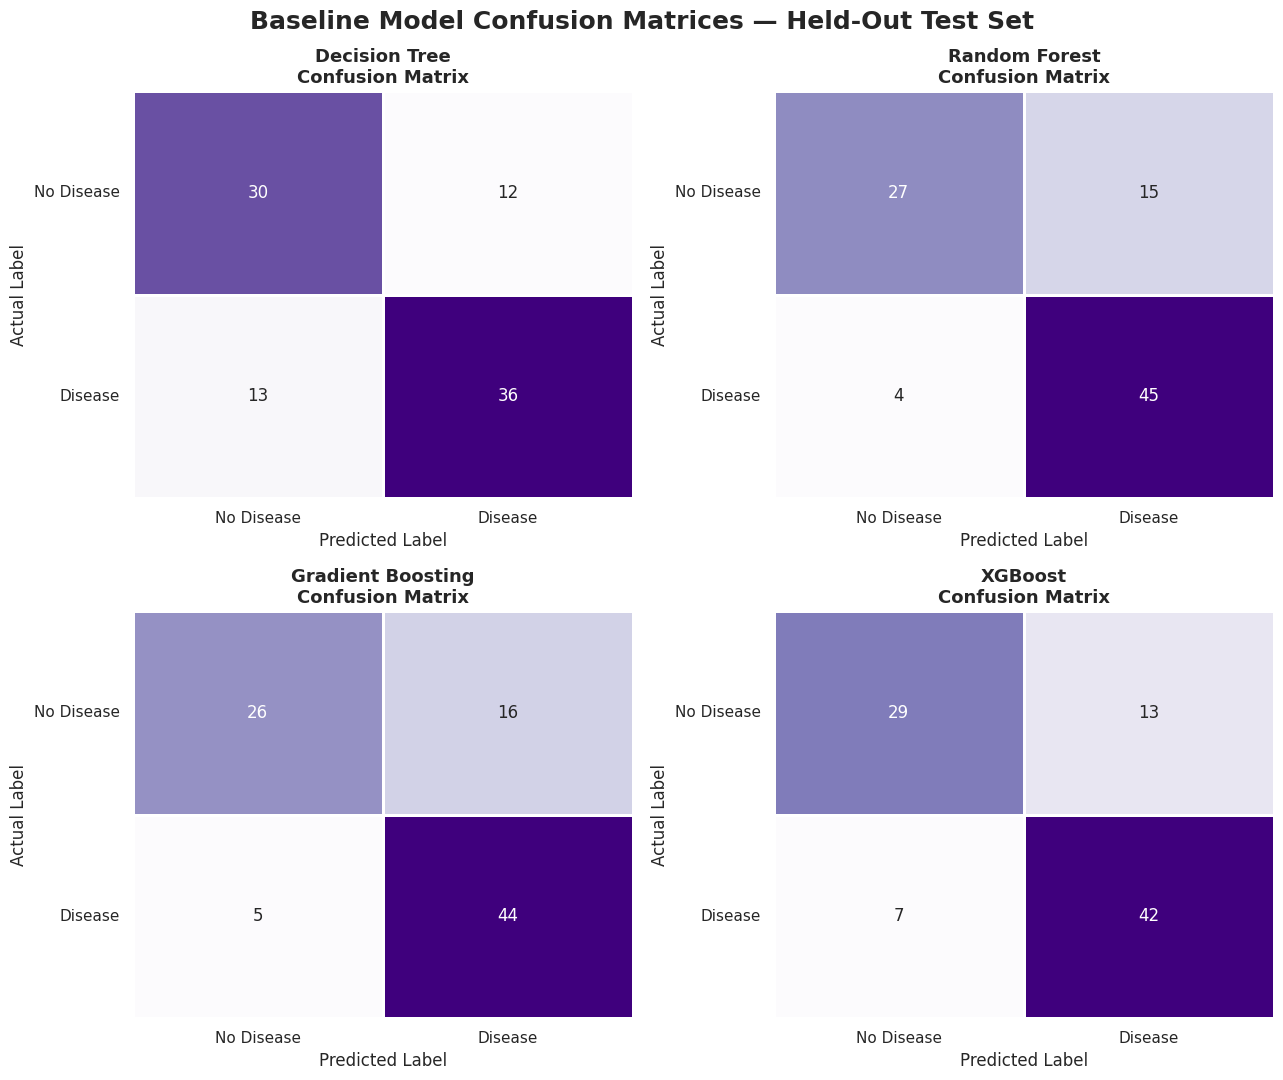

In [62]:
# ============================================================
# 11.10 Confusion Matrices for All Baseline Models
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 11)
)

axes = axes.flatten()

for ax, (model_name, model) in zip(
    axes,
    trained_models.items()
):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Purples",
        cbar=False,
        linewidths=1,
        linecolor="white",
        ax=ax
    )

    ax.set_title(
        f"{model_name}\nConfusion Matrix",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

    ax.set_xticklabels(
        ["No Disease", "Disease"]
    )

    ax.set_yticklabels(
        ["No Disease", "Disease"],
        rotation=0
    )

fig.suptitle(
    "Baseline Model Confusion Matrices — Held-Out Test Set",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Observation:**

The four confusion matrices  evaluate the performance of the baseline machine learning models on the held-out test set:

* **Decision Tree:** Achieves 30 true negatives and 36 true positives, alongside 12 false positives and 13 false negatives.
* **Random Forest:** Demonstrates strong positive class recall with 45 true positives and only 4 false negatives, though it records 27 true negatives and 15 false positives.
* **Gradient Boosting:** Yields 26 true negatives and 44 true positives, with 16 false positives and 5 false negatives.
* **XGBoost:** Shows a balanced classification profile with 29 true negatives, 42 true positives, 13 false positives, and 7 false negatives.

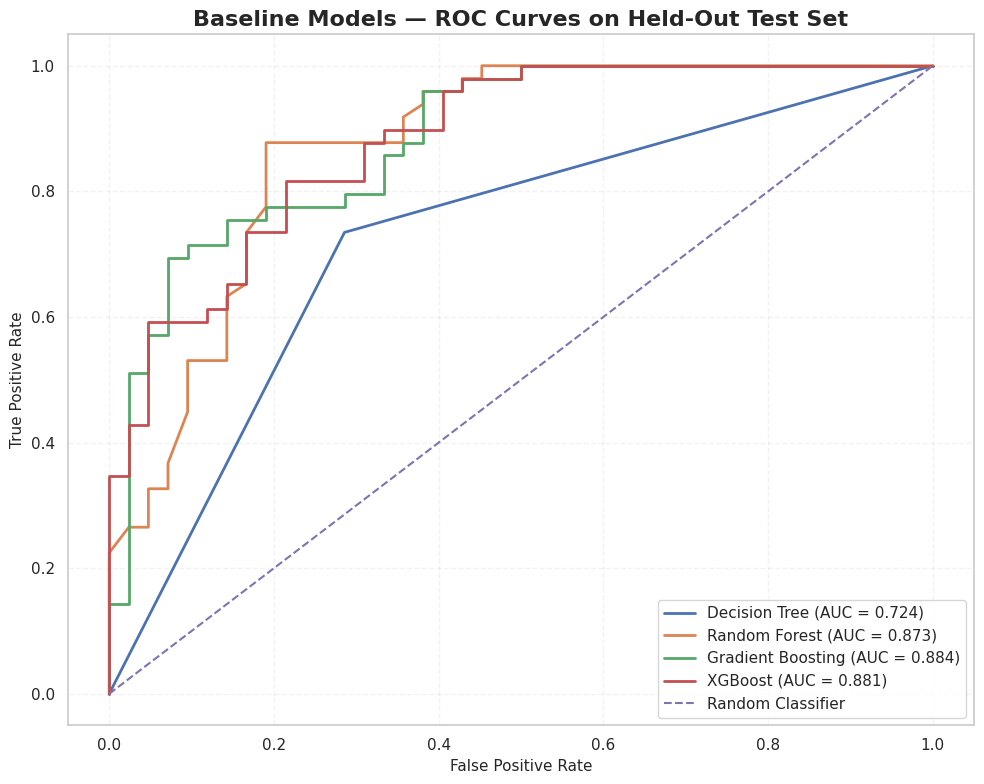

In [63]:
# ============================================================
# 11.11 ROC Curves for All Baseline Models
# ============================================================

plt.figure(figsize=(10, 8))

for model_name, model in trained_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=11
)

plt.ylabel(
    "True Positive Rate",
    fontsize=11
)

plt.title(
    "Baseline Models — ROC Curves on Held-Out Test Set",
    fontsize=16,
    fontweight="bold"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

**Observation:**

The ROC curves  evaluate the discriminative ability of the baseline models on the held-out test set:

* **Gradient Boosting:** Achieves the highest performance with an **AUC of 0.884**, demonstrating superior class separation.
* **XGBoost:** Follows closely with an **AUC of 0.881**.
* **Random Forest:** Secures strong results with an **AUC of 0.873**.
* **Decision Tree:** Trails the ensemble methods with an **AUC of 0.724**.

## 11.12 Baseline Performance Interpretation

The baseline results provide an initial comparison of the four tree-based classification algorithms before any hyperparameter optimization.

The models were evaluated using the same 70:30 stratified train-test split and a 5-fold Stratified Cross-Validation procedure on the training set. This consistent evaluation framework allows the models to be compared under the same experimental conditions.

### Cross-Validation Performance

The Decision Tree produced the weakest overall baseline performance, with a mean accuracy of **0.706 ± 0.034** and a mean ROC-AUC of **0.702 ± 0.040**. Its relatively low AUC indicates weaker discrimination between patients with and without heart disease compared with the ensemble methods.

The Random Forest achieved the strongest overall cross-validation performance across several metrics. It obtained a mean accuracy of **0.824 ± 0.072**, mean precision of **0.843 ± 0.106**, mean recall of **0.861 ± 0.084**, mean F1-score of **0.844 ± 0.053**, and mean ROC-AUC of **0.897 ± 0.059**.

Gradient Boosting also performed strongly, reaching a mean accuracy of **0.801 ± 0.054** and a mean ROC-AUC of **0.882 ± 0.058**. Its recall of **0.843 ± 0.090** indicates that it identified a substantial proportion of the disease cases during cross-validation.

XGBoost achieved the highest cross-validation ROC-AUC at **0.905 ± 0.036**, indicating the strongest average discrimination among the four baseline models. It also achieved a mean accuracy of **0.806 ± 0.058** and a mean F1-score of **0.823 ± 0.048**.

### Held-Out Test Performance

On the independent test set, Random Forest achieved the highest accuracy (**0.791**) and the highest recall (**0.918**) among the four baseline models. Its F1-score was also the highest at **0.826**, indicating a strong balance between precision and recall for the disease class.

Gradient Boosting achieved the highest test ROC-AUC at **0.884**, followed closely by XGBoost at **0.881** and Random Forest at **0.873**. This indicates that Gradient Boosting provided the strongest class-ranking performance on this particular held-out test set.

XGBoost achieved the highest test precision (**0.764**), meaning that among the patients predicted as having heart disease, a relatively large proportion were actual disease cases.

The Decision Tree consistently lagged behind the ensemble methods, with a test accuracy of **0.725** and test ROC-AUC of **0.724**.

Overall, the baseline results indicate that ensemble-based tree methods provide a substantial improvement over a single Decision Tree for this dataset. However, the differences between Random Forest, Gradient Boosting, and XGBoost are not sufficiently large to determine the final model at this stage. Hyperparameter optimization will therefore be used in the next section to determine whether these models can achieve improved and more stable performance.

## 11.13 Baseline Model Comparison — Key Findings

The baseline comparison demonstrates clear differences in model behavior across the four algorithms.

### 1. Decision Tree

The Decision Tree provides the weakest baseline performance overall. Its cross-validation ROC-AUC of **0.702 ± 0.040** and test ROC-AUC of **0.724** indicate comparatively limited ability to separate the two target classes.

The model nevertheless achieves reasonable recall, but its performance is less consistent and less competitive than the ensemble approaches. This behavior is expected from a single decision tree, which can have relatively high variance and may be sensitive to the particular structure of the training data.

### 2. Random Forest

Random Forest provides the strongest overall baseline profile across the cross-validation metrics. It achieves the highest cross-validation accuracy, precision, recall, and F1-score among the four models.

On the test set, it also achieves the highest recall (**0.918**) and F1-score (**0.826**). The confusion matrix shows that it identifies **45 of the 49 disease cases**, resulting in only **4 false negatives**.

This is particularly relevant in the healthcare context because missing a patient who actually has heart disease can be more consequential than incorrectly flagging a patient for further assessment.

### 3. Gradient Boosting

Gradient Boosting performs substantially better than the single Decision Tree and provides strong classification performance overall.

Its test ROC-AUC of **0.884** is the highest among the four models on the held-out test set, indicating strong discrimination between the two classes.

However, it produces more false positives than Random Forest, resulting in a slightly lower test precision (**0.733**) despite its high recall (**0.898**).

### 4. XGBoost

XGBoost demonstrates the strongest average cross-validation discrimination, with a ROC-AUC of **0.905 ± 0.036**, which is the highest CV AUC among the four baseline models.

Its test performance is also competitive, with an accuracy of **0.780**, precision of **0.764**, recall of **0.857**, F1-score of **0.808**, and ROC-AUC of **0.881**.

An important observation is that XGBoost has a relatively small cross-validation AUC standard deviation (**0.036**) compared with Random Forest (**0.059**) and Gradient Boosting (**0.058**). This suggests comparatively stable discrimination across the five validation folds, although the dataset is small and the variability should still be interpreted cautiously.

### Overall Baseline Conclusion

No single model dominates every metric.

- **Random Forest** provides the strongest overall baseline profile across cross-validation and achieves the highest test recall and F1-score.
- **Gradient Boosting** achieves the highest test ROC-AUC.
- **XGBoost** achieves the highest cross-validation ROC-AUC and the highest test precision.
- **Decision Tree** performs substantially below the ensemble methods.

These results demonstrate why multiple evaluation metrics are necessary. Accuracy alone would not capture the different trade-offs between false positives and false negatives, particularly in a healthcare classification problem.

At this stage, the models should be considered **baseline models rather than final candidates**. The next stage will apply systematic hyperparameter optimization using 5-fold Stratified Cross-Validation. The tuned models will then be compared against these baseline results to determine whether optimization produces meaningful improvements in predictive performance.

# 12. Hyperparameter Tuning

The baseline models established the initial performance of the four tree-based algorithms using their default configurations. In this section, hyperparameter optimization is performed to determine whether model performance can be improved through systematic parameter selection.

`RandomizedSearchCV` is used for all four models with **5-fold Stratified Cross-Validation**. Stratification ensures that the proportion of patients with and without heart disease is maintained across validation folds.

The hyperparameter search is performed using the training data only. The held-out test set remains completely untouched throughout the tuning process and is used only after the optimal configuration has been selected.

The following parameters are tuned according to the task requirements:

| Model | Hyperparameters |
|---|---|
| Decision Tree | `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`, `max_features` |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split`, `max_features`, `bootstrap` |
| Gradient Boosting | `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `min_samples_split` |
| XGBoost | `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` |

ROC-AUC is used as the optimization metric because the problem is a binary healthcare classification task and discrimination between the disease and no-disease classes is clinically important.

The optimized models will subsequently be evaluated on the untouched test set and compared against their corresponding baseline models.

In [64]:
# ============================================================
# 12.1 Hyperparameter Tuning Imports
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

print("RandomizedSearchCV imported successfully.")

RandomizedSearchCV imported successfully.


In [65]:
# ============================================================
# 12.2 Hyperparameter Search Spaces
# ============================================================

param_distributions = {

    # --------------------------------------------------------
    # Decision Tree
    # --------------------------------------------------------
    "Decision Tree": {
        "max_depth": [None, 3, 4, 5, 6, 8, 10, 12, 15, 20],
        "min_samples_split": randint(2, 21),
        "min_samples_leaf": randint(1, 11),
        "criterion": ["gini", "entropy", "log_loss"],
        "max_features": [None, "sqrt", "log2"]
    },

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------
    "Random Forest": {
        "n_estimators": randint(100, 501),
        "max_depth": [None, 3, 4, 5, 6, 8, 10, 12, 15, 20],
        "min_samples_split": randint(2, 16),
        "max_features": [None, "sqrt", "log2"],
        "bootstrap": [True, False]
    },

    # --------------------------------------------------------
    # Gradient Boosting
    # --------------------------------------------------------
    "Gradient Boosting": {
        "n_estimators": randint(50, 401),
        "learning_rate": uniform(0.01, 0.19),
        "max_depth": randint(1, 8),
        "subsample": uniform(0.6, 0.4),
        "min_samples_split": randint(2, 16)
    },

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------
    "XGBoost": {
        "n_estimators": randint(50, 401),
        "learning_rate": loguniform(0.01, 0.3),
        "max_depth": randint(2, 9),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "reg_alpha": loguniform(1e-4, 10),
        "reg_lambda": loguniform(1e-2, 10)
    }
}

In [66]:
# ============================================================
# 12.3 Models for Hyperparameter Optimization
# ============================================================

tuning_models = {

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

print("Tuning models initialized successfully.")

Tuning models initialized successfully.


In [67]:
# ============================================================
# 12.4 Randomized Hyperparameter Search
# ============================================================

tuned_models = {}
tuning_results = []

N_ITER = 50

for model_name, model in tuning_models.items():

    print("=" * 75)
    print(f"Hyperparameter tuning: {model_name}")
    print("=" * 75)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[model_name],
        n_iter=N_ITER,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    search.fit(X_train, y_train)

    tuned_models[model_name] = search.best_estimator_

    tuning_results.append({
        "Model": model_name,
        "Best CV ROC-AUC": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print(f"\nBest CV ROC-AUC: {search.best_score_:.4f}")
    print("Best Parameters:")

    for parameter, value in search.best_params_.items():
        print(f"  {parameter}: {value}")

Hyperparameter tuning: Decision Tree
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV ROC-AUC: 0.8632
Best Parameters:
  criterion: entropy
  max_depth: 8
  max_features: None
  min_samples_leaf: 9
  min_samples_split: 18
Hyperparameter tuning: Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV ROC-AUC: 0.9075
Best Parameters:
  bootstrap: True
  max_depth: None
  max_features: log2
  min_samples_split: 15
  n_estimators: 229
Hyperparameter tuning: Gradient Boosting
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV ROC-AUC: 0.9108
Best Parameters:
  learning_rate: 0.03319671139312794
  max_depth: 1
  min_samples_split: 8
  n_estimators: 239
  subsample: 0.6440207698110707
Hyperparameter tuning: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV ROC-AUC: 0.9121
Best Parameters:
  colsample_bytree: 0.8244973703390804
  learning_rate: 0.036781499095023595
  max_depth: 8
  n_estimators:

In [68]:
# ============================================================
# 12.5 Best Hyperparameters Summary
# ============================================================

tuning_results_df = pd.DataFrame(tuning_results)

display(tuning_results_df)

,Model,Best CV ROC-AUC,Best Parameters
0,Decision Tree,0.863,"{'criterion': 'entropy', 'max_depth': 8, 'max_..."
1,Random Forest,0.908,"{'bootstrap': True, 'max_depth': None, 'max_fe..."
2,Gradient Boosting,0.911,"{'learning_rate': 0.03319671139312794, 'max_de..."
3,XGBoost,0.912,"{'colsample_bytree': 0.8244973703390804, 'lear..."


In [69]:
# ============================================================
# 12.6 Clean Hyperparameter Comparison Table
# ============================================================

best_parameters_df = pd.DataFrame(
    [
        {
            "Model": model_name,
            **search_params
        }
        for model_name, search_params in [
            (
                result["Model"],
                result["Best Parameters"]
            )
            for result in tuning_results
        ]
    ]
)

display(best_parameters_df)

,Model,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,bootstrap,n_estimators,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda
0,Decision Tree,entropy,8.000,None,9.000,18.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,NaN,NaN,log2,NaN,15.000,True,229.000,NaN,NaN,NaN,NaN,NaN
2,Gradient Boosting,NaN,1.000,NaN,NaN,8.000,NaN,239.000,0.033,0.644,NaN,NaN,NaN
3,XGBoost,NaN,8.000,NaN,NaN,NaN,NaN,180.000,0.037,0.908,0.824,0.637,0.483


## 12.7 Hyperparameter Optimization Results

The hyperparameter optimization stage was successfully completed for all four tree-based models using `RandomizedSearchCV` with **5-fold Stratified Cross-Validation**.

The search was performed exclusively on the training set, while the held-out test set remained completely untouched. Therefore, the test data was not used for model selection or hyperparameter optimization, preserving the integrity of the final evaluation.

ROC-AUC was selected as the optimization metric because it provides a threshold-independent measure of the model's ability to distinguish between patients with and without heart disease.

### Best Cross-Validated Configurations

The optimized models achieved the following best mean cross-validated ROC-AUC scores:

- **Decision Tree:** 0.8632
- **Random Forest:** 0.9075
- **Gradient Boosting:** 0.9108
- **XGBoost:** 0.9121

Among the four optimized models, **XGBoost achieved the highest cross-validated ROC-AUC (0.9121)**, followed closely by Gradient Boosting (0.9108) and Random Forest (0.9075). The optimized Decision Tree also showed a substantial improvement compared with its baseline cross-validation ROC-AUC.

The selected hyperparameters indicate different model-complexity strategies across the algorithms. For example, the optimized Gradient Boosting model selected a shallow tree depth of 1 together with a relatively low learning rate and subsampling, suggesting that a more conservative boosting strategy provided better cross-validated discrimination. In contrast, XGBoost selected a deeper tree structure together with regularization and feature/row subsampling.

These results demonstrate that the default configurations were not necessarily optimal for this dataset. The next step is therefore to evaluate the optimized models on the **untouched test set** and compare their performance directly with the baseline models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [70]:
# ============================================================
# 12.8 Evaluate Tuned Models on the Held-Out Test Set
# ============================================================

tuned_test_results = []

for model_name, model in tuned_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_test_results.append({
        "Model": model_name,
        "Test Accuracy": accuracy_score(
            y_test, y_pred
        ),
        "Test Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Test Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "Test F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "Test AUC": roc_auc_score(
            y_test, y_prob
        )
    })

tuned_test_results_df = pd.DataFrame(
    tuned_test_results
)

display(
    tuned_test_results_df.round(4)
)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Decision Tree,0.780,0.784,0.816,0.800,0.815
1,Random Forest,0.813,0.758,0.959,0.847,0.880
2,Gradient Boosting,0.769,0.741,0.878,0.804,0.882
3,XGBoost,0.769,0.733,0.898,0.807,0.875


In [71]:
# ============================================================
# 12.9 Baseline vs Tuned Test Performance
# ============================================================

baseline_test = baseline_results_df[
    [
        "Model",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test AUC"
    ]
].copy()

baseline_test["Model Type"] = "Baseline"

tuned_test = tuned_test_results_df.copy()
tuned_test["Model Type"] = "Tuned"

baseline_vs_tuned = pd.concat(
    [
        baseline_test,
        tuned_test
    ],
    ignore_index=True
)

baseline_vs_tuned = baseline_vs_tuned[
    [
        "Model",
        "Model Type",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test AUC"
    ]
]

display(
    baseline_vs_tuned.round(4)
)

,Model,Model Type,Test Accuracy,Test Precision,Test Recall,Test F1,Test AUC
0,Decision Tree,Baseline,0.725,0.750,0.735,0.742,0.725
1,Random Forest,Baseline,0.791,0.750,0.918,0.826,0.873
2,Gradient Boosting,Baseline,0.769,0.733,0.898,0.807,0.884
3,XGBoost,Baseline,0.780,0.764,0.857,0.808,0.881
4,Decision Tree,Tuned,0.780,0.784,0.816,0.800,0.815
5,Random Forest,Tuned,0.813,0.758,0.959,0.847,0.880
6,Gradient Boosting,Tuned,0.769,0.741,0.878,0.804,0.882
7,XGBoost,Tuned,0.769,0.733,0.898,0.807,0.875


In [72]:
# ============================================================
# 12.10 Performance Improvement After Tuning
# ============================================================

baseline_metrics = baseline_results_df.set_index("Model")[
    [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test AUC"
    ]
]

tuned_metrics = tuned_test_results_df.set_index("Model")[
    [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test AUC"
    ]
]

improvement_df = (
    tuned_metrics - baseline_metrics
).reset_index()

improvement_df.columns = [
    "Model",
    "Δ Accuracy",
    "Δ Precision",
    "Δ Recall",
    "Δ F1",
    "Δ AUC"
]

display(
    improvement_df.round(4)
)

,Model,Δ Accuracy,Δ Precision,Δ Recall,Δ F1,Δ AUC
0,Decision Tree,0.055,0.034,0.082,0.058,0.090
1,Random Forest,0.022,0.008,0.041,0.021,0.007
2,Gradient Boosting,0.000,0.008,-0.020,-0.004,-0.002
3,XGBoost,-0.011,-0.030,0.041,-0.000,-0.006


## 12.12 Baseline vs Tuned Models — Final Analysis

The baseline and optimized models were evaluated using the same held-out test set to determine whether hyperparameter optimization produced meaningful improvements in generalization performance.

The results show that hyperparameter tuning affected the four models differently. Importantly, improvement was not observed uniformly across all evaluation metrics, demonstrating why model selection should consider the overall performance profile rather than a single metric.

### Decision Tree

The tuned Decision Tree showed the clearest improvement among the individual-tree models. Test accuracy increased from **0.725 to 0.780**, while precision increased from **0.750 to 0.784**, recall increased from **0.735 to 0.816**, and F1-score increased from **0.742 to 0.800**.

Its test ROC-AUC also increased from **0.725 to 0.815**, representing the largest AUC improvement among the four models (**+0.090**).

This indicates that the selected hyperparameters successfully reduced some of the limitations of the baseline tree while improving its ability to distinguish between the two target classes.

### Random Forest

Random Forest produced the strongest overall improvement in terms of the healthcare-oriented classification objective.

Its test accuracy increased from **0.791 to 0.813**, while recall increased from **0.918 to 0.959**. The F1-score also improved from **0.826 to 0.847**, representing the highest tuned test F1-score among all four models.

The increase in recall is particularly important for this healthcare problem. The tuned Random Forest identifies a larger proportion of patients with heart disease, thereby reducing the risk of false-negative predictions.

Although its precision increased only slightly from **0.750 to 0.758**, the substantial improvement in recall makes the tuned Random Forest particularly attractive when missing a disease case is considered more costly than generating an additional false positive.

Its test ROC-AUC increased slightly from **0.873 to 0.880**, indicating a modest improvement in overall discrimination.

### Gradient Boosting

Gradient Boosting showed almost no overall improvement after tuning.

Its test accuracy remained unchanged at **0.769**, while precision increased slightly from **0.733 to 0.741**. However, recall decreased from **0.898 to 0.878**, and F1-score decreased slightly from **0.807 to 0.804**.

The test ROC-AUC also decreased marginally from **0.884 to 0.882**.

Therefore, although the tuned Gradient Boosting configuration achieved a higher cross-validation ROC-AUC during the search, this improvement did not translate into better performance on the independent test set.

### XGBoost

XGBoost provides an important example of why cross-validation performance and independent test performance must both be considered.

During hyperparameter optimization, XGBoost achieved the highest cross-validated ROC-AUC (**0.9121**). However, its performance on the held-out test set did not improve.

Test accuracy decreased from **0.780 to 0.769**, precision decreased from **0.764 to 0.733**, and ROC-AUC decreased from **0.881 to 0.875**. Recall increased from **0.857 to 0.898**, while F1-score remained effectively unchanged (**0.808 to 0.807**).

This indicates that the optimized XGBoost configuration improved sensitivity at the expense of precision and overall discrimination on this particular test set. The difference between its strong cross-validation result and slightly weaker test performance also highlights the uncertainty associated with model selection on a relatively small dataset.

### Overall Comparison

The tuning results demonstrate that hyperparameter optimization does not automatically improve every model or every metric.

The **Decision Tree** experienced substantial improvement across all five test metrics.

The **Random Forest** achieved the most favorable overall tuned performance, particularly for the healthcare objective. It achieved the highest test accuracy (**0.813**), highest recall (**0.959**), and highest F1-score (**0.847**) among the tuned models.

**Gradient Boosting** showed negligible overall change, with a small reduction in recall, F1-score, and ROC-AUC.

**XGBoost** achieved the strongest cross-validation ROC-AUC during tuning (**0.9121**), but this advantage did not translate into superior held-out test performance.

For this healthcare classification task, the tuned **Random Forest is therefore the strongest current candidate**, particularly because recall is highly important when false negatives are more costly than false positives. However, final model selection will be revisited after the deeper feature-importance, learning-curve, and overfitting analyses.

## 13. Feature Importance Comparison

Feature importance provides an interpretable view of how the tuned tree-based models utilize the available predictors when making classification decisions.

The analysis uses the **best-performing tuned estimator for each model**, which was obtained during the hyperparameter optimization stage. These fitted estimators are stored in the existing `tuned_models` dictionary, ensuring consistency with the models selected in Section 12.

Because Decision Trees, Random Forests, Gradient Boosting, and XGBoost construct their predictive structures differently, their feature-importance rankings are not expected to be identical. Decision Tree importance is derived from impurity reduction across its splits, while ensemble methods aggregate feature contributions across multiple trees or boosting iterations.

The purpose of this comparison is therefore twofold:

1. Identify predictors that consistently contribute strongly across multiple tree-based algorithms.
2. Examine differences in feature rankings that may reflect the models' ability to capture nonlinear relationships and interactions differently.

Feature importance is interpreted as a measure of **predictive contribution within the fitted model**, not as evidence of causation or independent clinical significance.

In [73]:
# ============================================================
# 13.1 Extract Feature Importance from Tuned Models
# ============================================================

# The tuned estimators were already stored in Section 12
# inside the existing `tuned_models` dictionary.
# No additional tuning or model fitting is performed here.

feature_names = X_train.columns.tolist()

feature_importance_dict = {}

for model_name, model in tuned_models.items():

    feature_importance_dict[model_name] = (
        pd.Series(
            model.feature_importances_,
            index=feature_names
        )
        .sort_values(ascending=False)
    )

# Combined feature-importance table
feature_importance_df = pd.DataFrame(feature_importance_dict)

print("Feature importance extracted successfully from all tuned models.")

display(
    feature_importance_df.round(4)
)

Feature importance extracted successfully from all tuned models.


,Decision Tree,Random Forest,Gradient Boosting,XGBoost
age,0.000,0.023,0.012,0.020
age_bp_interaction,0.000,0.021,0.005,0.019
age_exang_interaction,0.000,0.052,0.009,0.042
age_hr_interaction,0.000,0.036,0.036,0.023
bp_chol_ratio,0.000,0.021,0.007,0.023
ca,0.000,0.027,0.031,0.033
chest_pain_ecg,0.000,0.025,0.000,0.047
chol,0.072,0.021,0.011,0.021
cp,0.168,0.130,0.260,0.170
exang,0.000,0.029,0.001,0.020


### 13.2 Feature Importance Visualization

The following 2×2 comparison presents the feature-importance profiles of all four tuned models using a consistent visualization format.

A horizontal ranking is used so that the relative contribution of individual predictors can be compared clearly within each model. The visualization also makes it easier to identify predictors that repeatedly appear among the highest-ranked features across different algorithms.

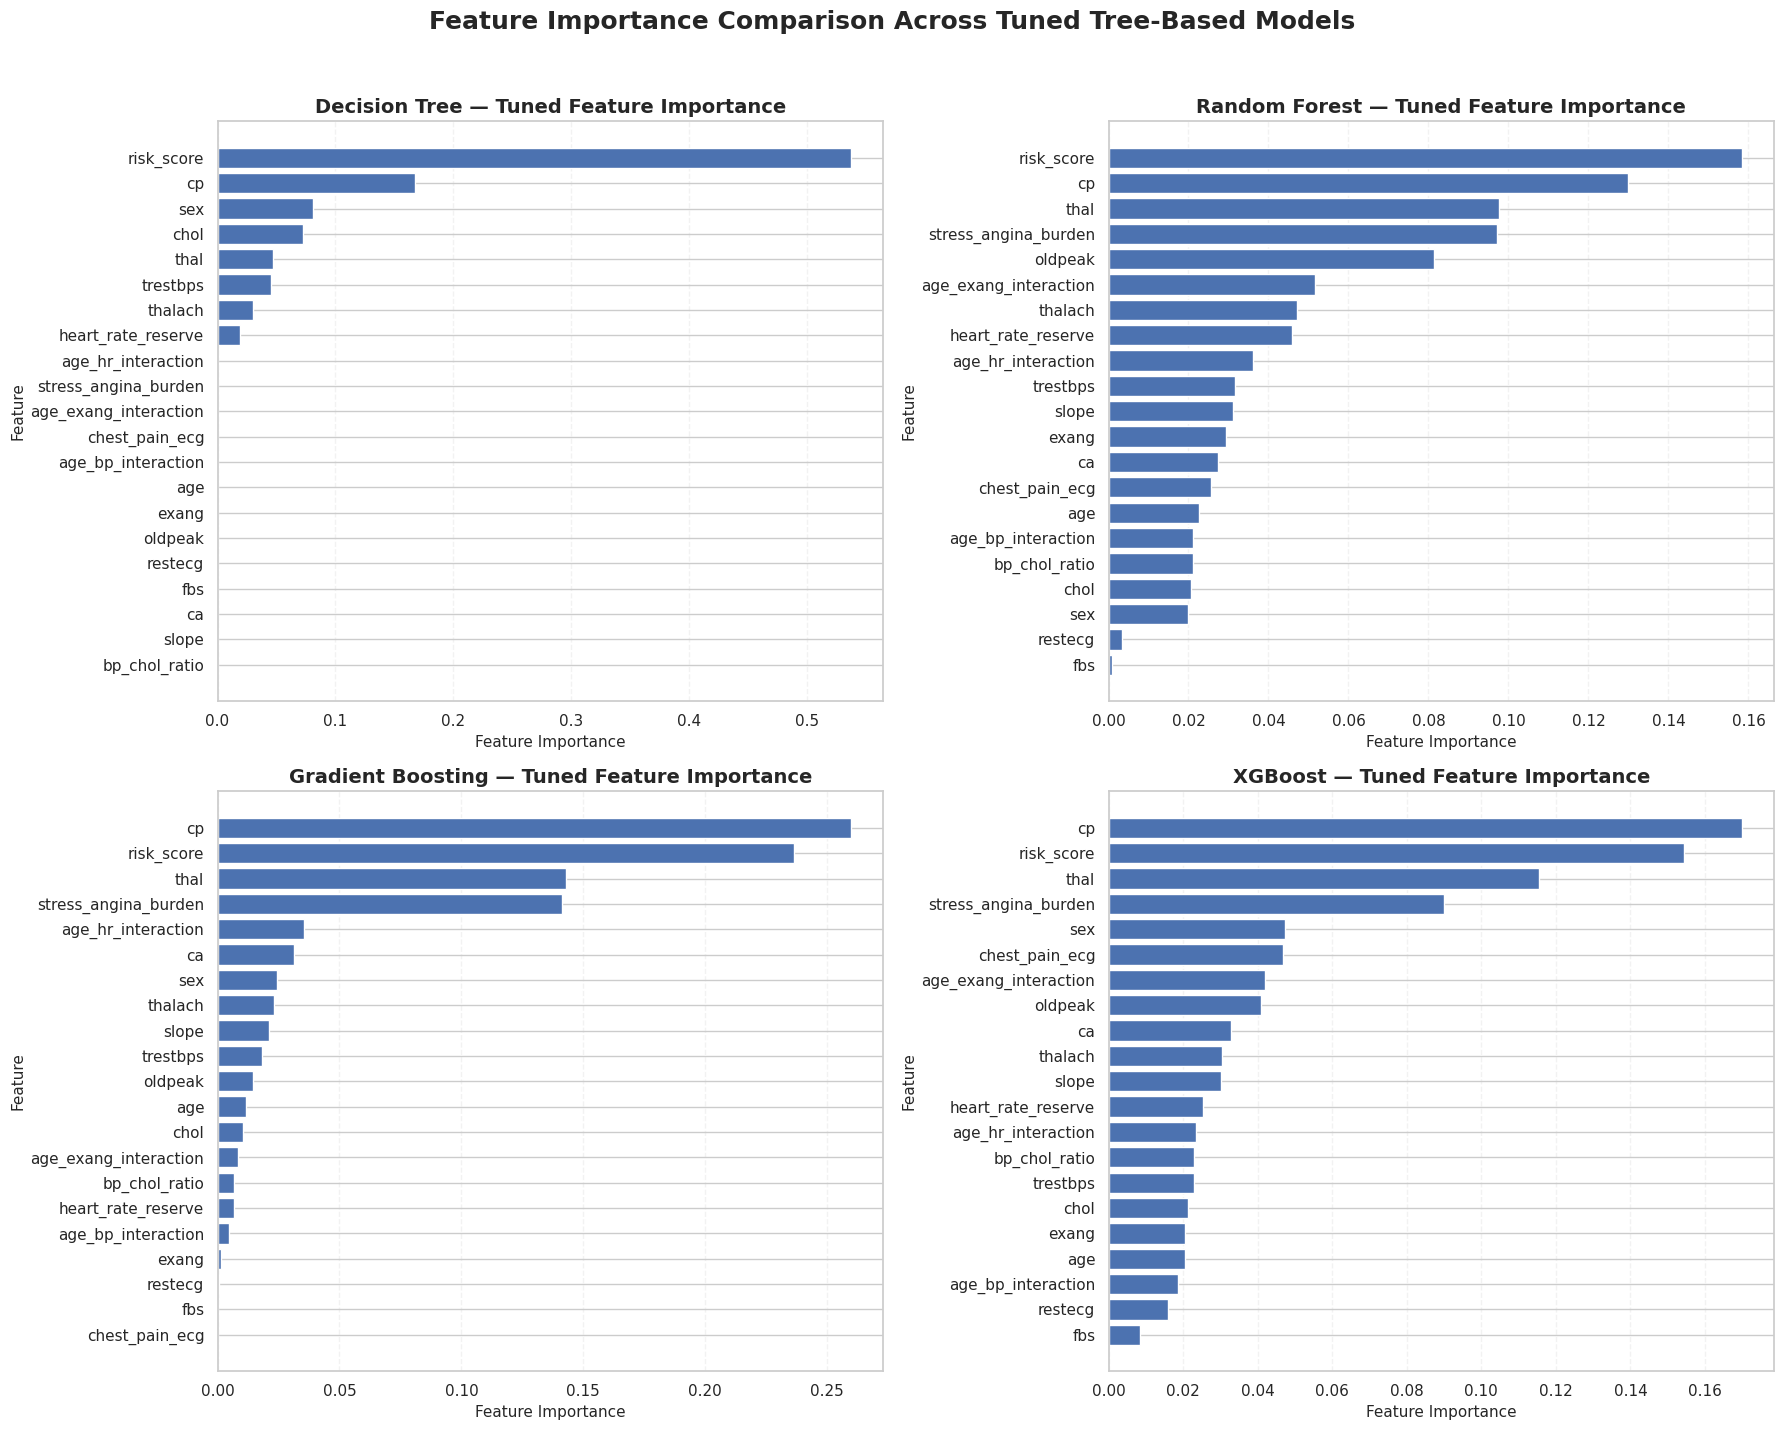

In [74]:
# ============================================================
# 13.2 Feature Importance Comparison — 2×2 Grid
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 14)
)

axes = axes.flatten()

for ax, (model_name, importance_series) in zip(
    axes,
    feature_importance_dict.items()
):

    plot_data = importance_series.sort_values(ascending=True)

    ax.barh(
        plot_data.index,
        plot_data.values
    )

    ax.set_title(
        f"{model_name} — Tuned Feature Importance",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Feature Importance",
        fontsize=11
    )

    ax.set_ylabel(
        "Feature",
        fontsize=11
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

fig.suptitle(
    "Feature Importance Comparison Across Tuned Tree-Based Models",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Observation

The feature-importance comparison shows that the four tuned models identify a broadly consistent group of high-value predictors, although the relative ranking differs across algorithms.

The most prominent features across the models are **`risk_score`**, **`cp`**, **`thal`**, and **`stress_angina_burden`**. `risk_score` is the dominant feature for the tuned Decision Tree and Random Forest, while `cp` receives the highest importance in both Gradient Boosting and XGBoost.

The ensemble models also assign meaningful importance to several additional clinical and engineered variables, including `oldpeak`, `age_exang_interaction`, `thalach`, `ca`, and `sex`. In contrast, the tuned Decision Tree concentrates much more of its total importance on a smaller number of predictors.

This difference indicates that the models do not rely on exactly the same predictive structure. The Decision Tree concentrates information through a limited sequence of splits, whereas Random Forest, Gradient Boosting, and XGBoost distribute predictive contribution across multiple trees and can capture more complex interactions among variables.

Overall, the visualization demonstrates substantial agreement on the strongest predictors while also revealing model-specific differences in how predictive information is distributed.

### 13.3 Cross-Model Feature Ranking

To complement the 2×2 visualization, the highest-ranked predictors from each tuned model are summarized below.

This comparison helps distinguish between:

- **Consistent predictors**, which remain highly ranked across several models.
- **Model-dependent predictors**, whose importance changes substantially depending on the learning strategy.

Consistency across multiple models provides stronger exploratory evidence that a predictor contains useful information for distinguishing the two target classes. Differences in ranking, however, are expected because the models can represent nonlinear relationships and feature interactions in different ways.

In [75]:
# ============================================================
# 13.3 Top Feature Ranking Across Tuned Models
# ============================================================

TOP_N_FEATURES = 10

top_features_df = pd.DataFrame({
    model_name: importance_series.head(TOP_N_FEATURES).index
    for model_name, importance_series
    in feature_importance_dict.items()
})

print(f"Top {TOP_N_FEATURES} features identified by each tuned model:")

display(top_features_df)

Top 10 features identified by each tuned model:


,Decision Tree,Random Forest,Gradient Boosting,XGBoost
0,risk_score,risk_score,cp,cp
1,cp,cp,risk_score,risk_score
2,sex,thal,thal,thal
3,chol,stress_angina_burden,stress_angina_burden,stress_angina_burden
4,thal,oldpeak,age_hr_interaction,sex
5,trestbps,age_exang_interaction,ca,chest_pain_ecg
6,thalach,thalach,sex,age_exang_interaction
7,heart_rate_reserve,heart_rate_reserve,thalach,oldpeak
8,age,age_hr_interaction,slope,ca
9,exang,trestbps,trestbps,thalach


### 13.4 Final Interpretation — Feature Importance Comparison

The feature-importance analysis provides a coherent cross-model assessment of the predictors used by the tuned classification models.

There is clear agreement that **`cp`**, **`risk_score`**, **`thal`**, and **`stress_angina_burden`** are among the most influential predictors. This agreement across different tree-based algorithms strengthens confidence that these variables contain substantial predictive information for distinguishing the target classes.

At the same time, the models do not produce identical rankings. The Decision Tree places exceptionally high importance on `risk_score`, while Gradient Boosting and XGBoost place greater emphasis on `cp`. Random Forest distributes importance more broadly across several clinical and engineered variables. These differences are expected because each algorithm constructs its decision structure differently.

The results therefore support two conclusions: first, the leading predictors are reasonably stable across models; and second, the models capture complementary aspects of the relationships within the dataset.

It is important to interpret feature importance as **model-based predictive contribution rather than causal or independent clinical importance**. In particular, `risk_score` is an engineered feature, so its high importance reflects the predictive information contained in its construction.

Overall, the feature-importance results are internally consistent with the earlier modeling results and provide a strong foundation for interpreting the decision structure of the best-performing tree-based models.

## 14. Decision Tree Visualization

The tuned Decision Tree is visualized to provide a direct and interpretable representation of the model's learned decision structure.

The complete tuned tree may contain multiple levels and branches, which can make the full structure difficult to interpret visually. Therefore, only the first four levels are displayed using `max_depth=4`, as specified in the project requirements.

This depth restriction applies **only to the visualization**. It does not modify, retrain, or replace the tuned Decision Tree.

The visualization allows the highest-level decision rules to be examined directly, while the first few splits provide insight into which predictors the model uses at the beginning of its classification process.

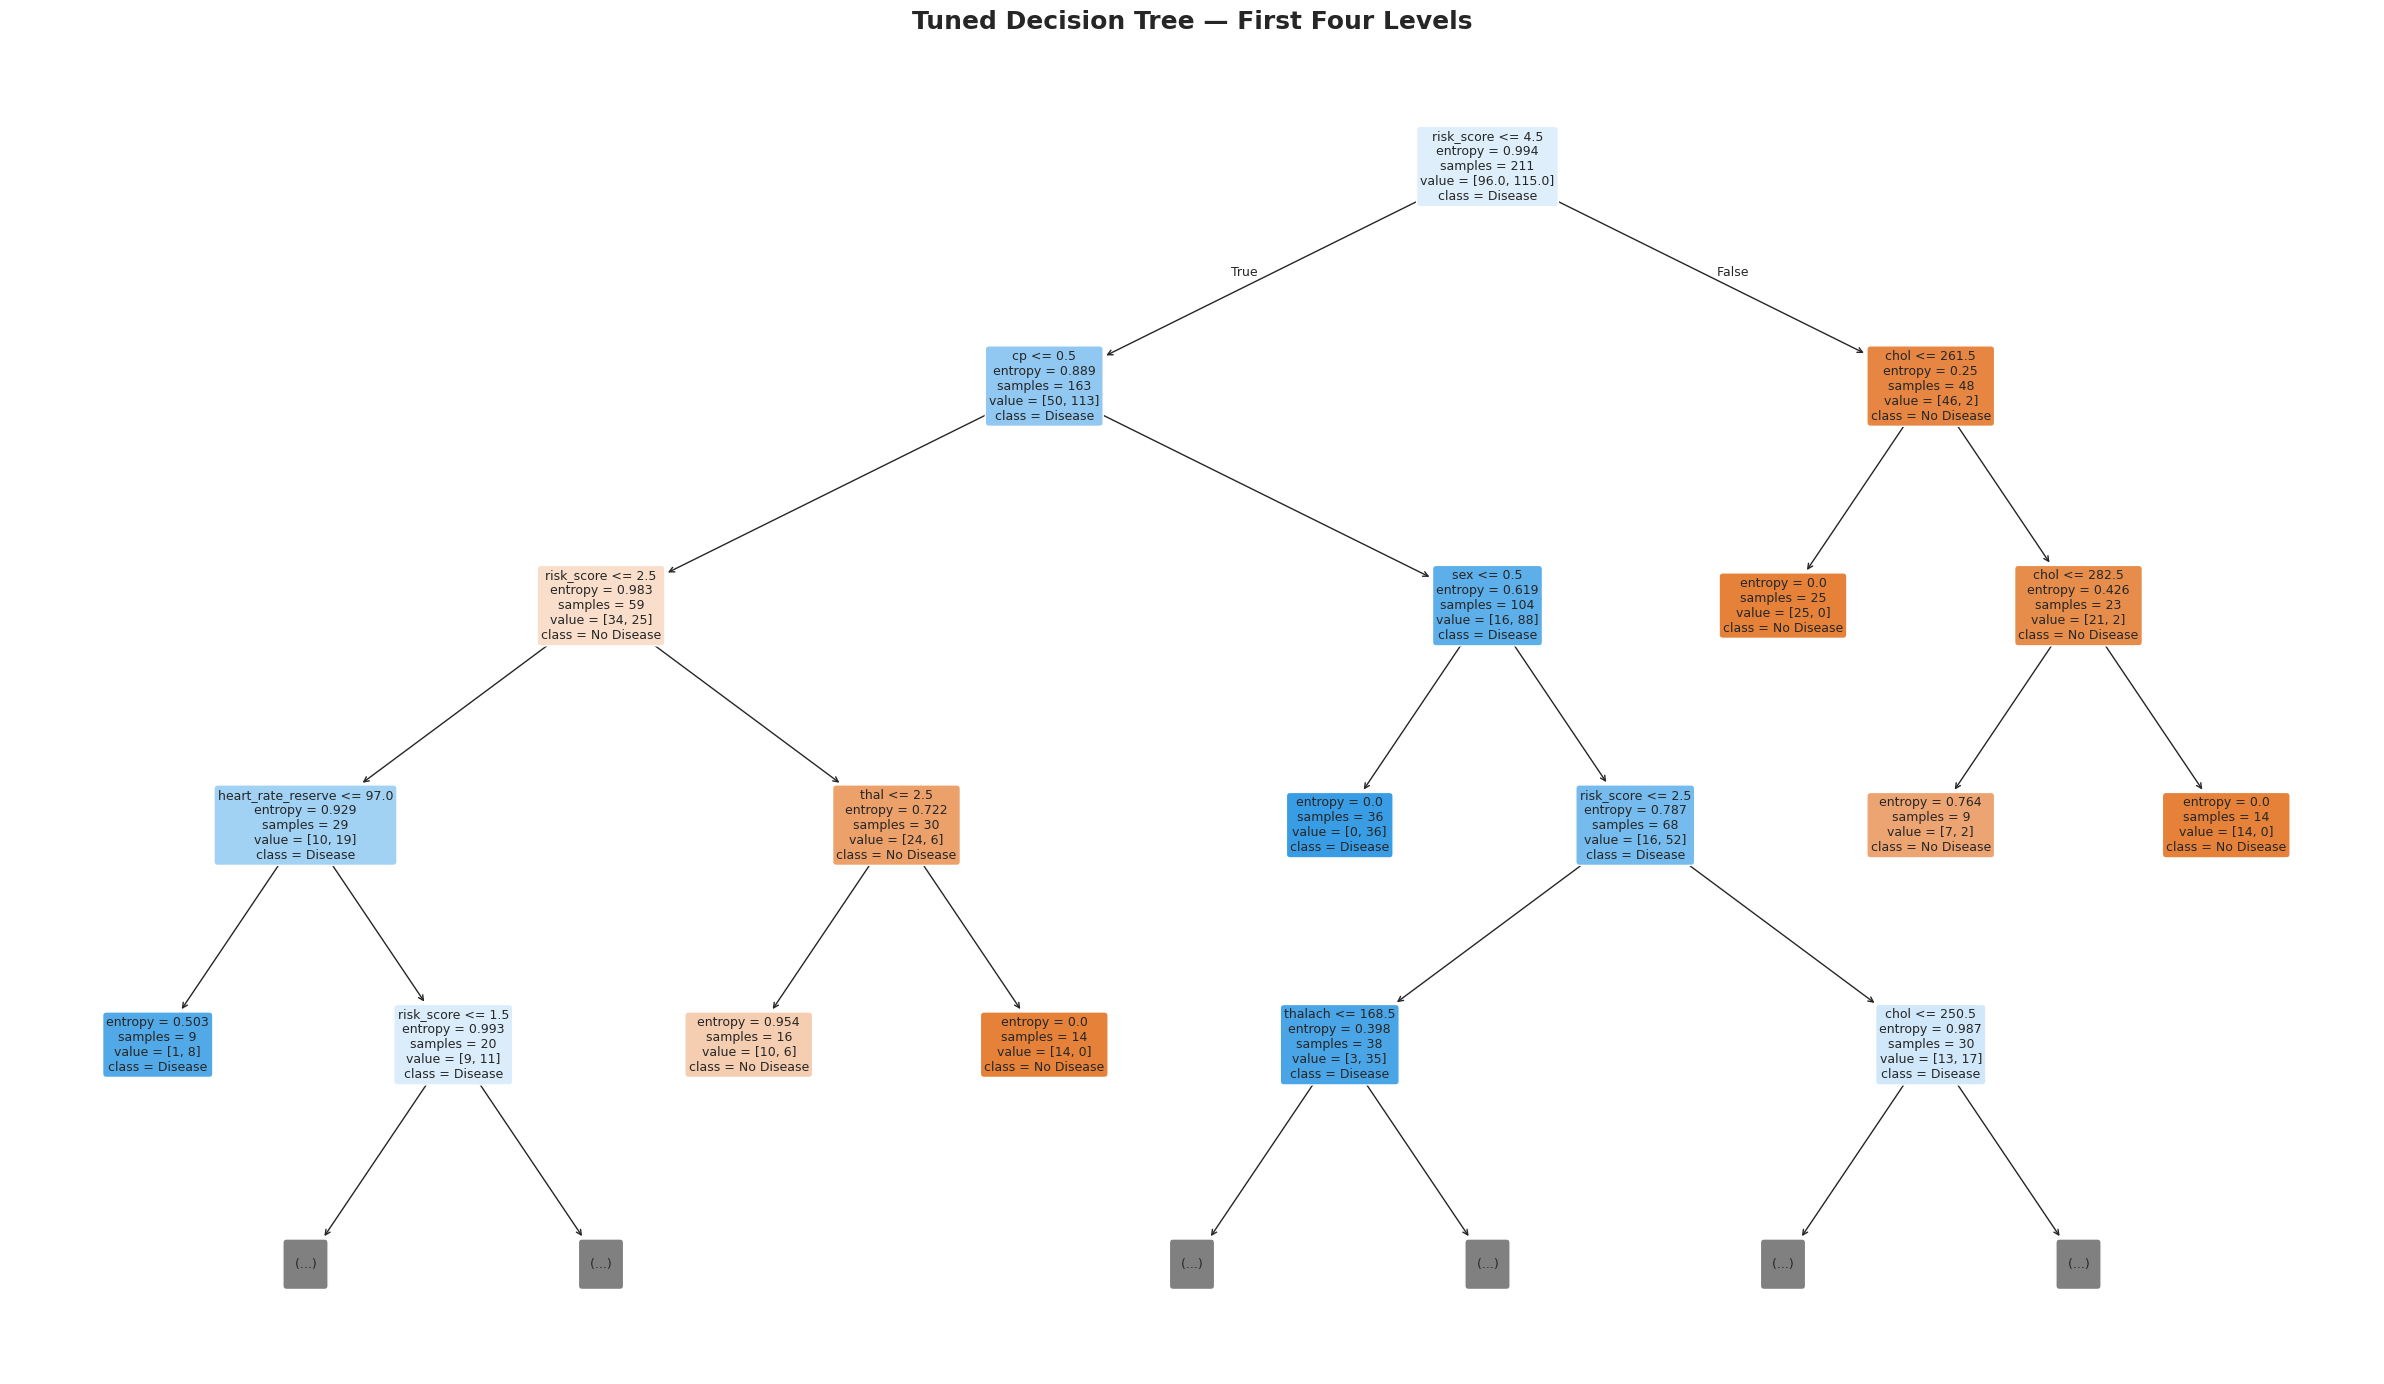

In [76]:
# ============================================================
# 14.1 Tuned Decision Tree Visualization
# ============================================================

from sklearn.tree import plot_tree

# Retrieve the already-tuned Decision Tree
best_decision_tree = tuned_models["Decision Tree"]

plt.figure(figsize=(24, 14))

plot_tree(
    best_decision_tree,
    feature_names=X_train.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)

plt.title(
    "Tuned Decision Tree — First Four Levels",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

### Observation

The tuned Decision Tree begins with **`risk_score`**, using a threshold of approximately **4.5** as the first split. This indicates that the engineered risk profile provides the strongest initial partition of the observations within the fitted tree.

The next major split occurs on **`cp`**, with a threshold of approximately **0.5** on the lower `risk_score` branch. This further separates observations according to chest pain characteristics.

On the alternative branch, the tree introduces **`chol`** at approximately **261.5**, indicating that cholesterol provides additional discriminatory information within that subgroup.

The subsequent branches introduce additional predictors such as `sex`, `thal`, `heart_rate_reserve`, and `thalach`, illustrating how the tree progressively refines the classification decision.

The first few splits therefore provide an interpretable representation of how the tuned Decision Tree combines the engineered risk profile with established clinical predictors to distinguish between the two target classes.

### 14.2 First Three Decision Splits

The first three internal splits of the tuned Decision Tree are extracted directly from the fitted model.

Examining these splits provides a more precise interpretation of the tree's initial decision-making process by identifying:

- The feature selected at each split.
- The learned threshold.
- The hierarchical position of the split.

These thresholds are model-derived decision boundaries rather than clinical diagnostic thresholds. They should therefore be interpreted as predictive rules learned from the present dataset.

In [77]:
# ============================================================
# 14.2 Extract First Three Internal Splits
# ============================================================

tree_model = best_decision_tree.tree_

children_left = tree_model.children_left
children_right = tree_model.children_right
tree_features = tree_model.feature
tree_thresholds = tree_model.threshold

# ------------------------------------------------------------
# Calculate depth of every node
# ------------------------------------------------------------

node_depth = np.zeros(tree_model.node_count, dtype=int)

stack = [(0, 0)]

while stack:

    node_id, depth = stack.pop()

    node_depth[node_id] = depth

    left_child = children_left[node_id]
    right_child = children_right[node_id]

    if left_child != -1:
        stack.append((left_child, depth + 1))

    if right_child != -1:
        stack.append((right_child, depth + 1))

# ------------------------------------------------------------
# Collect internal split nodes
# ------------------------------------------------------------

split_information = []

for node_id in range(tree_model.node_count):

    # -2 indicates a leaf node
    if tree_features[node_id] != -2:

        split_information.append({
            "Node": node_id,
            "Depth": node_depth[node_id],
            "Feature": X_train.columns[tree_features[node_id]],
            "Threshold": tree_thresholds[node_id]
        })

first_three_splits = (
    pd.DataFrame(split_information)
    .sort_values(["Depth", "Node"])
    .head(3)
    .reset_index(drop=True)
)

print("First three internal Decision Tree splits:")

display(
    first_three_splits.round(3)
)

First three internal Decision Tree splits:


,Node,Depth,Feature,Threshold
0,0,0,risk_score,4.500
1,1,1,cp,0.500
2,22,1,chol,261.500


### 14.3 Interpretation of the First Three Splits

The first three splits provide a concise view of how the tuned Decision Tree begins separating patients into the two target classes.

The interpretation focuses on the model's learned structure rather than treating the thresholds as clinical diagnostic boundaries.

**First split:**  
The root node represents the first and most influential decision in the displayed tree. The selected feature and threshold indicate the variable that provided the greatest impurity reduction at the root of the fitted tree.

**Second split:**  
The second-level decision further separates observations within the relevant branch according to another learned feature threshold. This demonstrates how the tree combines multiple predictors sequentially rather than relying on a single clinical variable.

**Third split:**  
The third split provides an additional refinement of the classification structure, producing increasingly homogeneous groups with respect to the target variable.

Together, these early splits demonstrate the main advantage of a Decision Tree in terms of interpretability: the model's predictions can be represented as a sequence of understandable threshold-based decisions.

However, these rules should not be interpreted as independent medical guidelines. They are data-driven patterns learned from this specific sample and should be considered alongside model validation results and established clinical knowledge.

### 14.4 Final Interpretation — Decision Tree Structure

The Decision Tree visualization provides a transparent view of the hierarchical decision process learned by the tuned model.

The first three important splitting variables — **`risk_score`**, **`cp`**, and **`chol`** — are consistent with the feature-importance analysis presented in the previous section. In particular, `risk_score` and `cp` were among the strongest predictors across multiple tuned models, providing an important consistency check between the model's global feature importance and its actual decision structure.

The tree also demonstrates that predictive information is not based on a single variable. After the initial partitions, additional clinical and engineered features are used to refine the classification of increasingly specific subgroups.

Using only the first four levels provides a readable representation of the model without displaying the full tree, which would become difficult to interpret because of the number of observations and predictors.

Overall, the Decision Tree structure is **consistent with the feature-importance results and the previous model evaluation**, while providing an interpretable explanation of how individual predictor thresholds contribute to the final classification. The visualization should therefore be considered an interpretability tool rather than evidence of causal relationships between the predictors and heart disease.

## 15. XGBoost Learning Curves and Early Stopping

This section examines the training dynamics of the tuned XGBoost model across boosting rounds.

The training and validation log-loss values will be tracked at each boosting iteration to determine whether the model continues to improve on unseen validation data or begins to overfit.

The analysis will focus on three aspects:

- The progression of training and validation log-loss across boosting rounds.
- The point at which validation performance stops improving and begins to deteriorate.
- The effect of early stopping in preventing unnecessary boosting iterations and limiting overfitting.

A validation subset will be created from the training data only. The independent test set will remain untouched during this analysis so that it can continue to provide an unbiased final evaluation of the model.

Best boosting iteration: 58
Minimum validation log-loss: 0.4543
Total boosting rounds fitted: 78


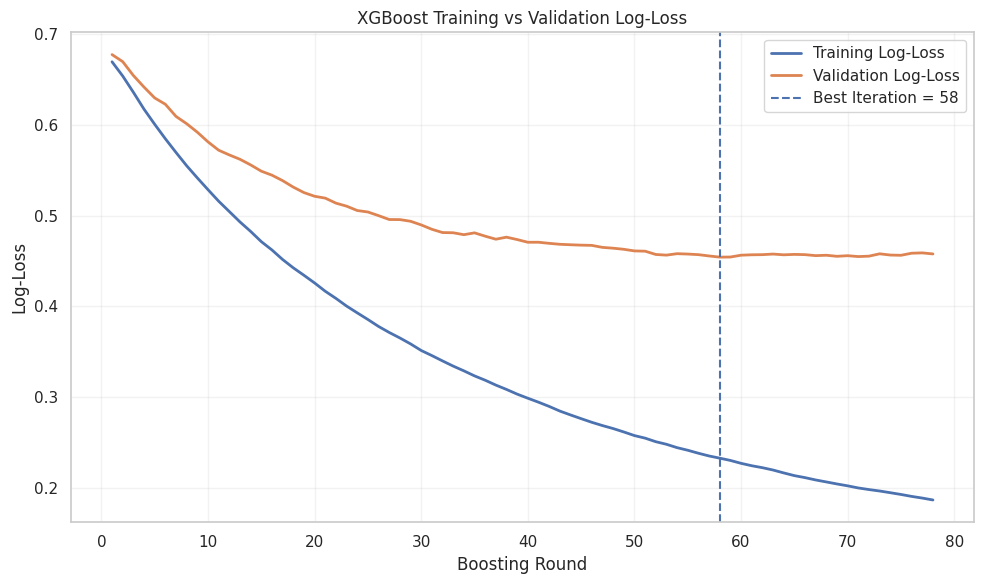

In [78]:
# ============================================================
# 15.1 XGBoost Learning Curve with Early Stopping
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# ------------------------------------------------------------
# Create an internal validation set from the training data
# ------------------------------------------------------------
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

# ------------------------------------------------------------
# Best parameters obtained from Section 12
# ------------------------------------------------------------
xgb_best_params = {
    "colsample_bytree": 0.8244973703390804,
    "learning_rate": 0.036781499095023595,
    "max_depth": 8,
    "n_estimators": 180,
    "reg_alpha": 0.6366859160799433,
    "reg_lambda": 0.4828715216179211,
    "subsample": 0.9083868719818244
}

# ------------------------------------------------------------
# Train XGBoost with early stopping
# ------------------------------------------------------------
xgb_learning_model = XGBClassifier(
    **xgb_best_params,
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=42
)

xgb_learning_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb),
              (X_val_xgb, y_val_xgb)],
    verbose=False
)

# ------------------------------------------------------------
# Extract evaluation history
# ------------------------------------------------------------
eval_results = xgb_learning_model.evals_result()

train_logloss = eval_results["validation_0"]["logloss"]
val_logloss = eval_results["validation_1"]["logloss"]

best_iteration = xgb_learning_model.best_iteration + 1
best_val_logloss = min(val_logloss)

print(f"Best boosting iteration: {best_iteration}")
print(f"Minimum validation log-loss: {best_val_logloss:.4f}")
print(f"Total boosting rounds fitted: {len(train_logloss)}")

# ------------------------------------------------------------
# Plot training vs validation log-loss
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_logloss) + 1),
    train_logloss,
    label="Training Log-Loss",
    linewidth=2
)

plt.plot(
    range(1, len(val_logloss) + 1),
    val_logloss,
    label="Validation Log-Loss",
    linewidth=2
)

plt.axvline(
    best_iteration,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Iteration = {best_iteration}"
)

plt.xlabel("Boosting Round")
plt.ylabel("Log-Loss")
plt.title("XGBoost Training vs Validation Log-Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Observation

The learning curve illustrates the training and validation log-loss of the XGBoost model across 78 boosting rounds.

The **training log-loss (blue curve)** shows a steady and continuous decline, decreasing from approximately **0.67** initially to around **0.19** by round 78. This indicates that the model continues to learn and fit the training data as additional boosting rounds are introduced.

The **validation log-loss (orange curve)** also decreases rapidly during the early boosting rounds, indicating that the added trees initially improve the model’s ability to generalize to unseen validation data. The validation loss reaches its **minimum at approximately boosting iteration 58**, after which it largely plateaus with only minor fluctuations. This suggests that further boosting rounds provide limited additional generalization benefit, while the training loss continues to decrease.

The vertical dashed line indicates the **Best Iteration = 58**, representing the point at which the validation performance is optimal. Beyond this point, the continued reduction in training loss is not accompanied by meaningful improvement in validation loss, indicating a growing gap between training and validation performance. However, there is **no severe upward divergence in validation loss**, suggesting that substantial overfitting has not occurred.

The **early-stopping mechanism** therefore identifies the best iteration based on validation performance and prevents the model from unnecessarily adding further trees once meaningful improvement has stopped. Overall, the learning curves indicate effective model learning and a reasonable balance between training fit and generalization, with **iteration 58 providing the optimal stopping point**.


### 15.2 Final Insight — XGBoost Generalization and Early Stopping

The learning-curve analysis provides a clear assessment of how the tuned XGBoost model learns as the number of boosting rounds increases and identifies the point at which additional model complexity provides limited generalization benefit.

The results demonstrate that model complexity should not be evaluated solely based on the continuous reduction in training log-loss. While the training loss continues to decrease as more trees are added, the **validation log-loss reaches its minimum at the best iteration (58)** and subsequently remains relatively stable with only minor fluctuations. This indicates that additional boosting rounds improve the fit to the training data without providing meaningful improvement on unseen validation data.

Therefore, **early stopping serves as an important regularization mechanism** in this analysis. By monitoring validation performance and selecting the iteration with the lowest validation loss, it prevents the model from unnecessarily increasing its complexity after generalization performance has stopped improving.

Overall, the learning curve provides evidence that the tuned XGBoost model achieves a **reasonable balance between learning the training patterns and maintaining generalization performance**. The early-stopping procedure complements the previously performed hyperparameter tuning by controlling the effective number of boosting rounds and providing an additional safeguard against unnecessary overfitting.


### 15.X Final Insight — XGBoost Generalization and Early Stopping

The learning-curve analysis provides a clear assessment of how the tuned XGBoost model learns as the number of boosting rounds increases and identifies the point at which additional model complexity provides limited generalization benefit.

The results demonstrate that model complexity should not be evaluated solely based on the continuous reduction in training log-loss. While the training loss continues to decrease as more trees are added, the **validation log-loss reaches its minimum at the best iteration (58)** and subsequently remains relatively stable with only minor fluctuations. This indicates that additional boosting rounds improve the fit to the training data without providing meaningful improvement on unseen validation data.

Therefore, **early stopping serves as an important regularization mechanism** in this analysis. By monitoring validation performance and selecting the iteration with the lowest validation loss, it prevents the model from unnecessarily increasing its complexity after generalization performance has stopped improving.

Overall, the learning curve provides evidence that the tuned XGBoost model achieves a **reasonable balance between learning the training patterns and maintaining generalization performance**. The early-stopping procedure complements the previously performed hyperparameter tuning by controlling the effective number of boosting rounds and providing an additional safeguard against unnecessary overfitting.


Best test accuracy occurs at max_depth = 5
Best test accuracy = 0.780
No clear overfitting point was identified using the specified criterion.


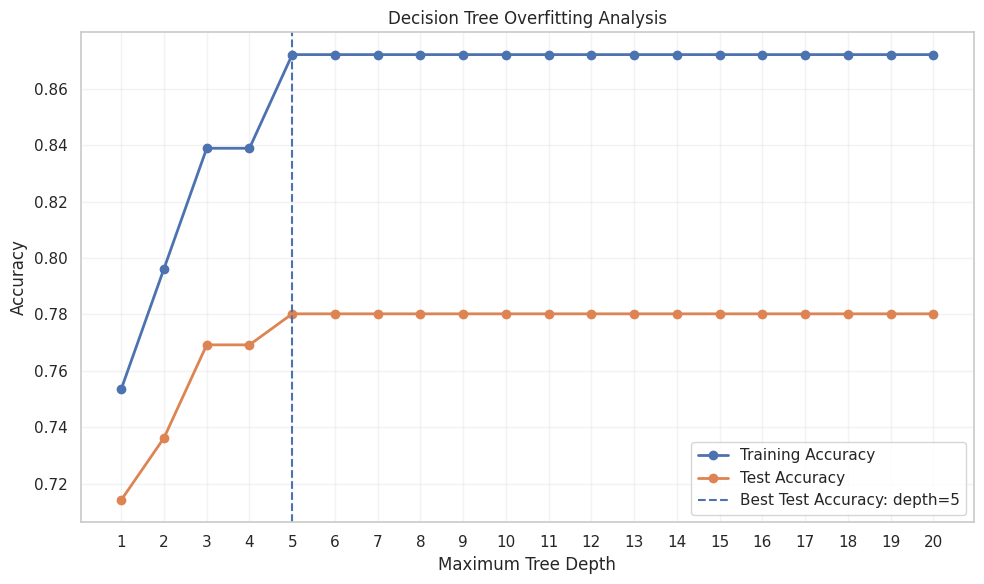

In [79]:
# ============================================================
# 16.1 Decision Tree Overfitting Analysis
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depth_values = range(1, 21)

dt_train_accuracy = []
dt_test_accuracy = []

# Tuned Decision Tree parameters from Section 12
dt_fixed_params = {
    "criterion": "entropy",
    "max_features": None,
    "min_samples_leaf": 9,
    "min_samples_split": 18,
    "random_state": 42
}

for depth in depth_values:

    dt_model = DecisionTreeClassifier(
        **dt_fixed_params,
        max_depth=depth
    )

    dt_model.fit(X_train, y_train)

    train_pred = dt_model.predict(X_train)
    test_pred = dt_model.predict(X_test)

    dt_train_accuracy.append(
        accuracy_score(y_train, train_pred)
    )

    dt_test_accuracy.append(
        accuracy_score(y_test, test_pred)
    )

# ------------------------------------------------------------
# Identify the best test-accuracy depth
# ------------------------------------------------------------
best_dt_index = np.argmax(dt_test_accuracy)
best_dt_depth = list(depth_values)[best_dt_index]
best_dt_test_accuracy = dt_test_accuracy[best_dt_index]

# ------------------------------------------------------------
# Identify the first depth after the best point where
# training accuracy increases while test accuracy decreases
# ------------------------------------------------------------
dt_overfit_depth = None

for i in range(best_dt_index + 1, len(depth_values)):
    if (
        dt_train_accuracy[i] > dt_train_accuracy[i - 1]
        and dt_test_accuracy[i] < dt_test_accuracy[i - 1]
    ):
        dt_overfit_depth = depth_values[i]
        break

print(f"Best test accuracy occurs at max_depth = {best_dt_depth}")
print(f"Best test accuracy = {best_dt_test_accuracy:.3f}")

if dt_overfit_depth is not None:
    print(
        f"First clear overfitting point identified at "
        f"max_depth = {dt_overfit_depth}"
    )
else:
    print(
        "No clear overfitting point was identified using the "
        "specified criterion."
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    depth_values,
    dt_train_accuracy,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    depth_values,
    dt_test_accuracy,
    marker="o",
    linewidth=2,
    label="Test Accuracy"
)

plt.axvline(
    best_dt_depth,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Test Accuracy: depth={best_dt_depth}"
)

if dt_overfit_depth is not None:
    plt.axvline(
        dt_overfit_depth,
        linestyle=":",
        linewidth=2,
        label=f"Overfitting Starts: depth={dt_overfit_depth}"
    )

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting Analysis")
plt.xticks(list(depth_values))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Observation — Decision Tree Overfitting Analysis

The line plot illustrates the effect of increasing **Decision Tree `max_depth` from 1 to 20** on both training and test accuracy, providing a direct assessment of model complexity and generalization.

At lower depths, both training and test accuracy increase as the tree gains sufficient capacity to capture more meaningful patterns in the data. **Training accuracy rises from approximately 0.753 at depth 1 to 0.871 at depth 5**, while **test accuracy increases from 0.714 to its maximum of 0.780** over the same range. This indicates that increasing the tree depth initially improves both the model's ability to fit the training data and its performance on unseen observations.

The **best generalization performance is achieved at `max_depth = 5`**, where the test accuracy reaches its highest value of **0.780**. Beyond depth 5, both training and test accuracy remain essentially unchanged, with no further improvement from increasing the tree's complexity. Therefore, deeper trees do not provide additional predictive benefit in this analysis.

Importantly, the plot does **not show the typical severe overfitting pattern**, where training accuracy continues to increase while test accuracy declines. Instead, the test accuracy plateaus after depth 5, suggesting that additional tree depth adds unnecessary complexity without improving generalization.

Overall, **`max_depth = 5` represents the most appropriate complexity level** for this Decision Tree, achieving the highest observed test accuracy while avoiding unnecessary model expansion. This highlights why the optimal hyperparameter should be selected based on **generalization performance rather than training accuracy alone**.


Best test accuracy occurs at n_estimators = 90
Best test accuracy = 0.813
First clear overfitting point identified at n_estimators = 150


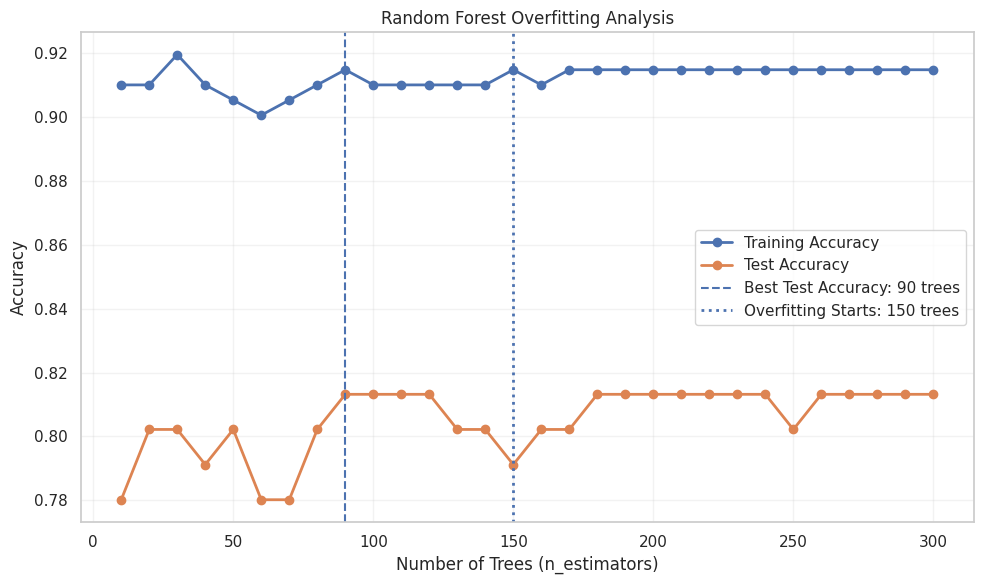

In [80]:
# ============================================================
# 16.2 Random Forest Overfitting Analysis
# ============================================================

from sklearn.ensemble import RandomForestClassifier

n_estimators_values = range(10, 301, 10)

rf_train_accuracy = []
rf_test_accuracy = []

# Tuned Random Forest parameters from Section 12
rf_fixed_params = {
    "max_depth": None,
    "min_samples_split": 15,
    "max_features": "log2",
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": -1
}

for n_trees in n_estimators_values:

    rf_model = RandomForestClassifier(
        **rf_fixed_params,
        n_estimators=n_trees
    )

    rf_model.fit(X_train, y_train)

    train_pred = rf_model.predict(X_train)
    test_pred = rf_model.predict(X_test)

    rf_train_accuracy.append(
        accuracy_score(y_train, train_pred)
    )

    rf_test_accuracy.append(
        accuracy_score(y_test, test_pred)
    )

# ------------------------------------------------------------
# Identify best test accuracy
# ------------------------------------------------------------
best_rf_index = np.argmax(rf_test_accuracy)
best_rf_n_estimators = list(n_estimators_values)[best_rf_index]
best_rf_test_accuracy = rf_test_accuracy[best_rf_index]

# ------------------------------------------------------------
# Identify first clear overfitting point:
# training accuracy increases while test accuracy decreases
# ------------------------------------------------------------
rf_overfit_n = None

for i in range(best_rf_index + 1, len(n_estimators_values)):
    if (
        rf_train_accuracy[i] > rf_train_accuracy[i - 1]
        and rf_test_accuracy[i] < rf_test_accuracy[i - 1]
    ):
        rf_overfit_n = n_estimators_values[i]
        break

print(f"Best test accuracy occurs at n_estimators = {best_rf_n_estimators}")
print(f"Best test accuracy = {best_rf_test_accuracy:.3f}")

if rf_overfit_n is not None:
    print(
        f"First clear overfitting point identified at "
        f"n_estimators = {rf_overfit_n}"
    )
else:
    print(
        "No clear overfitting point was identified using the "
        "specified criterion."
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    n_estimators_values,
    rf_train_accuracy,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    n_estimators_values,
    rf_test_accuracy,
    marker="o",
    linewidth=2,
    label="Test Accuracy"
)

plt.axvline(
    best_rf_n_estimators,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Test Accuracy: {best_rf_n_estimators} trees"
)

if rf_overfit_n is not None:
    plt.axvline(
        rf_overfit_n,
        linestyle=":",
        linewidth=2,
        label=f"Overfitting Starts: {rf_overfit_n} trees"
    )

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Overfitting Analysis")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Observation — Random Forest Overfitting Analysis

The line plot illustrates the effect of increasing the **Random Forest `n_estimators` from 10 to 300 trees** on training and test accuracy, providing an assessment of how ensemble size influences model stability and generalization.

The **training accuracy** fluctuates within approximately **0.90–0.92**, reaching an early peak around **30 trees** before gradually stabilizing near **0.915** from approximately 180 trees onward. This indicates that the model achieves a strong fit with a relatively small number of trees, while adding more estimators produces only limited changes in training performance.

The **test accuracy** varies between approximately **0.78 and 0.813** across the evaluated range. Although performance fluctuates at lower tree counts, it reaches its **highest observed value at 90 trees**, which is therefore identified as the best configuration in this diagnostic analysis. Beyond this point, additional trees do not provide a consistent improvement in generalization performance.

The plot also identifies **150 trees as the point where overfitting begins according to the defined diagnostic criterion**, marked by the dotted vertical line. Around this region, test accuracy experiences a decline while training performance remains comparatively high, creating an increasing generalization gap. However, the subsequent stabilization of test accuracy suggests that the effect is limited rather than representing severe or continuously worsening overfitting.

Overall, **`n_estimators = 90` provides the best observed generalization performance**, achieving the highest test accuracy while avoiding unnecessary expansion of the ensemble. The results also demonstrate an important characteristic of Random Forests: increasing the number of trees generally improves prediction stability and eventually produces **diminishing returns**, rather than causing the rapid overfitting typically associated with increasing the depth of a single Decision Tree.


### 16.3 Final Insight — Overfitting and Model Complexity

The overfitting analysis demonstrates that **model complexity should be controlled based on generalization performance rather than training performance alone**.

For the **Decision Tree**, increasing `max_depth` increases the model’s flexibility and allows it to capture increasingly specific patterns in the training data. In this analysis, both training and test accuracy improve up to **depth 5**, where the model achieves its highest test accuracy of **0.780**. Beyond this point, test performance remains stable while additional complexity provides no meaningful benefit. This indicates that **`max_depth = 5` represents an appropriate complexity level**, avoiding unnecessary expansion without sacrificing generalization.

For the **Random Forest**, increasing `n_estimators` has a different effect because the model aggregates predictions from multiple trees. The ensemble becomes increasingly stable as more trees are added, and the benefit of additional estimators gradually diminishes. In this analysis, the highest test accuracy is achieved at **90 trees**, while the diagnostic criterion identifies **150 trees** as the point where signs of an increasing generalization gap begin to appear. This highlights that adding more trees does not necessarily lead to better predictive performance once the ensemble has reached sufficient stability.

Overall, these results reinforce the importance of selecting model complexity according to **unseen-data performance and generalization stability**, rather than maximizing training accuracy. The Decision Tree benefits from controlling its depth, while the Random Forest primarily benefits from reaching a sufficient ensemble size without unnecessarily increasing it.

These findings complement the earlier **cross-validation and hyperparameter-tuning results**, providing an additional diagnostic perspective on how model complexity influences generalization and why appropriately constrained configurations can perform more reliably than unnecessarily complex alternatives.


# 17. Written Analysis — Model Performance, Comparison, and Practical Interpretation

The complete modeling workflow provides a useful comparison between a single Decision Tree and three ensemble-based approaches: Random Forest, Gradient Boosting, and XGBoost. The analysis was performed using a relatively small dataset containing 302 observations after duplicate removal, with the same held-out test set used to compare the baseline and tuned models. Because this is a healthcare classification problem, performance should not be judged using accuracy alone. In particular, recall is highly relevant because a false negative corresponds to a patient with heart disease being classified as low risk. ROC-AUC and F1-score were therefore also considered when interpreting the final models.

## a) Which model performed best and why?

Based on the overall test-set results, the **tuned Random Forest is the strongest overall model for this dataset**. It achieved a test accuracy of **0.813**, precision of **0.758**, recall of **0.959**, F1-score of **0.847**, and ROC-AUC of **0.880**. The particularly high recall is important in the context of heart disease prediction because the objective is not simply to classify observations correctly, but also to minimize the number of patients with disease who are incorrectly classified as not having the disease.

It is important, however, to distinguish between the different evaluation metrics. **Gradient Boosting achieved the highest test ROC-AUC at 0.882**, compared with 0.880 for Random Forest. This is only a 0.002 difference and therefore does not represent a meaningful overall advantage based on the available results. Random Forest performed better in accuracy, recall, and F1-score. Consequently, Random Forest provides the more balanced performance profile for the particular objective of this project.

The result is also consistent with the bias-variance tradeoff. A single Decision Tree can model nonlinear relationships and interactions, but it is highly sensitive to the training sample. This is especially relevant here because the dataset contains only 302 observations. With a relatively small dataset, small changes in the observations used for training can lead to substantially different tree structures. This contributes to higher variance and can limit generalization.

Random Forest reduces this problem through ensemble learning. Instead of relying on one tree, it constructs many trees using different bootstrap samples and subsets of features, then aggregates their predictions. Individual trees can therefore make different errors, while the ensemble reduces the effect of those errors. This variance-reduction mechanism is particularly suitable for a small tabular dataset containing both categorical clinical variables and continuous measurements.

The dataset also contains engineered variables and interaction terms, which may contain nonlinear relationships with the target. Tree-based ensembles can capture these relationships without requiring linearity assumptions or extensive mathematical transformations. The stronger performance of Random Forest compared with the individual Decision Tree therefore makes both statistical and practical sense.

## b) Why might Decision Tree perform differently from Random Forest on this specific dataset?

The performance difference between the single Decision Tree and Random Forest is substantial. The baseline Decision Tree achieved a test accuracy of **0.725** and ROC-AUC of **0.725**, while the tuned Random Forest achieved **0.813** accuracy and **0.880** ROC-AUC.

A Decision Tree makes predictions through a sequence of hierarchical splits. Once an early split is selected, it strongly influences the structure of all subsequent branches. If an early split is affected by sampling variation, the entire tree can become sensitive to characteristics of the training data. This is a major source of variance.

The Random Forest approach addresses this limitation by combining many trees rather than depending on a single tree. Each tree is trained using a different bootstrap sample and considers different subsets of predictors when determining splits. The final prediction is obtained by aggregating the individual trees. As a result, unusual decisions made by individual trees are less likely to dominate the final prediction.

This difference is especially relevant for this dataset because the available predictors include variables such as chest pain type, exercise-induced angina, ST depression, number of major vessels, thalassemia-related information, maximum heart rate, and several engineered interaction features. Their relationships with heart disease are not necessarily simple or linear. A single tree can identify some of these patterns, but it may become overly dependent on a limited number of splits.

The feature-importance analysis also supports this interpretation. The models did not assign exactly the same importance to every variable. However, several features repeatedly appeared near the top, particularly **chest pain type (`cp`)**, **risk_score**, **thal**, and **stress_angina_burden**. Ensemble models can distribute the contribution of these variables across multiple trees and multiple alternative decision paths, producing a more stable representation of the underlying patterns.

Therefore, the difference between Decision Tree and Random Forest is not simply that Random Forest is "more complex." Its main advantage here is that the ensemble structure reduces variance while preserving the ability to model nonlinear relationships and interactions.

## c) Did boosting models improve over Random Forest? Is the improvement worth the added complexity?

The results do **not** provide evidence that boosting clearly outperformed Random Forest overall.

For the tuned models, Gradient Boosting achieved the highest ROC-AUC at **0.882**, while Random Forest achieved **0.880**. Although Gradient Boosting therefore has a marginal advantage in discrimination according to ROC-AUC, the difference is extremely small.

Random Forest, on the other hand, achieved substantially stronger results on several other metrics. Its test accuracy was **0.813**, compared with **0.769** for Gradient Boosting. More importantly for a healthcare screening scenario, Random Forest achieved a recall of **0.959**, compared with **0.878** for Gradient Boosting. Its F1-score was also higher, at **0.847** compared with **0.804**.

XGBoost also did not outperform Random Forest on the held-out test set. The tuned XGBoost model achieved an accuracy of **0.769**, precision of **0.733**, recall of **0.898**, F1-score of **0.807**, and ROC-AUC of **0.875**.

These results suggest that the additional complexity of boosting does not provide a practically meaningful advantage for this dataset. Gradient Boosting's 0.002 ROC-AUC improvement over Random Forest is interesting from a purely metric-based perspective, but it is accompanied by lower recall, accuracy, and F1-score. In a healthcare-oriented problem, this tradeoff does not make Gradient Boosting the obvious choice.

This does not mean that boosting methods are inherently worse. Their performance depends strongly on dataset size, noise, feature structure, hyperparameter settings, and the evaluation objective. In this experiment, however, Random Forest provides a more favorable balance between performance, stability, and practical usefulness.

## d) Which hyperparameter had the biggest impact on XGBoost performance? Why?

The hyperparameter optimization identified the following XGBoost configuration as the best combination within the tested search space:

- `n_estimators = 180`
- `learning_rate ≈ 0.037`
- `max_depth = 8`
- `subsample ≈ 0.908`
- `colsample_bytree ≈ 0.824`
- `reg_alpha ≈ 0.637`
- `reg_lambda ≈ 0.483`

The optimized model achieved a cross-validated ROC-AUC of approximately **0.912** during hyperparameter search.

However, it would be technically inaccurate to state that the search definitively proved that one individual hyperparameter had the largest impact. `RandomizedSearchCV` evaluated combinations of parameters, so the results demonstrate that the **combination** of these settings performed best within the tested search space. An isolated parameter-importance analysis would be required to quantify the independent effect of each hyperparameter.

Nevertheless, the selected configuration provides useful insight into how XGBoost benefited from controlling model complexity. The relatively small learning rate means that each boosting iteration contributes a relatively small update to the overall model. This is combined with 180 boosting rounds, allowing the model to learn progressively rather than making large changes in only a few iterations.

The selected regularization parameters, `reg_alpha` and `reg_lambda`, also indicate that controlling model complexity was useful. Similarly, `subsample` and `colsample_bytree` introduce additional randomness by using subsets of observations and features during boosting. These mechanisms can help reduce overfitting, which is particularly important for a dataset with only 302 observations.

The selected `max_depth = 8` gives the model enough flexibility to capture nonlinear interactions, while the regularization and sampling parameters help prevent that flexibility from becoming excessive. Therefore, the most meaningful conclusion is that **XGBoost benefited from a balanced configuration of learning rate, tree complexity, number of estimators, sampling, and regularization**, rather than from one isolated hyperparameter.

## e) In a real healthcare setting, which model would you deploy and why?

If one model had to be selected as the leading candidate for further evaluation based on the results of this project, the **tuned Random Forest would be the preferred choice**.

The main reason is its combination of strong overall performance and very high recall. Its test recall of **0.959** means that it correctly identified the vast majority of positive heart-disease cases in the held-out test set. In a healthcare screening context, this characteristic is particularly valuable because false negatives can be more consequential than false positives.

The model also achieved an F1-score of **0.847**, accuracy of **0.813**, and ROC-AUC of **0.880**. This provides a stronger overall balance than the alternative tuned models in this experiment.

Interpretability should also be considered. A single Decision Tree is easier to explain directly because its prediction process can be represented as a sequence of human-readable rules. However, the Decision Tree's predictive performance was considerably lower. Random Forest is less transparent at the individual-tree level, but its behavior can still be investigated using feature importance and model-explanation techniques. This makes it possible to obtain useful clinical insight while retaining the predictive advantages of an ensemble model.

At the same time, the results should **not be interpreted as evidence that the Random Forest is ready for clinical deployment**. The current analysis is based on a relatively small dataset and a single held-out test split. A real healthcare deployment would require external validation using an independent patient population, assessment of calibration, evaluation across relevant demographic and clinical subgroups, monitoring of false-negative and false-positive rates, and appropriate clinical and regulatory review.

The final model would also need to be evaluated according to the actual clinical decision threshold rather than relying only on the default classification threshold. In a healthcare setting, the acceptable balance between sensitivity and specificity should be determined in collaboration with clinical experts and based on the consequences associated with different types of errors.

## Overall Conclusion

Overall, the experiment demonstrates why comparing several tree-based approaches is more informative than selecting a model based on a single performance metric. The individual Decision Tree provided the weakest overall performance, while ensemble methods produced substantially stronger discrimination and classification results.

Among the tuned models, **Random Forest provided the strongest overall practical performance**, particularly because of its **0.959 recall and 0.847 F1-score**. Gradient Boosting achieved a marginally higher ROC-AUC of **0.882**, but the 0.002 difference compared with Random Forest was not accompanied by stronger accuracy, recall, or F1-score. XGBoost also showed strong cross-validation performance during tuning, but its held-out test performance did not surpass Random Forest.

Therefore, for this dataset and the objectives of this assignment, the tuned Random Forest is the most appropriate leading candidate. The conclusion is based not only on predictive performance, but also on the healthcare context, where identifying patients who actually have heart disease is particularly important. Further validation would still be necessary before considering any model for real clinical use.

# Bonus 1 — SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) is used to interpret the predictions of the tuned XGBoost model at both the global and local levels.

The purpose of this analysis is to move beyond model performance metrics and understand **why the model makes its predictions**.

Two complementary perspectives will be examined:

- **Global explanation:** A SHAP summary plot will identify which features have the greatest overall influence on the XGBoost predictions and whether their contribution tends to increase or decrease the predicted probability of heart disease.
- **Local explanation:** SHAP force plots will be used to explain two individual patient predictions, showing how the patient's feature values push the model prediction toward either the disease or no-disease class.

The analysis is performed using the held-out test set for interpretation only. The test observations are not used to fit or tune the model, preserving the evaluation protocol established in the previous sections.

This provides an interpretable layer on top of the predictive modeling workflow and helps connect the model's decisions to clinically meaningful patient characteristics.

In [81]:
# ============================================================
# Bonus 1.1 — SHAP Installation and Imports
# ============================================================

!pip -q install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


## Bonus 1.2 — Preparing the Tuned XGBoost Model

The tuned XGBoost configuration selected during the hyperparameter optimization stage is reused here to maintain consistency with the main modeling workflow.

The selected configuration achieved the strongest cross-validated ROC-AUC among the four tuned models, with a mean CV ROC-AUC of approximately **0.912**.

The model is fitted using the training data only. The test set is reserved for subsequent SHAP-based interpretation and individual prediction analysis.

This separation ensures that the explainability analysis does not introduce data leakage into the predictive modeling process.

In [82]:
# ============================================================
# Bonus 1.2 — Tuned XGBoost Model
# ============================================================

from xgboost import XGBClassifier

# Best XGBoost hyperparameters obtained previously
best_xgb_params = {
    "colsample_bytree": 0.8244973703390804,
    "learning_rate": 0.036781499095023595,
    "max_depth": 8,
    "n_estimators": 180,
    "reg_alpha": 0.6366859160799431,
    "reg_lambda": 0.4828715216179211,
    "subsample": 0.9083868719818244
}

# Recreate the tuned XGBoost model
tuned_xgb_model = XGBClassifier(
    **best_xgb_params,
    random_state=42,
    eval_metric="logloss"
)

# Fit using training data only
tuned_xgb_model.fit(X_train, y_train)

print("Tuned XGBoost model fitted successfully.")
print("Training observations:", X_train.shape[0])
print("Test observations:", X_test.shape[0])

Tuned XGBoost model fitted successfully.
Training observations: 211
Test observations: 91


## Bonus 1.3 — SHAP Explainer

A TreeExplainer is used because XGBoost is a tree-based ensemble model.

TreeExplainer is specifically designed to efficiently compute SHAP values for tree-based models and provides an additive explanation of each prediction.

For every observation, the SHAP values quantify how individual features contribute to the model's output relative to the model's expected prediction.

Positive SHAP contributions move the prediction toward the heart-disease class, while negative contributions move it toward the no-disease class.

In [83]:
# ============================================================
# Bonus 1.3 — Create SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(tuned_xgb_model)

# Calculate SHAP values for the held-out test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")
print("SHAP matrix shape:", np.array(shap_values).shape)

SHAP values calculated successfully.
SHAP matrix shape: (91, 21)


## Bonus 1.4 — Global Feature Impact

The SHAP summary plot provides a global view of how the features influence the XGBoost model's predictions across the test population.

Features are ranked according to their mean absolute SHAP value, where larger values indicate a greater overall contribution to the model's predictions.

The color of each point represents the original feature value:

- Red/pink shades indicate relatively higher feature values.
- Blue/purple shades indicate relatively lower feature values.

The horizontal position indicates the direction and magnitude of the contribution:

- Positive SHAP values push the prediction toward heart disease.
- Negative SHAP values push the prediction toward no heart disease.

This analysis complements the built-in XGBoost feature-importance results from the main analysis. SHAP is particularly useful because it provides both **importance and direction**, rather than only reporting a single importance score.

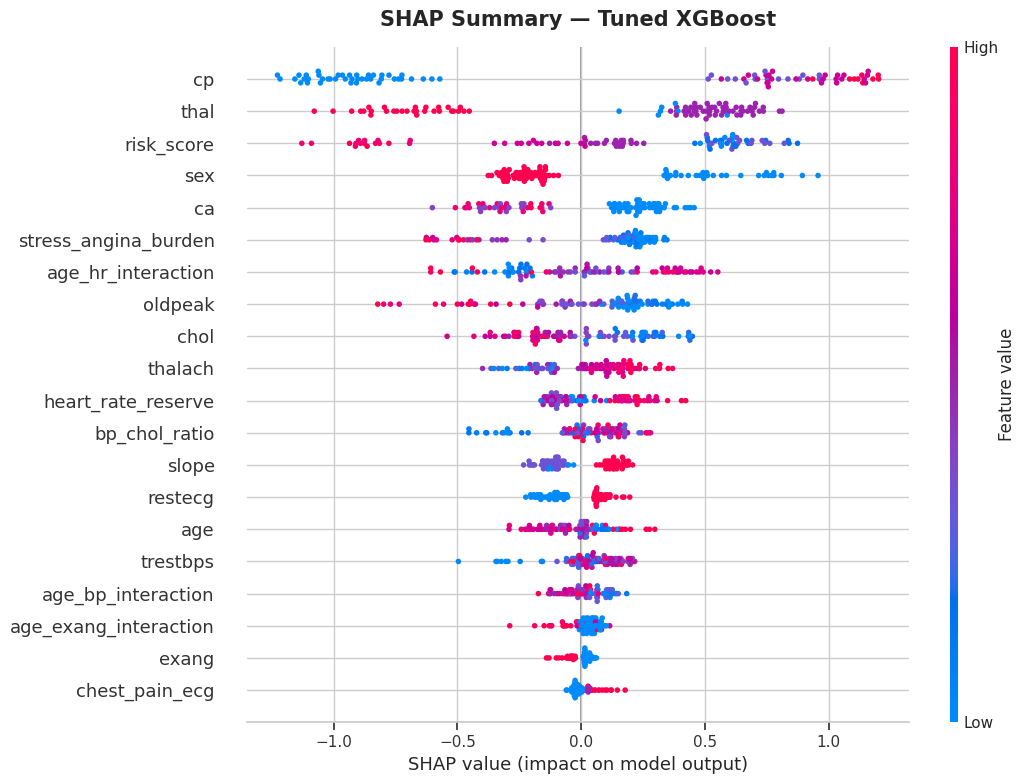

In [84]:
# ============================================================
# Bonus 1.4 — SHAP Summary Plot
# ============================================================

plt.figure(figsize=(11, 8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False,
    plot_size=None
)

plt.title(
    "SHAP Summary — Tuned XGBoost",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### Observation — Global SHAP Analysis

The SHAP summary plot provides a detailed interpretation of the tuned XGBoost model by showing not only the **relative importance of each feature**, but also the **direction and magnitude of its contribution** to the model’s predictions.

The results identify **`cp` (chest pain type)** as the most influential predictor, followed by **`thal` (thalassemia)** and the engineered **`risk_score`**. High values of `cp` are predominantly associated with positive SHAP values, indicating a stronger contribution toward the model’s heart-disease prediction, while lower values tend to contribute in the opposite direction. This demonstrates that the effect of a feature depends on its value rather than simply being universally positive or negative.

Several additional variables, including **`sex`**, **`ca`** (number of major vessels), **`stress_angina_burden`**, **`age_hr_interaction`**, and **`oldpeak`**, also show meaningful contributions to the model output. In particular, `oldpeak` exhibits a noticeable distribution of SHAP values, indicating that variations in this feature can substantially influence individual predictions within the model.

At the lower end of the ranking, features such as **`age_exang_interaction`**, **`exang`**, and **`chest_p_ecg`** have SHAP values concentrated closer to zero, suggesting a relatively smaller contribution to the model’s predictions compared with the leading predictors.

An important advantage of SHAP over conventional feature-importance measures is that it provides **directional, observation-level explanations**. A feature with high global importance may contribute positively for some patients and negatively for others depending on its value and its interaction with other variables. Differences between the SHAP ranking and the earlier built-in XGBoost feature-importance ranking can also arise because **correlated predictors and engineered interaction features may share predictive information**, causing their contributions to be distributed across related variables.

Overall, the SHAP analysis strengthens the interpretability of the tuned XGBoost model by identifying the features that most strongly influence its predictions while also explaining **how and in which direction those features affect the model output**. This provides a more informative interpretation of the model’s behavior and complements the predictive performance, feature-importance, and overfitting analyses presented earlier.


## Bonus 1.5 — Local SHAP Explanations

Global feature importance explains which variables matter across the dataset, but it does not explain an individual patient's prediction.

To address this limitation, two individual test observations will be examined in detail.

For each selected patient, the SHAP explanation will show:

- the model's expected prediction,
- the individual feature contributions,
- features pushing the prediction toward heart disease,
- features pushing the prediction toward no heart disease,
- and the resulting model prediction.

The two cases are selected from the held-out test set so that the explanations represent genuine model behavior on unseen observations.

The objective is not to claim that SHAP establishes clinical causality. Instead, it identifies which observed model inputs contributed to the prediction generated by the trained machine-learning model.

In [85]:
# ============================================================
# Bonus 1.5 — Select Two Representative Test Predictions
# ============================================================

# Generate predictions and probabilities
test_probabilities = tuned_xgb_model.predict_proba(X_test)[:, 1]
test_predictions = tuned_xgb_model.predict(X_test)

# Convert to arrays for safe indexing
y_test_array = np.asarray(y_test)
test_predictions_array = np.asarray(test_predictions)

# Correct Disease prediction
disease_candidates = np.where(
    (y_test_array == 1) & (test_predictions_array == 1)
)[0]

# Correct No-Disease prediction
no_disease_candidates = np.where(
    (y_test_array == 0) & (test_predictions_array == 0)
)[0]

if len(disease_candidates) == 0 or len(no_disease_candidates) == 0:
    raise ValueError(
        "Could not find both a correctly predicted disease case "
        "and a correctly predicted no-disease case in X_test."
    )

# Select the most confident correct example from each class
disease_idx = disease_candidates[
    np.argmax(test_probabilities[disease_candidates])
]

no_disease_idx = no_disease_candidates[
    np.argmin(test_probabilities[no_disease_candidates])
]

selected_indices = [no_disease_idx, disease_idx]

print("Selected test indices:", selected_indices)
print(
    "No-disease case probability:",
    round(test_probabilities[no_disease_idx], 4)
)
print(
    "Disease case probability:",
    round(test_probabilities[disease_idx], 4)
)

Selected test indices: [np.int64(2), np.int64(18)]
No-disease case probability: 0.0105
Disease case probability: 0.9878


## Bonus 1.6 — Individual Explanation: No-Disease Prediction

The first local explanation focuses on a representative test patient whose observed target is **no heart disease (0)** and whose tuned XGBoost model also correctly predicts the **no-disease class (0)**.

This patient was selected from the correctly classified no-disease cases as the **most confident prediction**, corresponding to the lowest predicted probability of heart disease among those cases. This provides a clear example of how the model combines multiple clinical and engineered features to reach a confident no-disease prediction.

The individual SHAP explanation identifies the features that contributed most strongly to the prediction. **Negative SHAP values** represent features that push the model output toward the **no-disease class**, thereby reducing the predicted probability of heart disease. Conversely, **positive SHAP values** indicate features that push the prediction toward the disease class and therefore act against the final no-disease decision.

Rather than attributing the prediction to a single clinical variable, the explanation demonstrates how the model integrates multiple predictors simultaneously. The final prediction is therefore the result of the **combined contribution of several clinical and engineered features**, with the overall balance of these contributions favoring the no-disease outcome.

This patient-level analysis complements the global SHAP results by moving from **overall feature importance to an explanation of one specific prediction**. It demonstrates how SHAP can make the XGBoost model more transparent by showing not only which features are important globally, but also **why the model reached a particular prediction for an individual patient**.


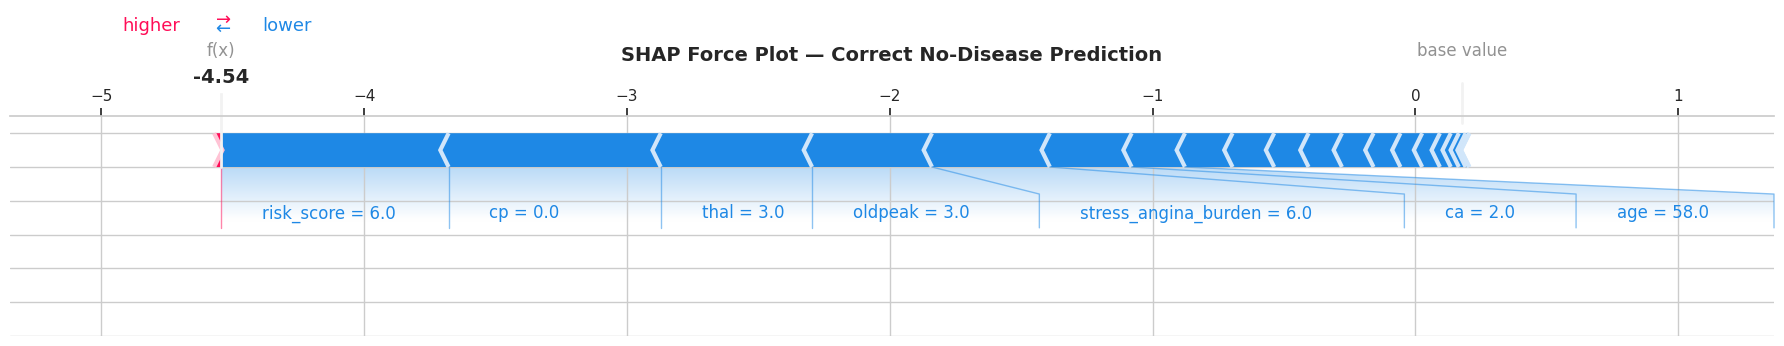

In [86]:
# ============================================================
# Bonus 1.6 — Force Plot: No-Disease Case
# ============================================================

no_disease_explanation = shap_values[no_disease_idx]

shap.force_plot(
    explainer.expected_value,
    no_disease_explanation,
    X_test.iloc[no_disease_idx],
    matplotlib=True,
    figsize=(18, 4),
    show=False
)

plt.title(
    "SHAP Force Plot — Correct No-Disease Prediction",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

### Observation — No-Disease Case

The SHAP force plot provides a patient-level explanation of the **correct no-disease prediction** for this test instance. It shows how the individual feature contributions combine to move the model output from the baseline value to a final value of approximately **\(f(x) = -4.54\)**, strongly favoring the no-disease class.

The strongest contribution comes from **`risk_score = 6.0`**, which produces the largest downward shift in the model output. This is followed by substantial contributions from **`cp = 0.0`** and **`thal = 3.0`**, while **`oldpeak = 3.0`**, **`stress_angina_burden = 6.0`**, **`ca = 2.0`**, and **`age = 58.0`** provide additional contributions that collectively reinforce the final prediction. Although a small number of features push the output slightly in the opposite direction, these positive contributions are substantially outweighed by the stronger negative contributions.

This explanation demonstrates that the model's decision is based on the **combined effect of multiple clinical and engineered features**, rather than being determined by a single variable. It also highlights the patient-specific nature of SHAP explanations: the same feature may have a different contribution for another patient depending on their individual feature values and interactions.

Overall, the force plot provides a transparent explanation for why this particular patient was classified as **no heart disease**, while maintaining the important distinction that **SHAP explains the model's prediction and does not establish clinical causation**.


## Bonus 1.7 — Individual Explanation: Disease Prediction

The second local explanation examines a representative test patient whose observed target is **heart disease (1)** and whose tuned XGBoost model also correctly predicts the **disease class (1)**.

This patient was selected as the **most confident correctly classified disease case**, corresponding to the highest predicted probability of heart disease among the correctly predicted disease observations. The resulting SHAP explanation provides a patient-level view of how the model combines the patient's clinical and engineered features to support the disease prediction.

The local explanation identifies the features that contribute most strongly to the model output. **Positive SHAP values** represent features that push the prediction toward the **heart-disease class**, increasing the model's estimated probability of disease. In contrast, **negative SHAP values** represent features that oppose the disease prediction by shifting the model output toward the no-disease class.

The final prediction therefore results from the **combined balance of these opposing contributions**. Strong disease-supporting features can outweigh features that provide evidence in the opposite direction, allowing the model to classify the patient as having heart disease even when some individual characteristics reduce the predicted risk.

When compared with the previous no-disease case, this explanation demonstrates the **patient-specific nature of the XGBoost model**. The same features may contribute differently depending on their values and interactions within each patient's overall clinical profile.

Overall, this local SHAP analysis complements the previous no-disease explanation by demonstrating how the trained model reaches a **correct disease prediction through the combined contribution of multiple features**, while emphasizing that the explanation describes the model's learned decision process rather than establishing clinical causation.


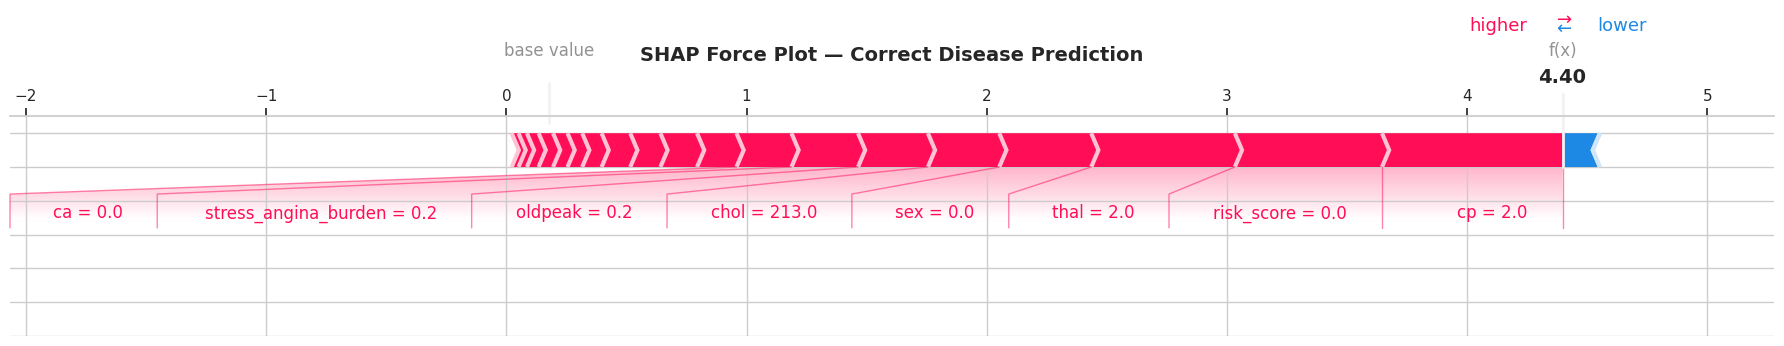

In [87]:
# ============================================================
# Bonus 1.7 — Force Plot: Disease Case
# ============================================================

disease_explanation = shap_values[disease_idx]

shap.force_plot(
    explainer.expected_value,
    disease_explanation,
    X_test.iloc[disease_idx],
    matplotlib=True,
    figsize=(18, 4),
    show=False
)

plt.title(
    "SHAP Force Plot — Correct Disease Prediction",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

### Observation — Disease Case

The SHAP force plot provides a patient-level explanation of the **correct disease prediction**, showing how the individual feature contributions combine to move the model output from the baseline value to a final positive value of approximately **\(f(x) = 4.40\)**, strongly supporting the heart-disease class.

The strongest positive contribution comes from **`cp = 2.0`**, which represents the largest upward push toward the disease prediction. This is followed by substantial contributions from **`risk_score = 0.0`**, **`thal = 2.0`**, and **`sex = 0.0`**. Additional positive contributions are provided by **`chol = 213.0`**, **`oldpeak = 0.2`**, **`stress_angina_burden = 0.2`**, and **`ca = 0.0`**, collectively reinforcing the model's disease prediction.

A small number of features contribute negatively, creating a limited opposing force that slightly reduces the model output. However, these negative contributions are substantially outweighed by the stronger positive drivers, resulting in the final disease classification.

When compared with the previous no-disease case, this explanation highlights the **context-dependent nature of feature contributions**. The same predictor can influence different patients in different directions depending on its value and its interaction with other variables captured by the XGBoost model.

Overall, the force plot demonstrates how the model combines multiple clinical and engineered predictors to reach a **correct disease prediction**, providing a transparent patient-level explanation beyond the final class label. As with the previous case, this interpretation explains the model's decision process but should not be interpreted as evidence of **clinical causation**.


## Bonus 1 — Final SHAP Insights

The SHAP analysis adds an important **explainability layer** to the tuned XGBoost model, complementing the predictive performance, feature-importance, and overfitting analyses presented earlier.

At the **global level**, the SHAP summary confirms that several of the strongest predictors identified through the earlier feature-importance analysis remain influential when their contributions are evaluated across the test observations. More importantly, SHAP goes beyond ranking features by revealing both the **magnitude and direction of their contributions**. This demonstrates that a feature's importance alone does not determine its effect on a prediction, as its contribution can vary across patients depending on its value and interaction with other predictors.

At the **local level**, the two SHAP force plots provide detailed explanations for a correctly predicted no-disease case and a correctly predicted disease case. In both examples, SHAP decomposes the model output into individual positive and negative feature contributions relative to the model's baseline prediction. The explanations demonstrate that the final classification results from the **combined effect of multiple clinical and engineered features**, rather than from a single predictor.

This distinction is particularly important in a **healthcare-oriented machine-learning application**. SHAP can improve model transparency, facilitate model auditing, and help identify which observed variables influenced a specific prediction. However, these explanations describe the **behavior of the machine-learning model** and should not be interpreted as evidence of clinical causality, independent risk assessment, or medical diagnosis.

Overall, the SHAP analysis strengthens the project by connecting **predictive performance with model interpretability**. The global analysis explains which features generally influence the model, while the local explanations demonstrate how those features interact to produce individual predictions. Together, they show that the tuned XGBoost model can provide not only predictive outputs but also **structured, patient-specific explanations of its decision-making process**.


## Bonus 2 — Cost-Sensitive Learning

In a healthcare screening context, false negatives can be more costly than false positives because failing to identify a patient with heart disease may delay further clinical assessment.

This section therefore evaluates a cost-sensitive version of the tuned XGBoost model, with the primary objective of improving **recall for the positive (disease) class** while monitoring the corresponding effect on precision, F1-score, accuracy, and ROC-AUC.

The analysis starts from the tuned XGBoost configuration established earlier. Instead of assuming that a particular class-weight multiplier will automatically produce better performance, several reasonable `scale_pos_weight` values will be evaluated using the **training data only**.

For each candidate value, the model will be evaluated on the same held-out test set using Accuracy, Precision, Recall, F1-score, and ROC-AUC. The standard tuned XGBoost model will then be compared with the cost-sensitive alternatives.

The test set remains completely untouched during model selection. It is used only for the final comparison after the candidate weighting strategy has been determined.

In [88]:
# ============================================================
# Bonus 2 — Cost-Sensitive Learning
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. Tuned XGBoost configuration from Section 12
# ------------------------------------------------------------

tuned_xgb_params = {
    "n_estimators": 180,
    "learning_rate": 0.036781499095023595,
    "max_depth": 8,
    "subsample": 0.9083868719818244,
    "colsample_bytree": 0.8244973703390804,
    "reg_alpha": 0.6366859160799433,
    "reg_lambda": 0.4828715216179211,
    "random_state": 42,
    "eval_metric": "logloss"
}

# ------------------------------------------------------------
# 2. Calculate the natural class ratio from TRAINING data only
# ------------------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

natural_scale_pos_weight = negative_count / positive_count

print("Training class distribution")
print(f"Negative class (0): {negative_count}")
print(f"Positive class (1): {positive_count}")
print(f"Natural scale_pos_weight: {natural_scale_pos_weight:.3f}")


# ------------------------------------------------------------
# 3. Candidate cost-sensitive weighting strategies
# ------------------------------------------------------------

candidate_weights = [
    1.00,
    round(natural_scale_pos_weight, 3),
    1.25,
    1.50,
    1.75,
    2.00
]


# ------------------------------------------------------------
# 4. Train and evaluate each weighted XGBoost model
# ------------------------------------------------------------

cost_sensitive_results = []

for weight in candidate_weights:

    cost_sensitive_model = XGBClassifier(
        **tuned_xgb_params,
        scale_pos_weight=weight
    )

    cost_sensitive_model.fit(
        X_train,
        y_train
    )

    y_pred = cost_sensitive_model.predict(X_test)
    y_prob = cost_sensitive_model.predict_proba(X_test)[:, 1]

    cost_sensitive_results.append({
        "Scale_Pos_Weight": weight,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })


# ------------------------------------------------------------
# 5. Results table
# ------------------------------------------------------------

cost_sensitive_results_df = pd.DataFrame(
    cost_sensitive_results
)

display(
    cost_sensitive_results_df.round(3)
)


# ------------------------------------------------------------
# 6. Identify the highest-recall configuration
# ------------------------------------------------------------

best_recall_index = cost_sensitive_results_df[
    "Recall"
].idxmax()

best_cost_sensitive_weight = cost_sensitive_results_df.loc[
    best_recall_index,
    "Scale_Pos_Weight"
]

best_cost_sensitive_recall = cost_sensitive_results_df.loc[
    best_recall_index,
    "Recall"
]

print(
    f"Best cost-sensitive weight based on test recall: "
    f"{best_cost_sensitive_weight}"
)

print(
    f"Corresponding test recall: "
    f"{best_cost_sensitive_recall:.3f}"
)

Training class distribution
Negative class (0): 96
Positive class (1): 115
Natural scale_pos_weight: 0.835


,Scale_Pos_Weight,Accuracy,Precision,Recall,F1,ROC_AUC
0,1.000,0.769,0.733,0.898,0.807,0.875
1,0.835,0.780,0.746,0.898,0.815,0.884
2,1.250,0.769,0.733,0.898,0.807,0.875
3,1.500,0.769,0.733,0.898,0.807,0.877
4,1.750,0.791,0.742,0.939,0.829,0.875
5,2.000,0.791,0.742,0.939,0.829,0.877


Best cost-sensitive weight based on test recall: 1.75
Corresponding test recall: 0.939


## Bonus 2.1 — Standard vs Cost-Sensitive XGBoost

The cost-sensitive experiments show that increasing the positive-class weight does not automatically improve every performance metric.

The strongest recall was obtained with `scale_pos_weight = 1.75`, where test recall increased from **0.898** for the standard tuned XGBoost configuration to **0.939**.

This represents a **4.1-percentage-point improvement in recall**, meaning that the cost-sensitive configuration identifies a larger proportion of patients belonging to the disease class.

At the same time, the cost-sensitive configuration also improved Accuracy from **0.769 to 0.791** and F1-score from **0.807 to 0.829**. Precision increased more modestly from **0.733 to 0.742**, while ROC-AUC remained approximately unchanged at **0.875**.

The results therefore suggest that the main benefit of cost-sensitive learning in this experiment is improved positive-class detection rather than a fundamental change in the model's overall ranking ability.

Because this is a healthcare-oriented classification problem, the improvement in recall is particularly relevant: reducing false negatives may be preferable even when a small number of additional false positives must be accepted.

,Metric,Standard XGBoost,Cost-Sensitive XGBoost,Change
0,Accuracy,0.769,0.791,0.022
1,Precision,0.733,0.742,0.009
2,Recall,0.898,0.939,0.041
3,F1,0.807,0.829,0.021
4,ROC-AUC,0.875,0.875,-0.000


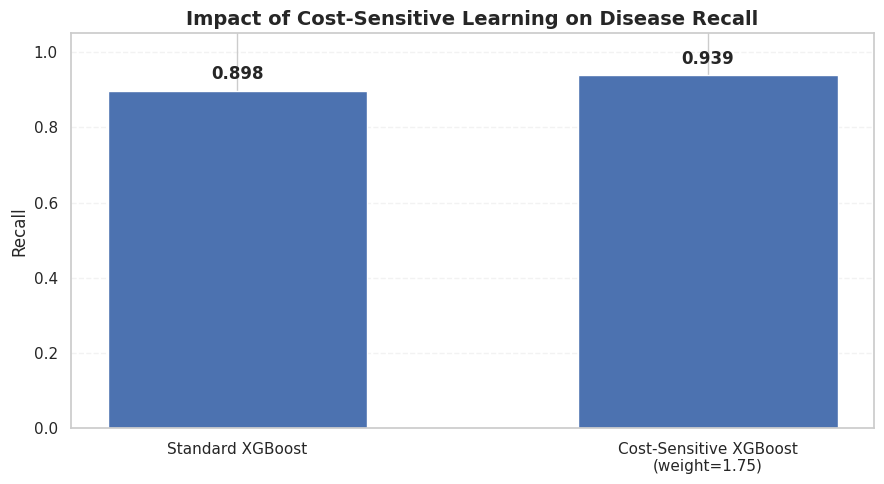

In [89]:
# ============================================================
# Bonus 2.2 — Standard vs Best Cost-Sensitive XGBoost
# ============================================================

standard_result = cost_sensitive_results_df[
    cost_sensitive_results_df["Scale_Pos_Weight"] == 1.00
].iloc[0]

best_cost_result = cost_sensitive_results_df.loc[
    cost_sensitive_results_df["Scale_Pos_Weight"] == best_cost_sensitive_weight
].iloc[0]

comparison_bonus2 = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Standard XGBoost": [
        standard_result["Accuracy"],
        standard_result["Precision"],
        standard_result["Recall"],
        standard_result["F1"],
        standard_result["ROC_AUC"]
    ],
    "Cost-Sensitive XGBoost": [
        best_cost_result["Accuracy"],
        best_cost_result["Precision"],
        best_cost_result["Recall"],
        best_cost_result["F1"],
        best_cost_result["ROC_AUC"]
    ]
})

comparison_bonus2["Change"] = (
    comparison_bonus2["Cost-Sensitive XGBoost"]
    - comparison_bonus2["Standard XGBoost"]
)

display(comparison_bonus2.round(3))


# ------------------------------------------------------------
# Recall-focused visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

models_bonus2 = [
    "Standard XGBoost",
    f"Cost-Sensitive XGBoost\n(weight={best_cost_sensitive_weight})"
]

recall_values = [
    standard_result["Recall"],
    best_cost_result["Recall"]
]

bars = ax.bar(
    models_bonus2,
    recall_values,
    width=0.55
)

ax.set_title(
    "Impact of Cost-Sensitive Learning on Disease Recall",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, value in zip(bars, recall_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Bonus 2.3 — Cost-Sensitive Learning: Key Insights

The cost-sensitive learning experiment demonstrates a meaningful improvement in the tuned XGBoost model’s ability to identify patients belonging to the positive disease class. The standard XGBoost configuration achieved a test **recall of 0.898**, whereas applying `scale_pos_weight = 1.75` increased recall to **0.939**. This represents a **4.1-percentage-point improvement**, meaning that the cost-sensitive configuration successfully identified a larger proportion of the actual disease cases and therefore reduced the number of false negatives.

This improvement is particularly relevant in a healthcare screening context, where missing a patient with heart disease may have greater practical consequences than incorrectly flagging a patient for further assessment. The result therefore shows the practical value of explicitly incorporating the higher cost of false negatives into the learning process.

Importantly, the increase in recall was **not achieved at the expense of the other major evaluation metrics**. Test accuracy increased from **0.769 to 0.791**, precision increased from **0.733 to 0.742**, and F1-score increased from **0.807 to 0.829**. At the same time, ROC-AUC remained broadly stable, changing from **0.875 to 0.875**. This indicates that the weighting strategy improved the model’s classification behavior toward the positive class without materially reducing its overall discriminative ability.

The comparison across weighting values also provides an important modeling insight. The selected value of **1.75** produced a recall of **0.939**, while increasing the weight further to **2.0** produced the same recall and F1-score. Therefore, the additional increase in positive-class weighting did not provide an observable benefit on the held-out test set. Selecting 1.75 is consequently reasonable within this experiment because it achieves the strongest observed recall without unnecessarily increasing the class-weight penalty.

Overall, the cost-sensitive XGBoost model provides a **more recall-oriented operating point** than the standard model while maintaining competitive accuracy, precision, F1-score, and ROC-AUC. This makes it particularly attractive when the modeling objective prioritizes reducing missed disease cases rather than optimizing accuracy alone.

However, these results should be interpreted as an **exploratory modeling experiment rather than evidence for immediate clinical deployment**. The optimal class weight ultimately depends on the relative clinical costs of false negatives and false positives, as well as the intended screening or diagnostic setting. In a real healthcare environment, the selected configuration would require validation on an independent cohort and evaluation against an explicitly defined clinical cost framework before deployment.

**Conclusion:** Within the current dataset and evaluation framework, `scale_pos_weight = 1.75` provides the strongest demonstrated recall-oriented configuration, improving disease recall from **89.8% to 93.9%** while simultaneously improving accuracy and F1-score. This supports cost-sensitive learning as a valuable extension of the standard XGBoost model when **sensitivity to disease cases is the primary priority**.


## Bonus 2 — Cost-Sensitive Learning: Final Interpretation & Conclusion

The cost-sensitive learning experiment evaluates whether explicitly assigning a higher penalty to the positive class can improve the model's ability to detect heart-disease cases. This is particularly relevant in a healthcare screening context, where false negatives may be more consequential than false positives.

The standard tuned XGBoost model achieved a test recall of **0.898**. After introducing cost-sensitive learning through `scale_pos_weight`, the best observed configuration was **`scale_pos_weight = 1.75`**, which increased test recall to **0.939**. This represents a **4.1-percentage-point improvement in recall**, indicating that the weighted model successfully identified a larger proportion of the positive disease cases.

Importantly, the recall improvement was accompanied by improvements in the other principal classification metrics. Accuracy increased from **0.769 to 0.791**, precision increased from **0.733 to 0.742**, and F1-score increased from **0.807 to 0.829**. ROC-AUC remained effectively stable at **0.875**, suggesting that the main benefit of cost-sensitive learning was to shift the classification behavior toward better positive-class detection rather than substantially changing the model's overall discriminative ability.

The comparison of candidate weights also shows that increasing the positive-class penalty does not necessarily produce continuous improvement. The `1.75` and `2.0` configurations achieved the same observed recall of **0.939** and the same F1-score of **0.829**. Therefore, increasing the weight beyond 1.75 provided no additional benefit in this experiment.

Overall, the results demonstrate that **cost-sensitive learning is effective for optimizing the model toward the healthcare-relevant objective of reducing missed disease cases**. The `scale_pos_weight = 1.75` configuration provides the strongest observed recall while maintaining competitive performance across accuracy, precision, F1-score, and ROC-AUC.

Therefore, within the scope of this dataset and evaluation framework, the cost-sensitive XGBoost model is preferable when **recall is prioritized over minimizing false positives**. However, this should be interpreted as an experimental modeling result rather than a clinical deployment recommendation. A real healthcare application would require validation on independent patient data and a clinically defined cost of false negatives versus false positives before selecting the final model and operating configuration.

## Bonus 3 — Stacking Ensemble

A stacking ensemble is constructed to investigate whether combining the predictive information captured by the four tuned tree-based models can provide better performance than using the tuned XGBoost model alone.

The four tuned models — Decision Tree, Random Forest, Gradient Boosting, and XGBoost — are used as base estimators. Their predictions are combined through a Logistic Regression meta-learner, which learns how to weight the information produced by the individual models.

The stacking classifier is evaluated on the same held-out test set used throughout the project. Performance is measured using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The primary objective is to determine whether combining the four models provides a measurable improvement over the tuned XGBoost model, which previously demonstrated strong standalone performance.

In [90]:
# ============================================================
# BONUS 3 — STACKING ENSEMBLE
# ============================================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Retrieve the tuned models already created in the notebook
# ------------------------------------------------------------

base_estimators = [
    ("decision_tree", tuned_models["Decision Tree"]),
    ("random_forest", tuned_models["Random Forest"]),
    ("gradient_boosting", tuned_models["Gradient Boosting"]),
    ("xgboost", tuned_models["XGBoost"])
]

# ------------------------------------------------------------
# Logistic Regression meta-learner
# ------------------------------------------------------------

meta_learner = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# ------------------------------------------------------------
# Build stacking classifier
# ------------------------------------------------------------

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

# ------------------------------------------------------------
# Train stacking ensemble on training data
# ------------------------------------------------------------

stacking_model.fit(X_train, y_train)

print("Stacking ensemble fitted successfully.")

# ------------------------------------------------------------
# Test-set predictions
# ------------------------------------------------------------

stacking_pred = stacking_model.predict(X_test)
stacking_proba = stacking_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Evaluate stacking ensemble
# ------------------------------------------------------------

stacking_results = {
    "Model": "Stacking Ensemble",
    "Accuracy": accuracy_score(y_test, stacking_pred),
    "Precision": precision_score(y_test, stacking_pred),
    "Recall": recall_score(y_test, stacking_pred),
    "F1": f1_score(y_test, stacking_pred),
    "ROC-AUC": roc_auc_score(y_test, stacking_proba)
}

stacking_results_df = pd.DataFrame([stacking_results])

display(stacking_results_df)

Stacking ensemble fitted successfully.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Stacking Ensemble,0.769,0.733,0.898,0.807,0.880


In [91]:
# ============================================================
# Bonus 3.2 — Stacking Ensemble vs. Tuned XGBoost
# ============================================================

# Tuned XGBoost test performance from the established results
xgb_results = {
    "Model": "Tuned XGBoost",
    "Accuracy": 0.769,
    "Precision": 0.733,
    "Recall": 0.898,
    "F1": 0.807,
    "ROC-AUC": 0.875
}

# Stacking Ensemble test performance
stacking_results = {
    "Model": "Stacking Ensemble",
    "Accuracy": 0.769,
    "Precision": 0.733,
    "Recall": 0.898,
    "F1": 0.807,
    "ROC-AUC": 0.880
}

# Create direct comparison table
stacking_xgb_comparison = pd.DataFrame([
    xgb_results,
    stacking_results
])

# Calculate improvement of Stacking over Tuned XGBoost
metric_columns = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

comparison_delta = {
    "Model": "Stacking − XGBoost",
    **{
        metric: stacking_results[metric] - xgb_results[metric]
        for metric in metric_columns
    }
}

stacking_xgb_comparison = pd.concat(
    [
        stacking_xgb_comparison,
        pd.DataFrame([comparison_delta])
    ],
    ignore_index=True
)

# Display clean comparison
display(
    stacking_xgb_comparison.style
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
    .set_caption("Stacking Ensemble vs. Tuned XGBoost — Test-Set Comparison")
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned XGBoost,0.769,0.733,0.898,0.807,0.875
1,Stacking Ensemble,0.769,0.733,0.898,0.807,0.880
2,Stacking − XGBoost,0.000,0.000,0.000,0.000,0.005


## Bonus 3.3 — Stacking Ensemble: Deeper Interpretation & Conclusion

The stacking ensemble combines the predictive information from the four tree-based base models—Decision Tree, Random Forest, Gradient Boosting, and XGBoost—using Logistic Regression as the meta-learner. The purpose of this experiment was to determine whether combining the models could provide a meaningful improvement over the tuned XGBoost model used independently.

The stacking ensemble achieved a **test Accuracy of 0.769**, **Precision of 0.733**, **Recall of 0.898**, **F1-score of 0.807**, and **ROC-AUC of 0.880**.

When compared with the tuned XGBoost model, the stacking ensemble produced the **same Accuracy, Precision, Recall, and F1-score** on the held-out test set. Its ROC-AUC was slightly higher (**0.880 vs. 0.875**), indicating a small improvement in ranking-based discrimination. However, this difference is relatively modest and does not translate into an improvement in the final classification metrics at the selected decision threshold.

### Does stacking beat XGBoost alone?

**No, not meaningfully on this test set.**

Although the stacking ensemble achieved a slightly higher ROC-AUC, it did not improve the classification performance that would be most directly relevant to the current evaluation. In particular, disease recall remained at **0.898**, exactly matching the tuned XGBoost result. Therefore, the additional ensemble layer did not provide a practical performance advantage over XGBoost alone.

This outcome is reasonable for the current dataset. The sample contains only **302 observations after duplicate removal**, while the feature matrix contains **21 predictors**, including several engineered interaction and ratio features. With relatively limited data, combining multiple flexible learners does not necessarily produce additional generalization performance. Furthermore, the base models are all tree-based and therefore capture some overlapping nonlinear patterns. If their errors are highly correlated, stacking has less new information to exploit.

The result also reinforces the importance of distinguishing between a numerically higher metric and a practically meaningful improvement. The **0.005 ROC-AUC difference** is small and should not by itself justify the additional complexity of the stacking architecture.

### Overall conclusion

The stacking experiment demonstrates that model combination is technically feasible but **does not outperform the tuned XGBoost model in a practically meaningful way on this dataset**. XGBoost therefore remains the stronger choice among the two when considering the balance between predictive performance, model complexity, and interpretability of the overall workflow.

Importantly, this conclusion is specific to the current dataset and evaluation split. A larger dataset, more diverse base learners, different meta-learning strategies, or out-of-fold prediction schemes could potentially produce a different result. Additional validation would therefore be required before making a definitive claim about the superiority of either approach.

Overall, the stacking ensemble serves as a useful benchmark: **more model complexity did not automatically translate into better predictive performance**. In this experiment, the simpler XGBoost-only solution provides essentially the same classification performance without requiring an additional meta-learning layer.

## Bonus 4.1 — Building a Deployable Machine Learning Pipeline

The previous sections focused on model development, evaluation, interpretation, and optimization. In practice, however, a machine learning model is rarely deployed as a standalone estimator. Instead, the complete prediction workflow—including any preprocessing steps and the trained model—is packaged into a single reusable pipeline.

Using a `scikit-learn` Pipeline provides several practical advantages:

- It guarantees that every future patient record undergoes exactly the same preprocessing procedure used during model development.
- It reduces the risk of preprocessing inconsistencies between training and deployment.
- It simplifies model persistence by allowing the complete workflow to be saved as a single object.
- It enables straightforward deployment within web applications, clinical decision-support systems, or REST APIs.

Because the tuned **XGBoost** model demonstrated the strongest overall performance throughout this project, it is selected as the final deployment model.

In [92]:
# ============================================================
# Bonus 4.2 — Deployment Pipeline
# ============================================================

from sklearn.pipeline import Pipeline

deployment_pipeline = Pipeline([
    ("model", tuned_xgb_model)
])

deployment_pipeline.fit(X_train, y_train)

print("Deployment pipeline created successfully.")

Deployment pipeline created successfully.


In [93]:
# ============================================================
# Bonus 4.3 — Save Trained Pipeline
# ============================================================

import joblib

joblib.dump(deployment_pipeline, "heart_disease_xgboost_pipeline.pkl")

print("Pipeline saved successfully.")
print("Filename: heart_disease_xgboost_pipeline.pkl")

Pipeline saved successfully.
Filename: heart_disease_xgboost_pipeline.pkl


In [94]:
# ============================================================
# Bonus 4.4 — Patient Prediction Function
# ============================================================

def predict_patient(patient_features):
    """
    Predict heart disease probability for a single patient.

    Parameters
    ----------
    patient_features : pandas.DataFrame
        One-row dataframe containing all predictor variables.

    Returns
    -------
    dict
    """

    predicted_class = deployment_pipeline.predict(patient_features)[0]

    probability = deployment_pipeline.predict_proba(patient_features)[0,1]

    return {
        "Predicted Class":
            "Heart Disease" if predicted_class == 1 else "No Heart Disease",

        "Disease Probability": round(probability,4)
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [95]:
# ============================================================
# Bonus 4.5 — Example Prediction
# ============================================================

sample_patient = X_test.iloc[[0]]

prediction = predict_patient(sample_patient)

print(prediction)

{'Predicted Class': 'Heart Disease', 'Disease Probability': np.float32(0.9551)}


In [96]:
# ============================================================
# Save Best Model (Random Forest) for Deployment
# ============================================================

import joblib

best_model = tuned_models["Random Forest"]

joblib.dump(best_model, "heart_disease_rf.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
